In [ ]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

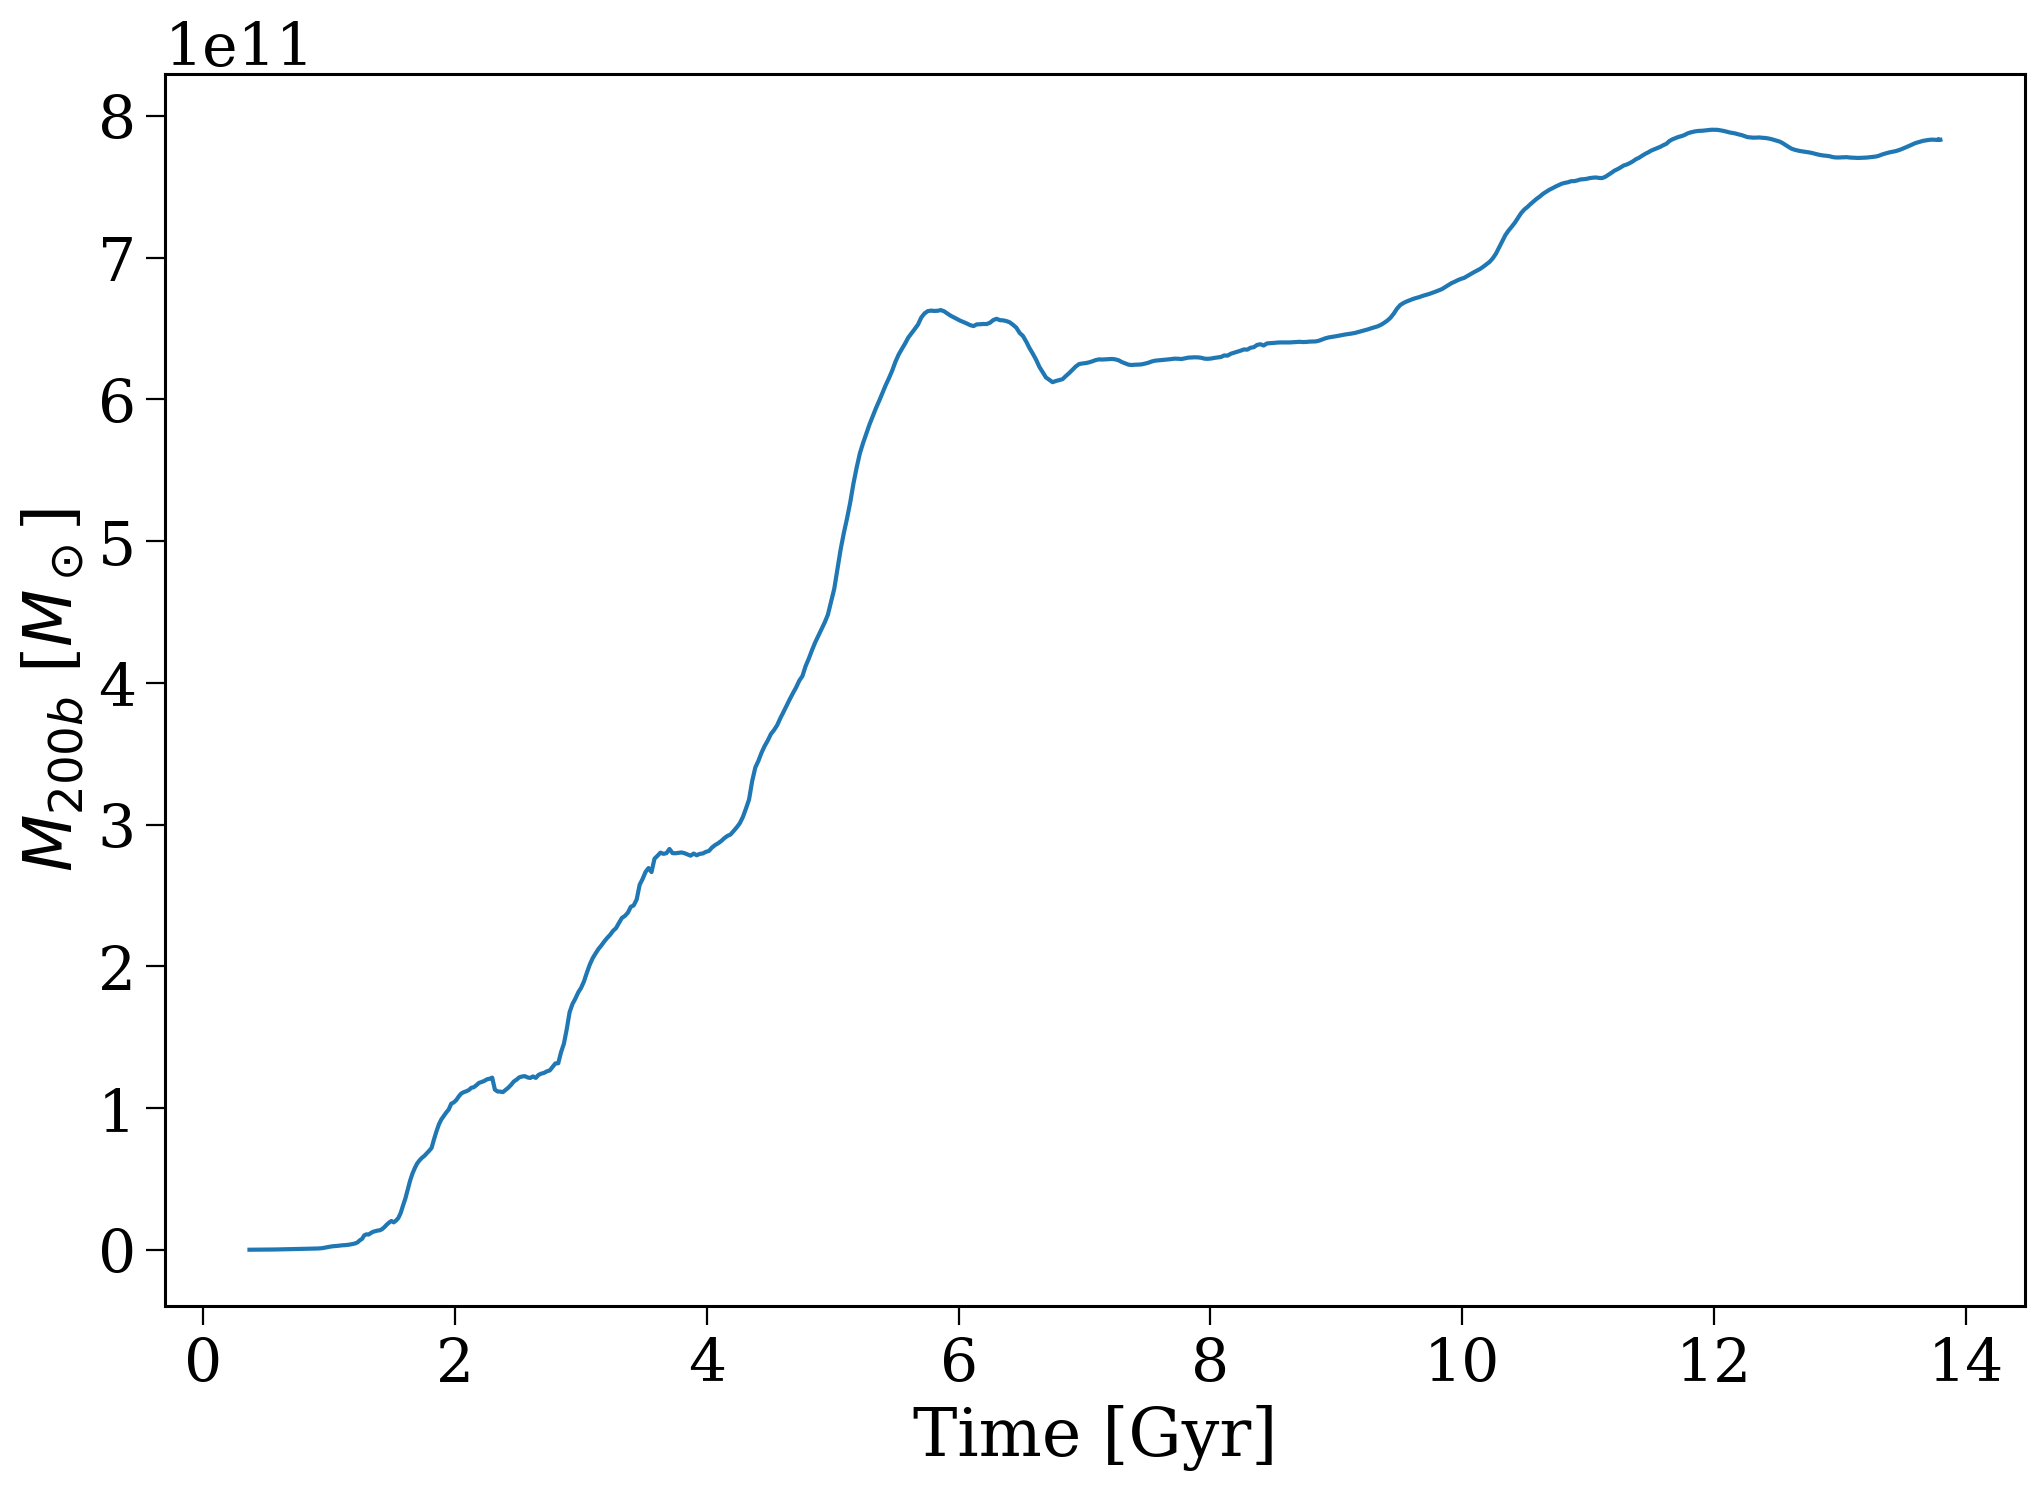

In [24]:
growth = pd.read_csv("../simulations/main_halo_growth.csv")

fig, ax = plt.subplots()

ax.plot(growth["age_Gyr"], growth["M200c"] / 0.702)

ax.set(
    xlabel="Time [Gyr]",
    ylabel=r"$M_{200b}$ [$M_\odot$]",
    # yscale="log",
)


plt.show()

In [2]:
pops = [
    cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/qcflag-5_part{i}")
    for i in range(34)
]
for pop in pops:
    pop.initial_binaries
    pop.initial_galaxy
    pop.initC
    pop.final_bpp
    pop.bin_nums
    pop.final_pos
    pop.final_vel
    pop._file = None

pop = cogsworth.pop.concat(*pops)
# del pops

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(
/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(


/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(

/mnt/home/twagg/miniforge3/envs/cogswort

In [3]:
pop.bpp["row_num"] = np.arange(len(pop.bpp))
pop.colour = "tab:blue"
pop.label = "Fiducial"

# Rates

In [4]:
scale_up = 6e10 / pop.mass_binaries
scale_up

np.float64(97.18424978557164)

In [5]:
n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
print(f"Rates (unscaled)\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
print(f"Rates (scaled)\n  Total: {(n_ns + n_bh) * scale_up:.1e}, NSs: {n_ns * scale_up:.1e}, BHs: {n_bh * scale_up:.1e}")

Rates (unscaled)
  Total: 6773627, NSs: 4887606, BHs: 1886021
Rates (scaled)
  Total: 6.6e+08, NSs: 4.7e+08, BHs: 1.8e+08


Olejak+20 predicted 1.2e8 BHs, close!

# Spatial distributions

In [6]:
kinematics = helpers.get_kinematics([pop])
stars = cogsworth.sfh.SandersBinney2015(
    size=n_bh + n_ns,
    **{
        "potential": pop.galactic_potential,
        "time_bins": 5,
        "verbose": True
    }
)

Pre-computing lookback time, guiding radius and frequency interpolations
Initiating sampling procedure
  Sampling 5484029 stars from the thin_disc
    Sampling 657314 stars with lookback times between 0.00 Gyr and 2.00 Gyr
    Sampling 837525 stars with lookback times between 2.00 Gyr and 4.00 Gyr
    Sampling 1061142 stars with lookback times between 4.00 Gyr and 6.00 Gyr
    Sampling 1327312 stars with lookback times between 6.00 Gyr and 8.00 Gyr
    Sampling 1600736 stars with lookback times between 8.00 Gyr and 10.00 Gyr
  Sampling 1289598 stars from the thick_disc
    Sampling 1289598 stars with lookback times between 10.00 Gyr and 12.00 Gyr


[ 28.27785823 206.17308603]
[ 6024.66112227 10619.11890407]


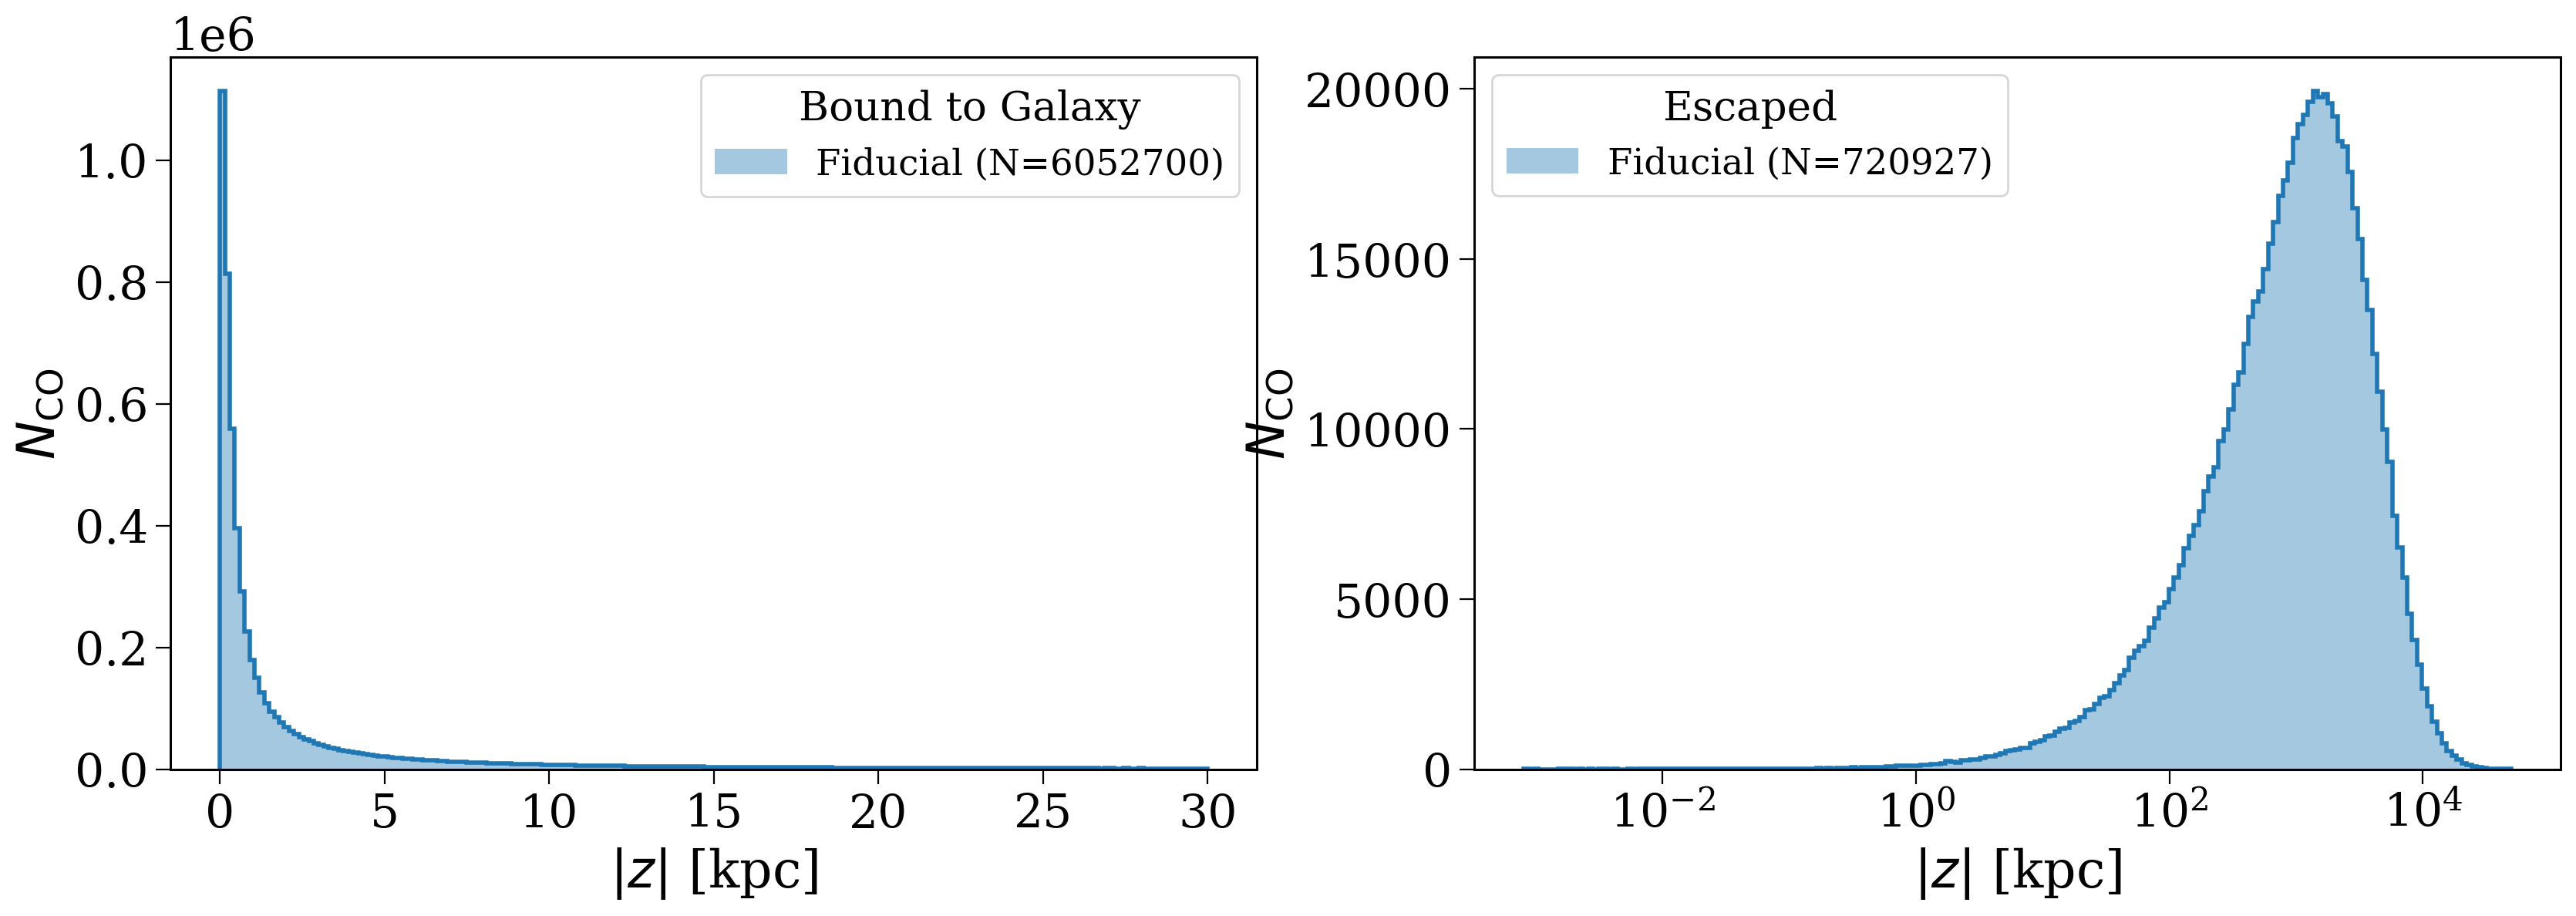

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 30, 201), np.geomspace(8e-4, 5e4, 200)]
labels = ['Bound to Galaxy', "Escaped"]

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    co_pos = kinematics[pop.label]["pos"]["CO"]
    co_vel = kinematics[pop.label]["vel"]["CO"]

    co_V = np.linalg.norm(co_vel.to(u.km/u.s).value, axis=1)

    mask = co_V >= np.sqrt(-2 * pop.galactic_potential(co_pos.T)).to(u.km / u.s).value
    mask = mask if label == "Escaped" else ~mask

    print(np.percentile(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], [95, 99]))

    ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, histtype='step', lw=2, color=pop.colour)
    ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, alpha=0.4, color=pop.colour,
            label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

0.5084231665248815
0.31332619806642137


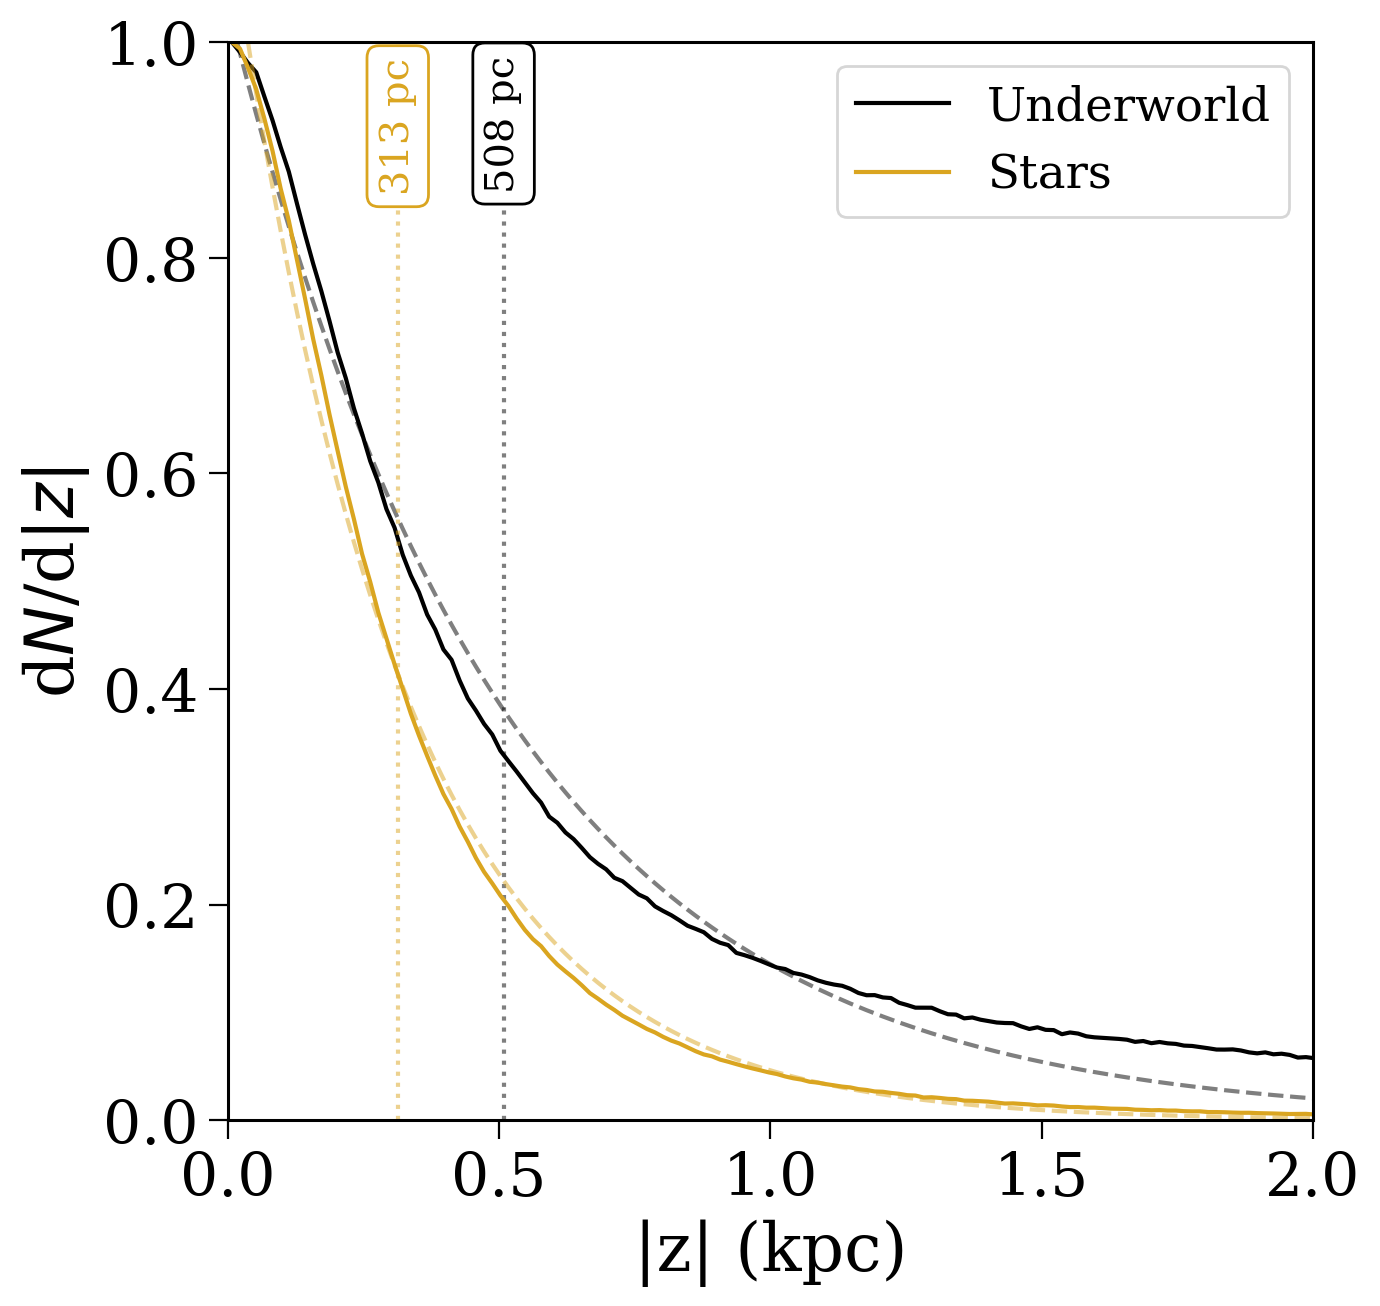

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], stars.z],
    ["Underworld", "Stars"],
    ["black", "goldenrod"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(0, 2),
        ylim=(0, 1)
    )

# plt.savefig("../plots/scale_height_underworld_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

0.5563969408605585
0.3673029055312761


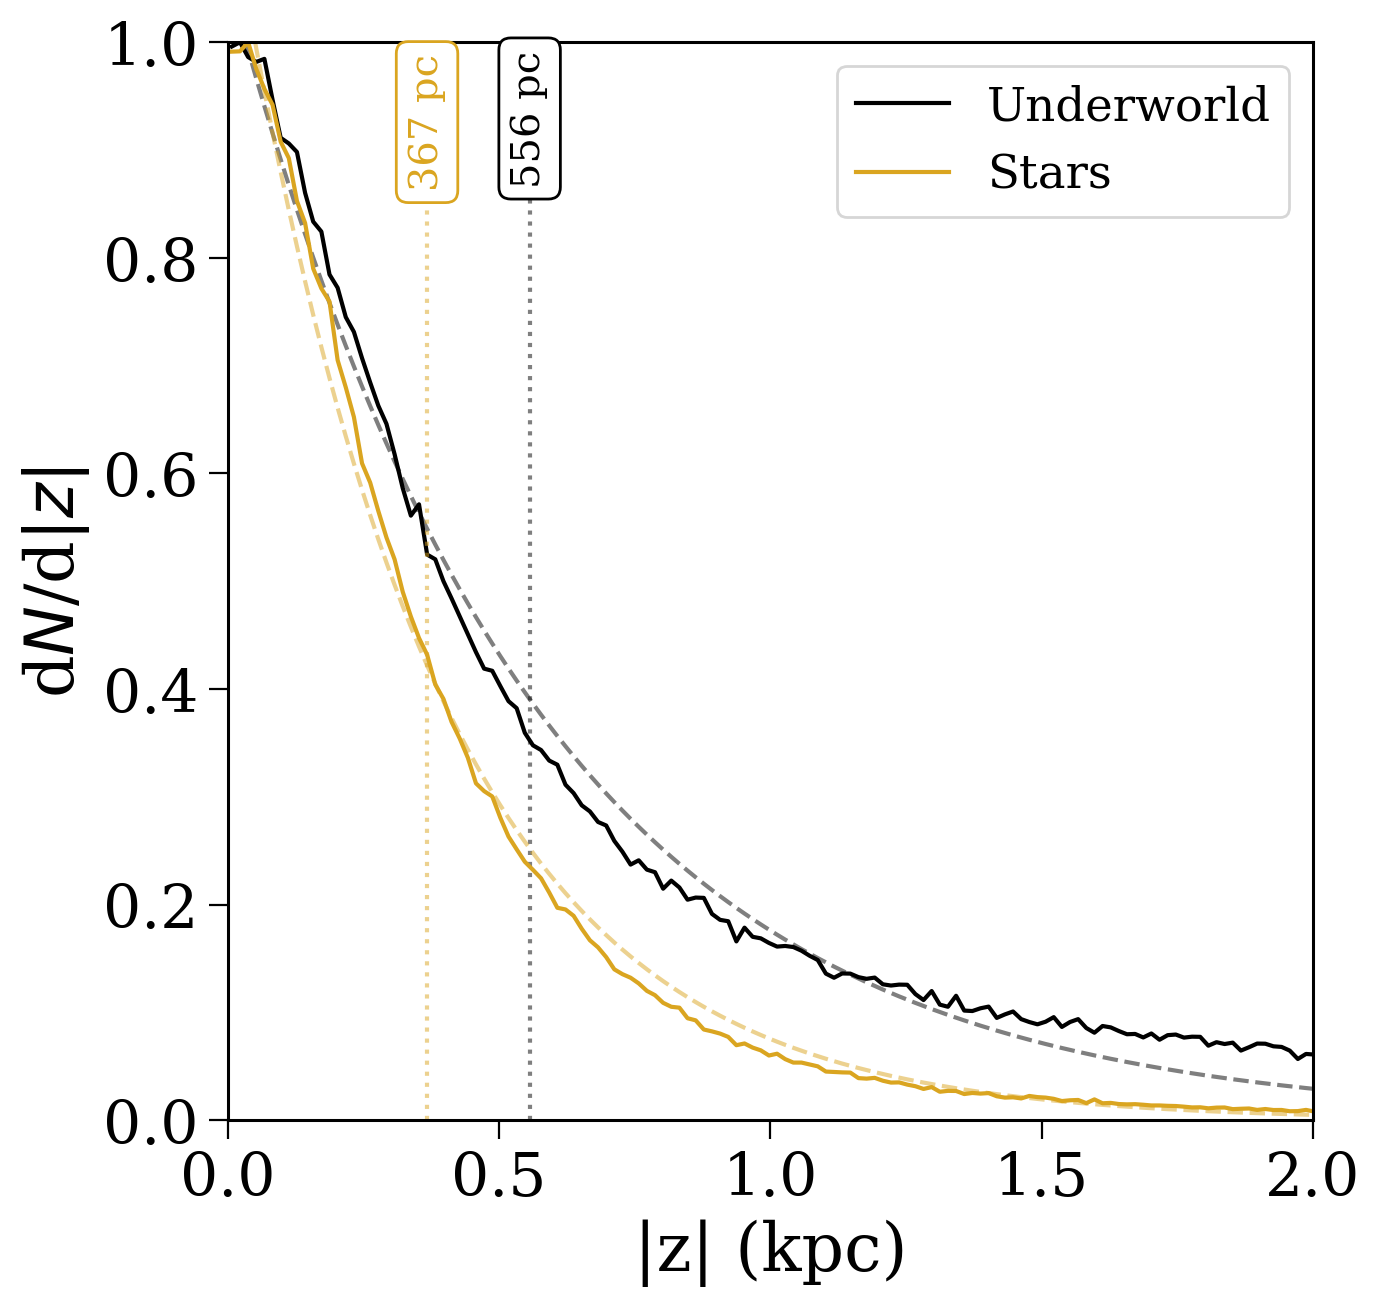

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

r_co = np.linalg.norm(kinematics["Fiducial"]["pos"]["CO"][:, :2], axis=1)
solar_neighbourhood_co = (r_co >= 7.5*u.kpc) & (r_co <= 8.5*u.kpc)

solar_neighbourhood_stars = (stars.rho >= 7.5*u.kpc) & (stars.rho <= 8.5*u.kpc)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2][solar_neighbourhood_co], stars.z[solar_neighbourhood_stars]],
    ["Underworld", "Stars"],
    ["black", "goldenrod"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(0, 2),
        ylim=(0, 1)
    )

# plt.savefig("../plots/scale_height_underworld_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [16]:
reload(plotting)

def bootstrap_scale_height(z, n_samples=1000, **kwargs):
    scale_height_estimates = []
    n_components = kwargs.pop('n_components', 2)

    for _ in range(n_samples):
        sample_z = np.random.choice(z, size=len(z), replace=True)
        scale_height = plotting.estimate_scale_height(
            z=sample_z,
            plot=False,
            n_components=n_components,
            **kwargs
        )[0][0]
        scale_height_estimates.append(scale_height)
    return scale_height_estimates

In [17]:
co_scale_heights = bootstrap_scale_height(kinematics["Fiducial"]["pos"]["CO"][:, 2])
bh_scale_heights = bootstrap_scale_height(kinematics["Fiducial"]["pos"]["BH"][:, 2])
ns_scale_heights = bootstrap_scale_height(kinematics["Fiducial"]["pos"]["NS"][:, 2])
stars_scale_heights = bootstrap_scale_height(stars.z, n_components=1)

KeyboardInterrupt: 

In [ ]:
n_bh + n_ns

np.int64(6812925)

In [ ]:
for sc in [stars_scale_heights, co_scale_heights, bh_scale_heights, ns_scale_heights]:
    sc = np.array(sc) * 1000
    print(f"Scale height estimate: {np.median(sc):.0f} +/- {np.std(sc):.0f} pc")

Scale height estimate: 314 +/- 1 pc
Scale height estimate: 1142 +/- 23 pc
Scale height estimate: 945 +/- 35 pc
Scale height estimate: 1260 +/- 29 pc


1.0859652694520014
0.3268356592947922
0.31332619806642137


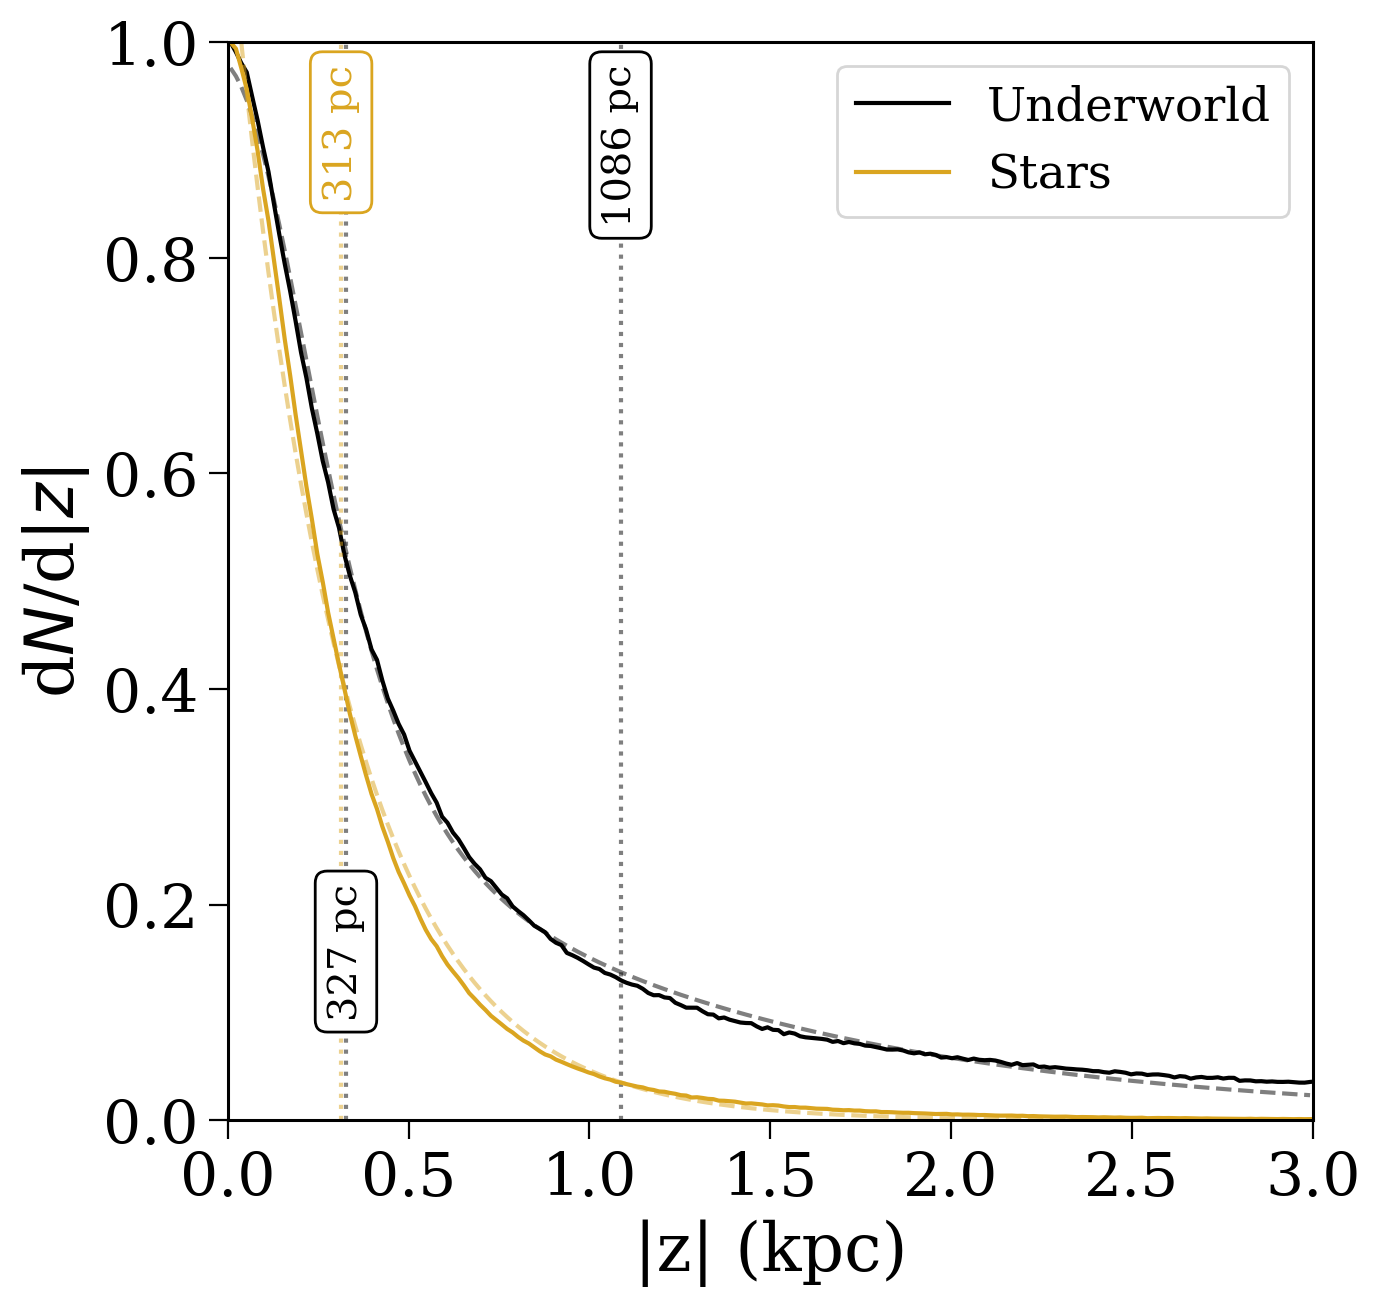

In [30]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], stars.z],
    ["Underworld", "Stars"],
    ["black", "goldenrod"]
):
    # print(np.percentile(abs(kinematics["Fiducial"]["pos"]["CO"][:, 2])[~kinematics["Fiducial"]["escaped"]["CO"]], [50, 75, 90, 95, 99]))
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2 if label == "Underworld" else 1,
        scale_height_locs=[0.98 if label == "Underworld" else 0.98, 0.22]
    )

plt.savefig("../plots/scale_height_underworld_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

1.0859652694520014
0.3268356592947922
0.8993376459397
0.3660116264496322
1.2022057913894306
0.30798419705770735
0.31332619806642137


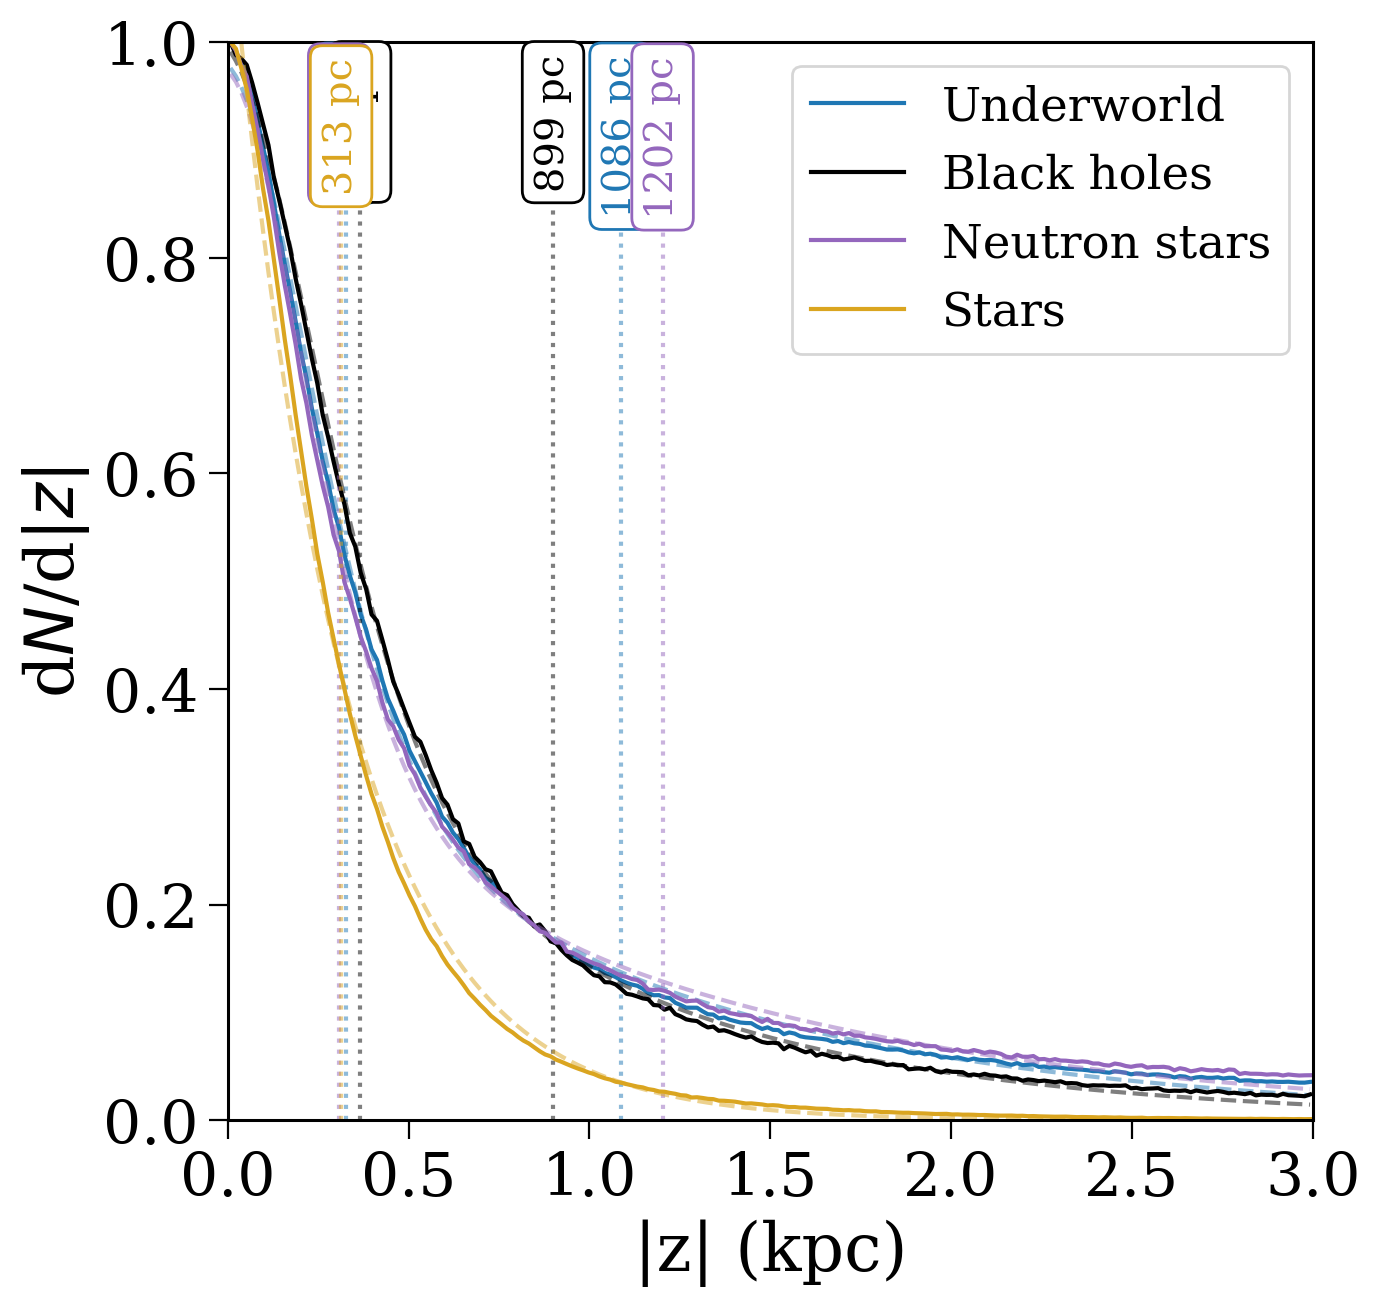

In [27]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], kinematics["Fiducial"]["pos"]["BH"][:, 2], kinematics["Fiducial"]["pos"]["NS"][:, 2], stars.z],
    ["Underworld", "Black holes", "Neutron stars", "Stars"],
    ["tab:blue", "black", "tab:purple", "goldenrod"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=1 if label == "Stars" else 2
    )

plt.show()

{'norm': <matplotlib.colors.LogNorm object at 0x1488640cca10>}
{'norm': <matplotlib.colors.LogNorm object at 0x1488640a1850>}


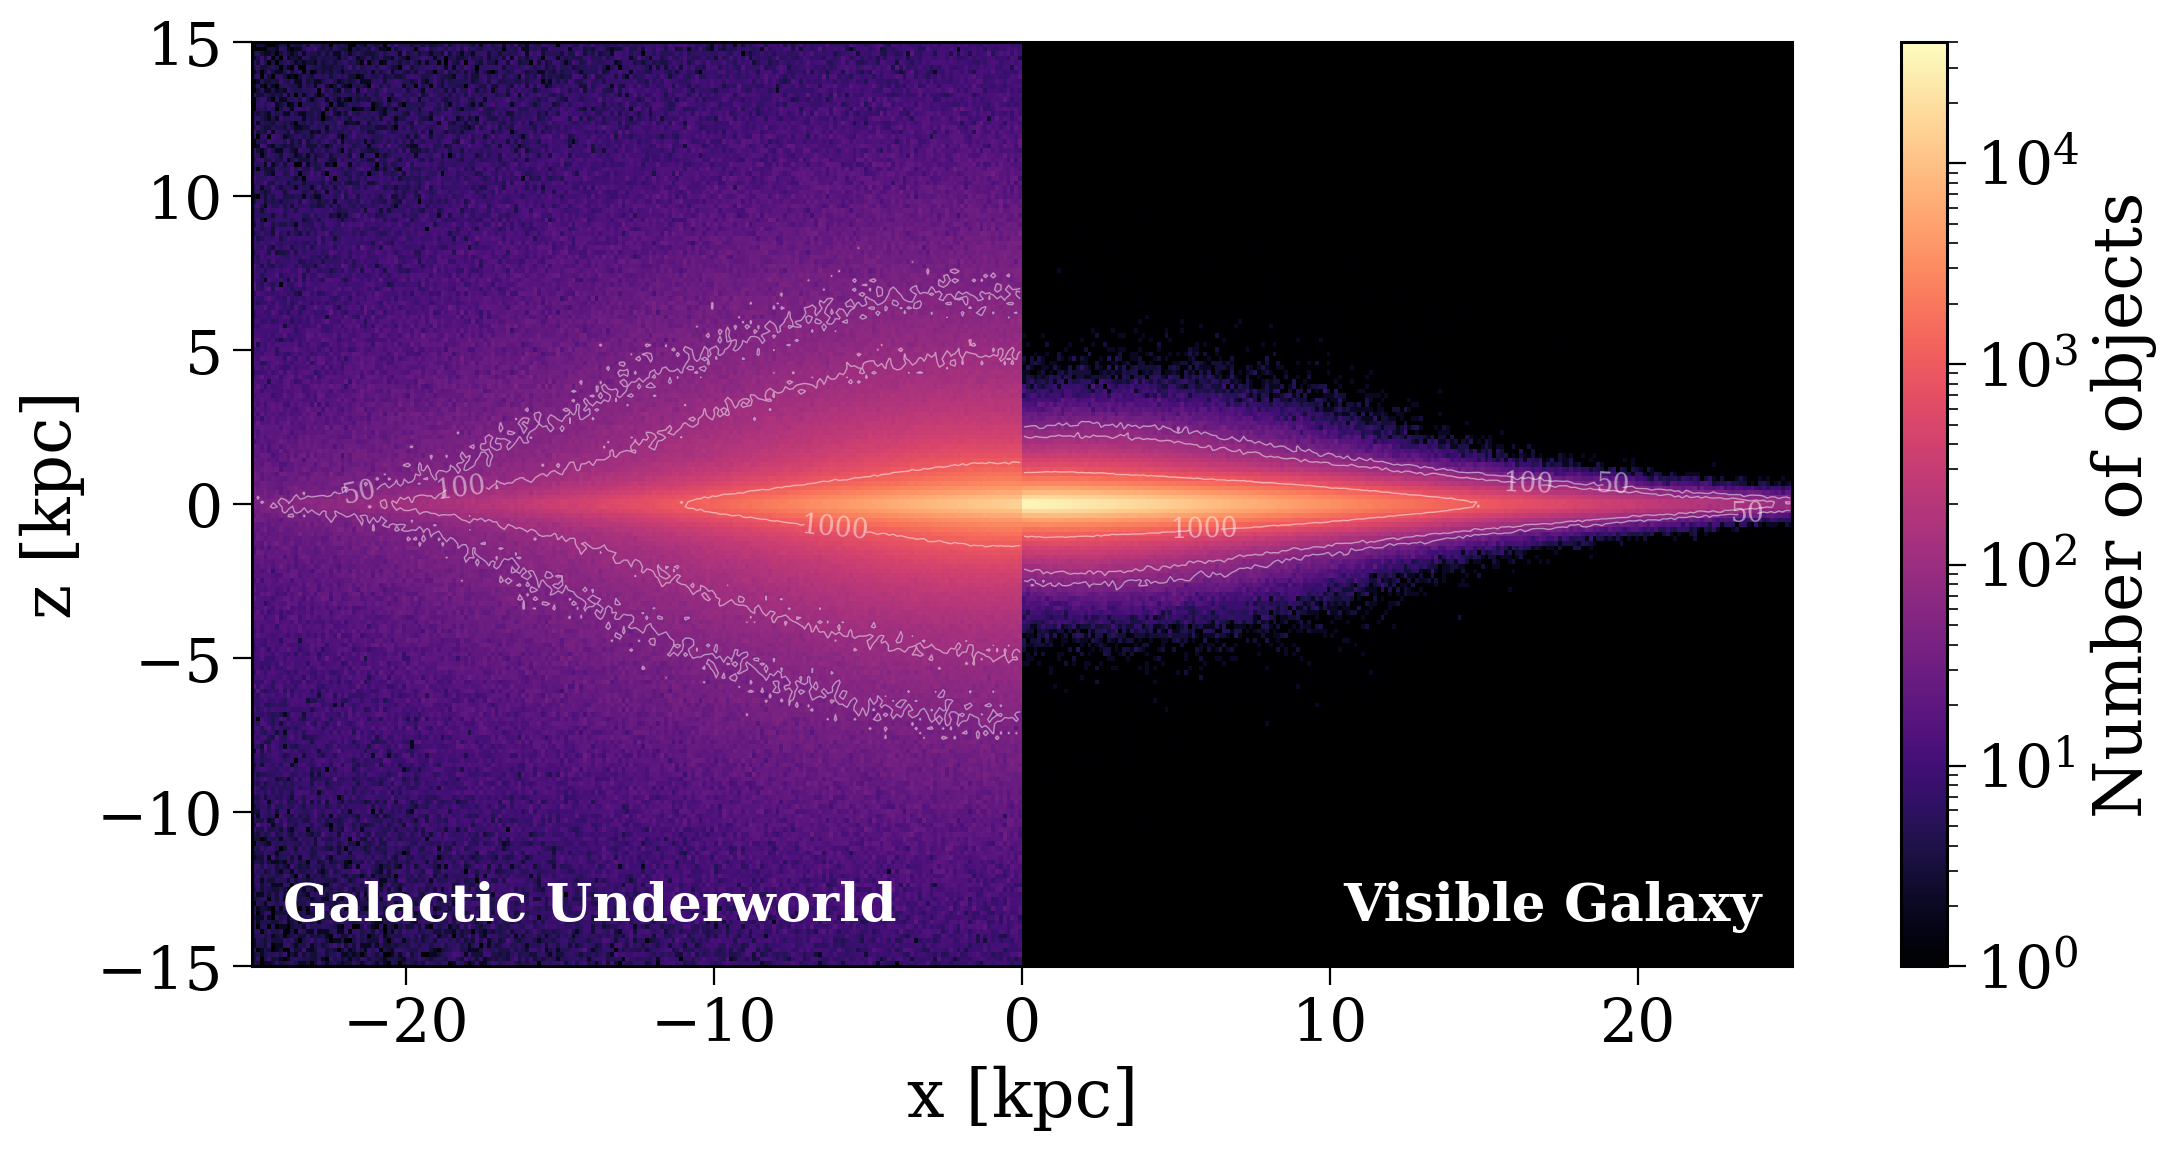

In [125]:
reload(plotting)
fig, ax = plotting.plot_side_on_density(
    xs=[stars.x, kinematics["Fiducial"]["pos"]["CO"][:, 0]],
    zs=[stars.z, kinematics["Fiducial"]["pos"]["CO"][:, 2]],
    labels=["Galactic Underworld", "Visible Galaxy"],
    xlim=25,
    zlim=15,
    n_bins=200,
    sigma=0.25,
    contours=[50, 100, 1000],
    apply_smoothing=True,
    show=False,
    norm="log",
)

# plt.savefig("../plots/density_stars_vs_underworld.pdf", format="pdf", bbox_inches='tight')
plt.show()

{'norm': <matplotlib.colors.LogNorm object at 0x148862cb65d0>}
{'norm': <matplotlib.colors.LogNorm object at 0x148862c9e3d0>}


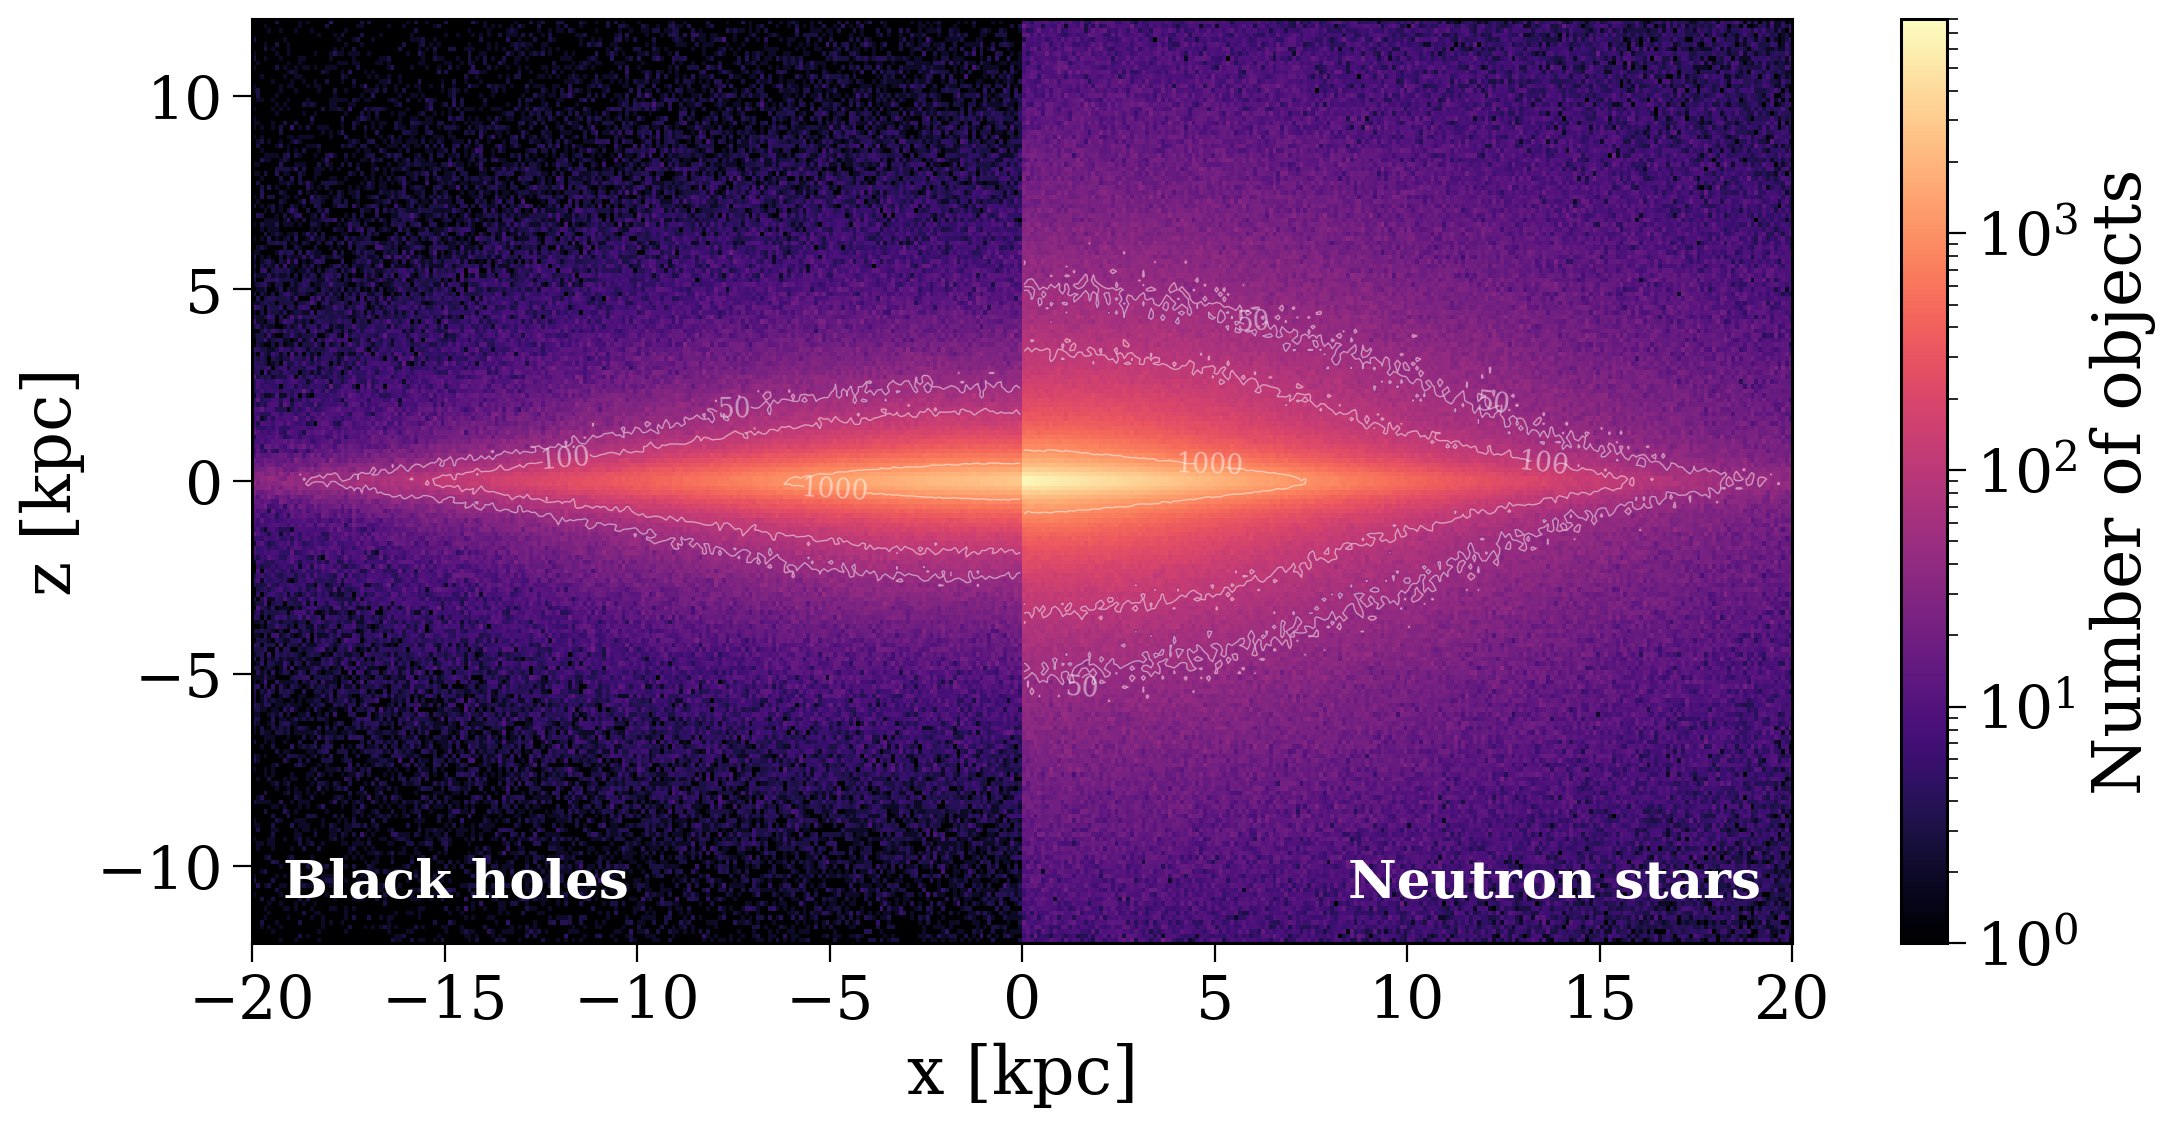

In [127]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[kinematics["Fiducial"]["pos"]["NS"][:, 0], kinematics["Fiducial"]["pos"]["BH"][:, 0]],
    zs=[kinematics["Fiducial"]["pos"]["NS"][:, 2], kinematics["Fiducial"]["pos"]["BH"][:, 2]],
    labels=["Black holes", "Neutron stars"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=1.0,
    contours=[50, 100, 1000],
    apply_smoothing=False,
    show=False,
)

# plt.savefig("../plots/density_bh_vs_ns.pdf", format="pdf", bbox_inches='tight')
plt.show()

{'norm': <matplotlib.colors.LogNorm object at 0x148862428310>}
{'norm': <matplotlib.colors.LogNorm object at 0x148862576f10>}


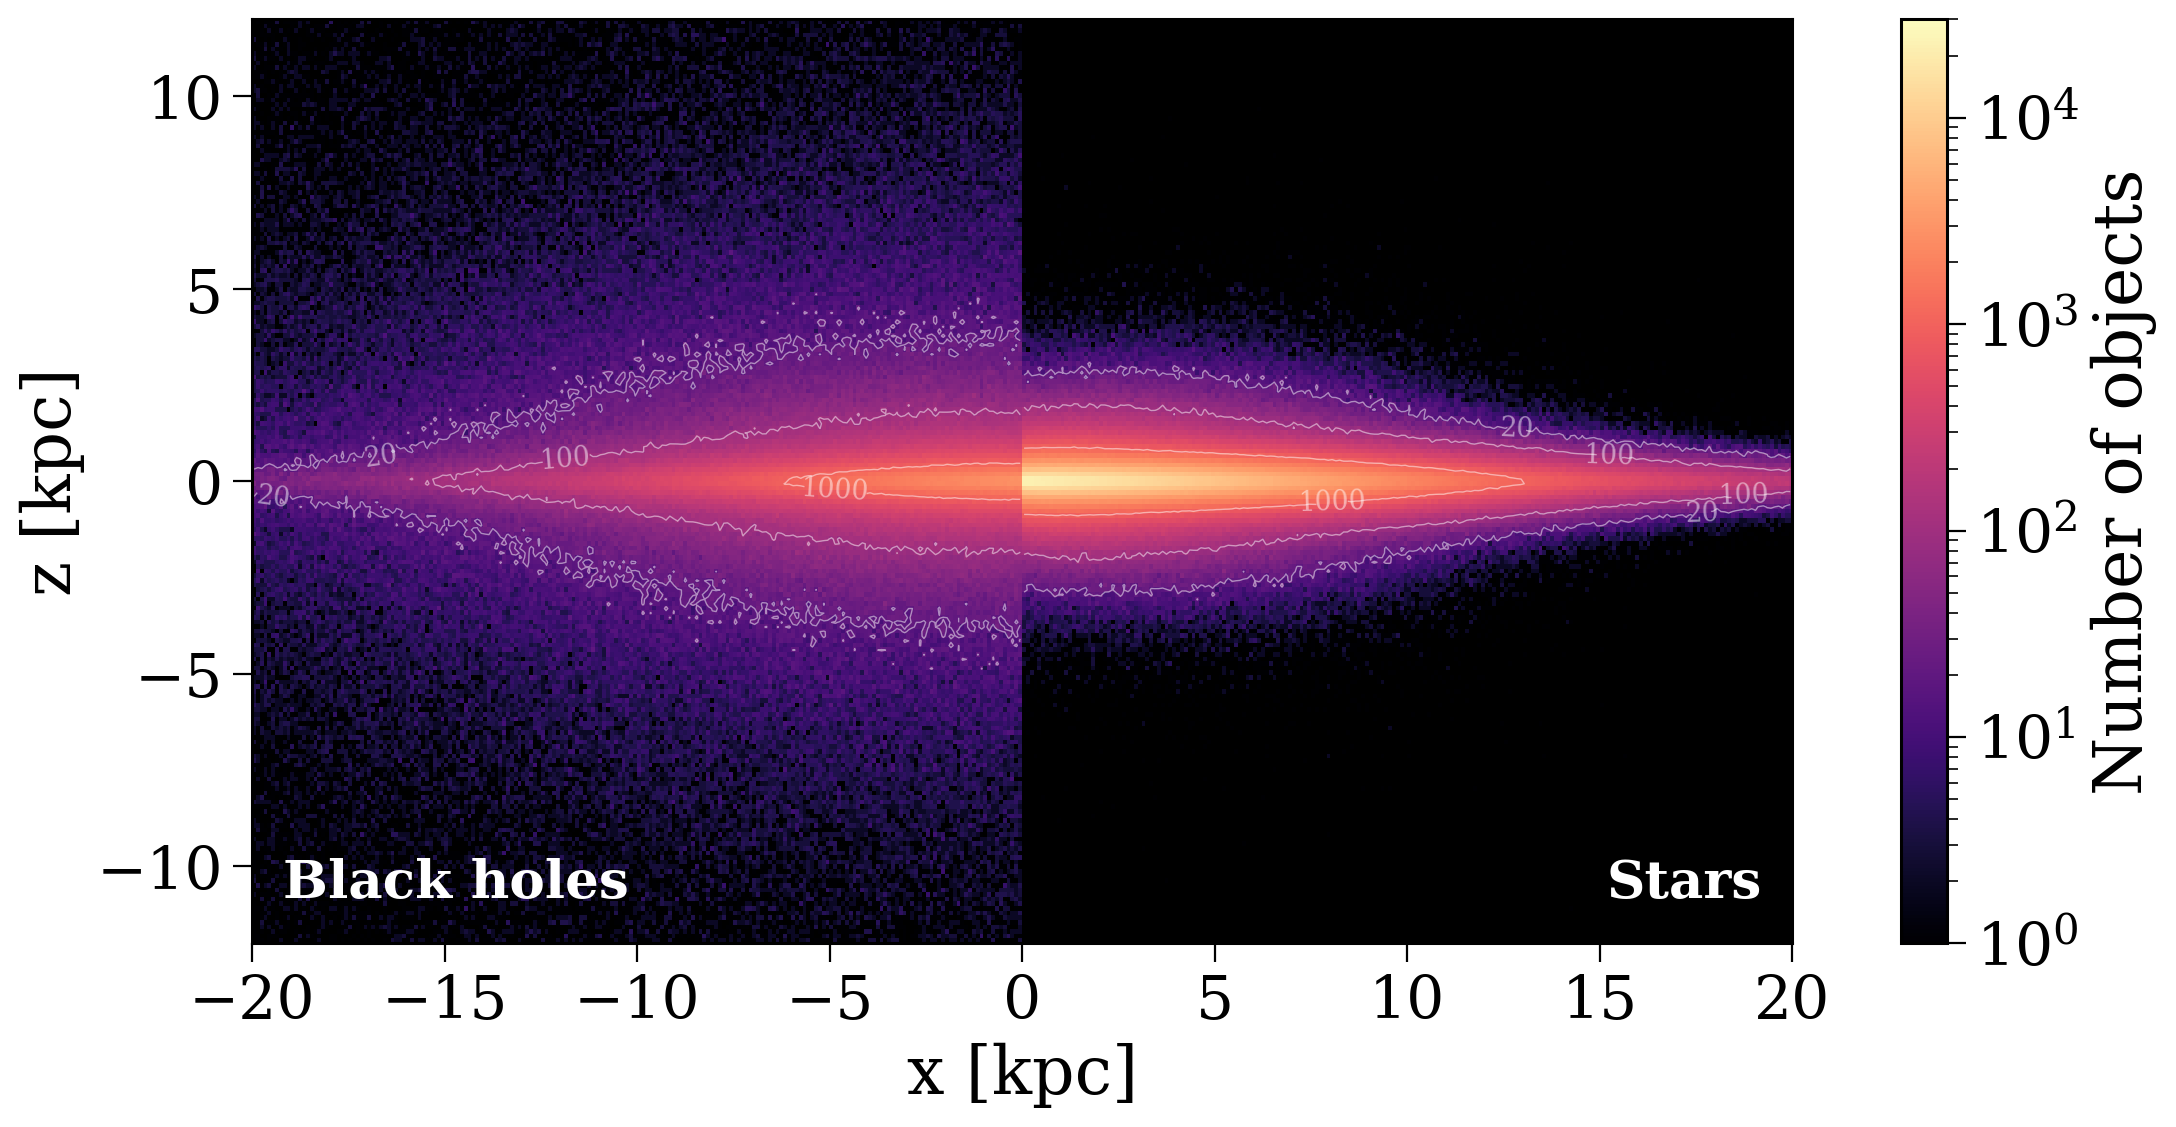

In [131]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[stars.x, kinematics["Fiducial"]["pos"]["BH"][:, 0]],
    zs=[stars.z, kinematics["Fiducial"]["pos"]["BH"][:, 2]],
    labels=["Black holes", "Stars"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=1.0,
    contours=[20, 100, 1000],
    apply_smoothing=False,
    show=False
)

plt.show()

# Mass distributions

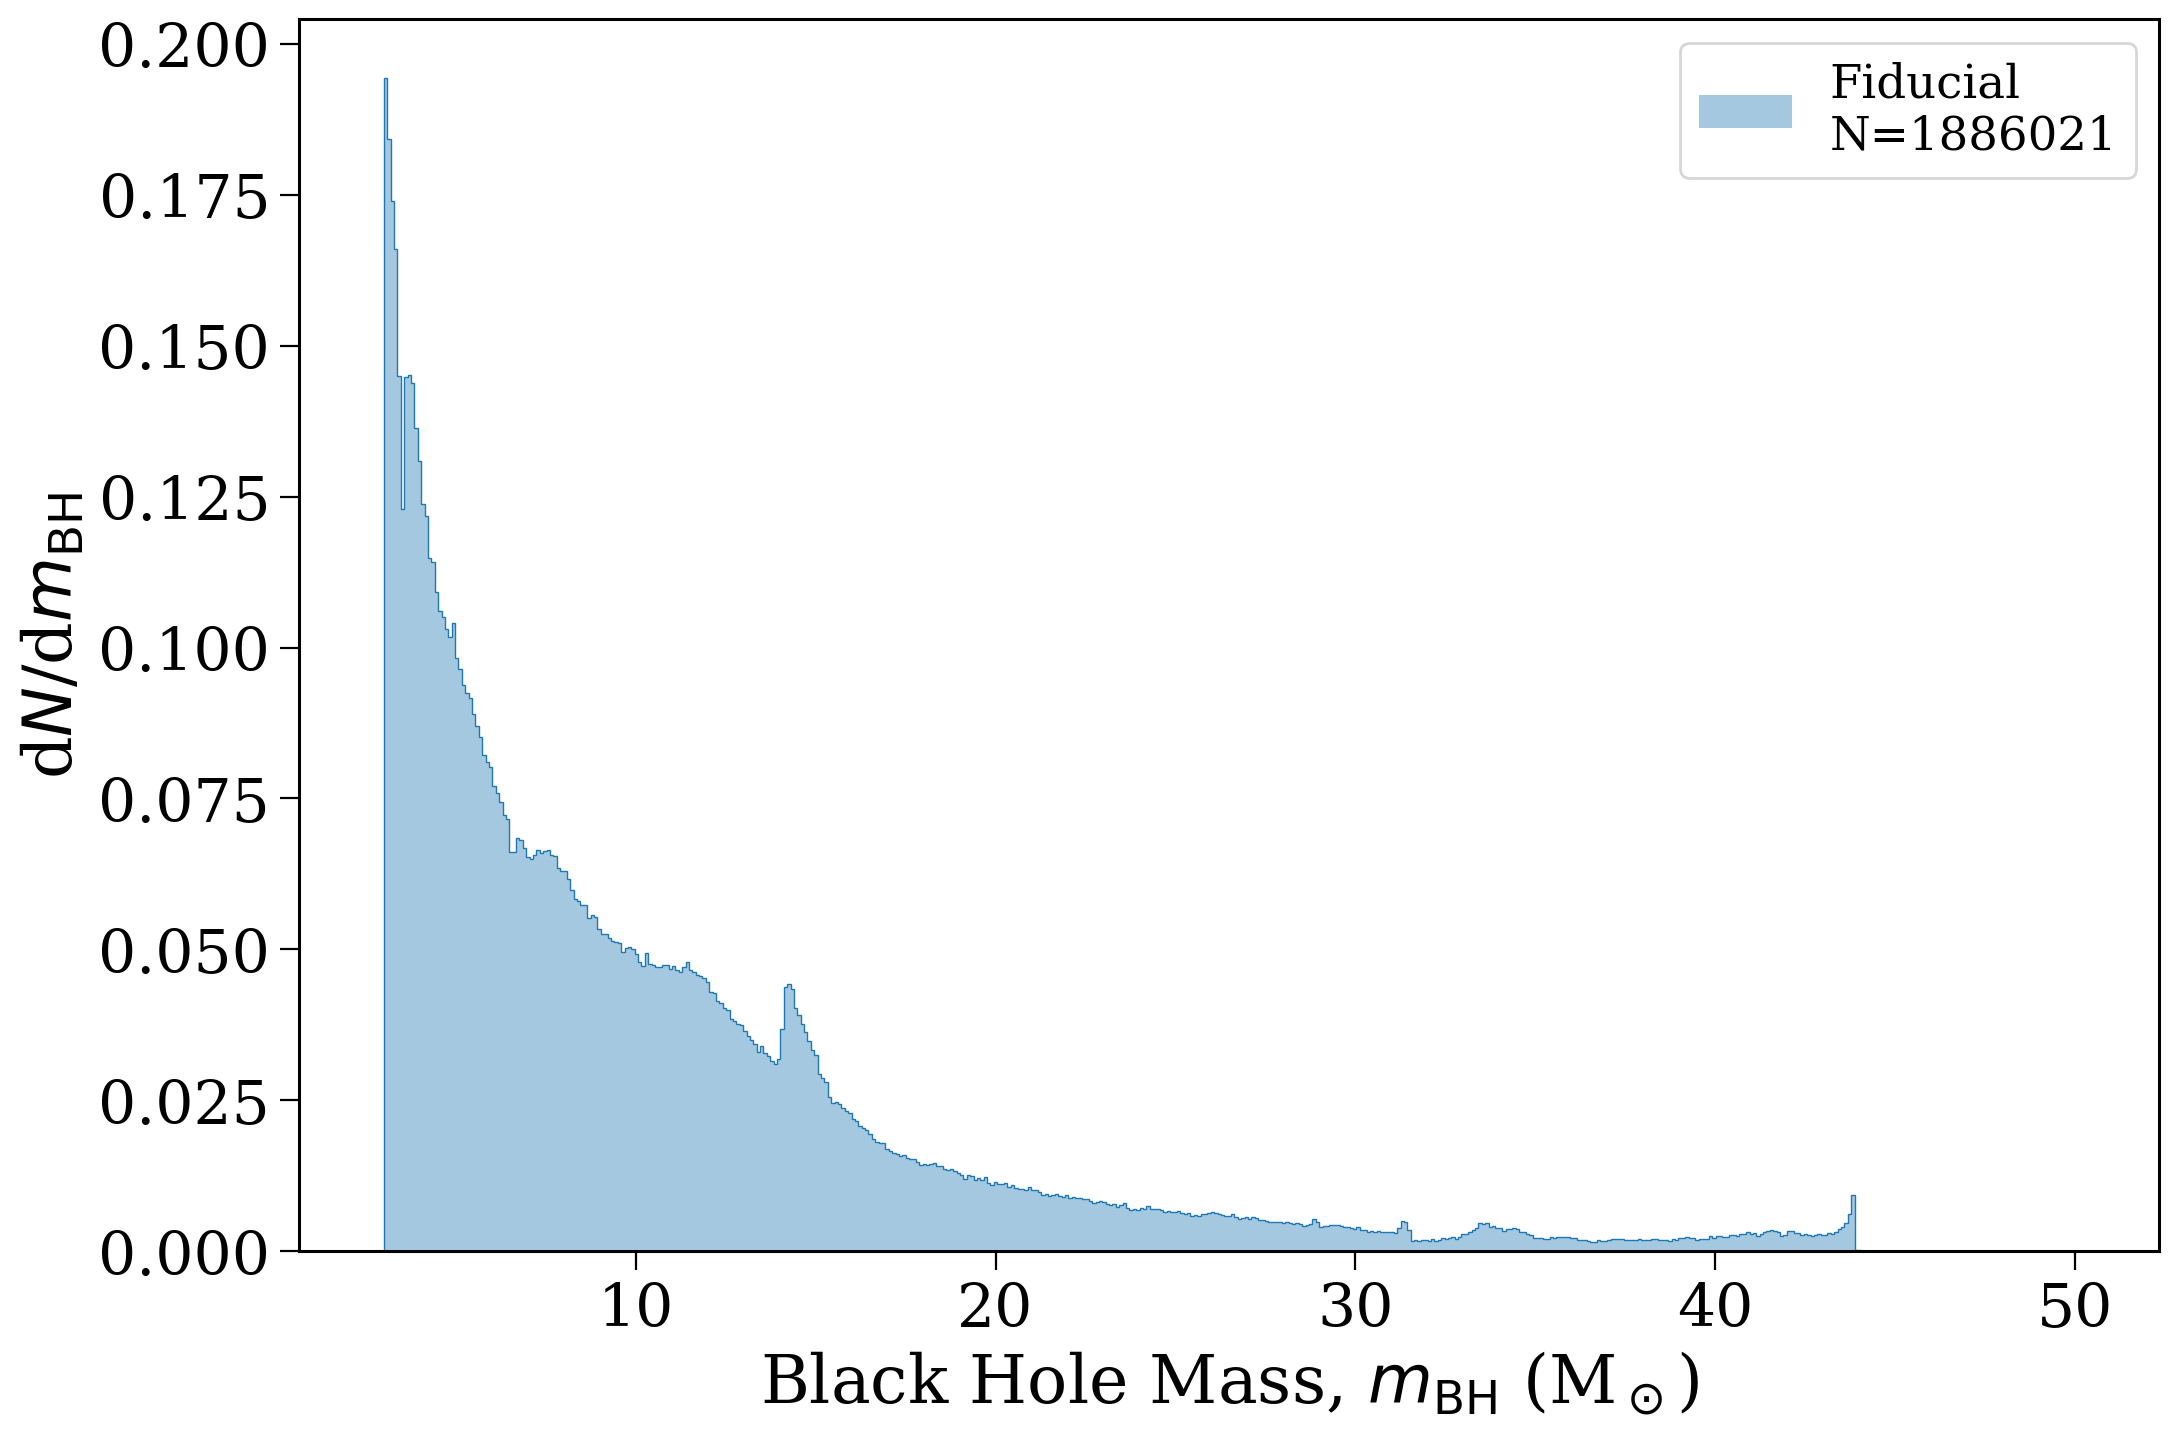

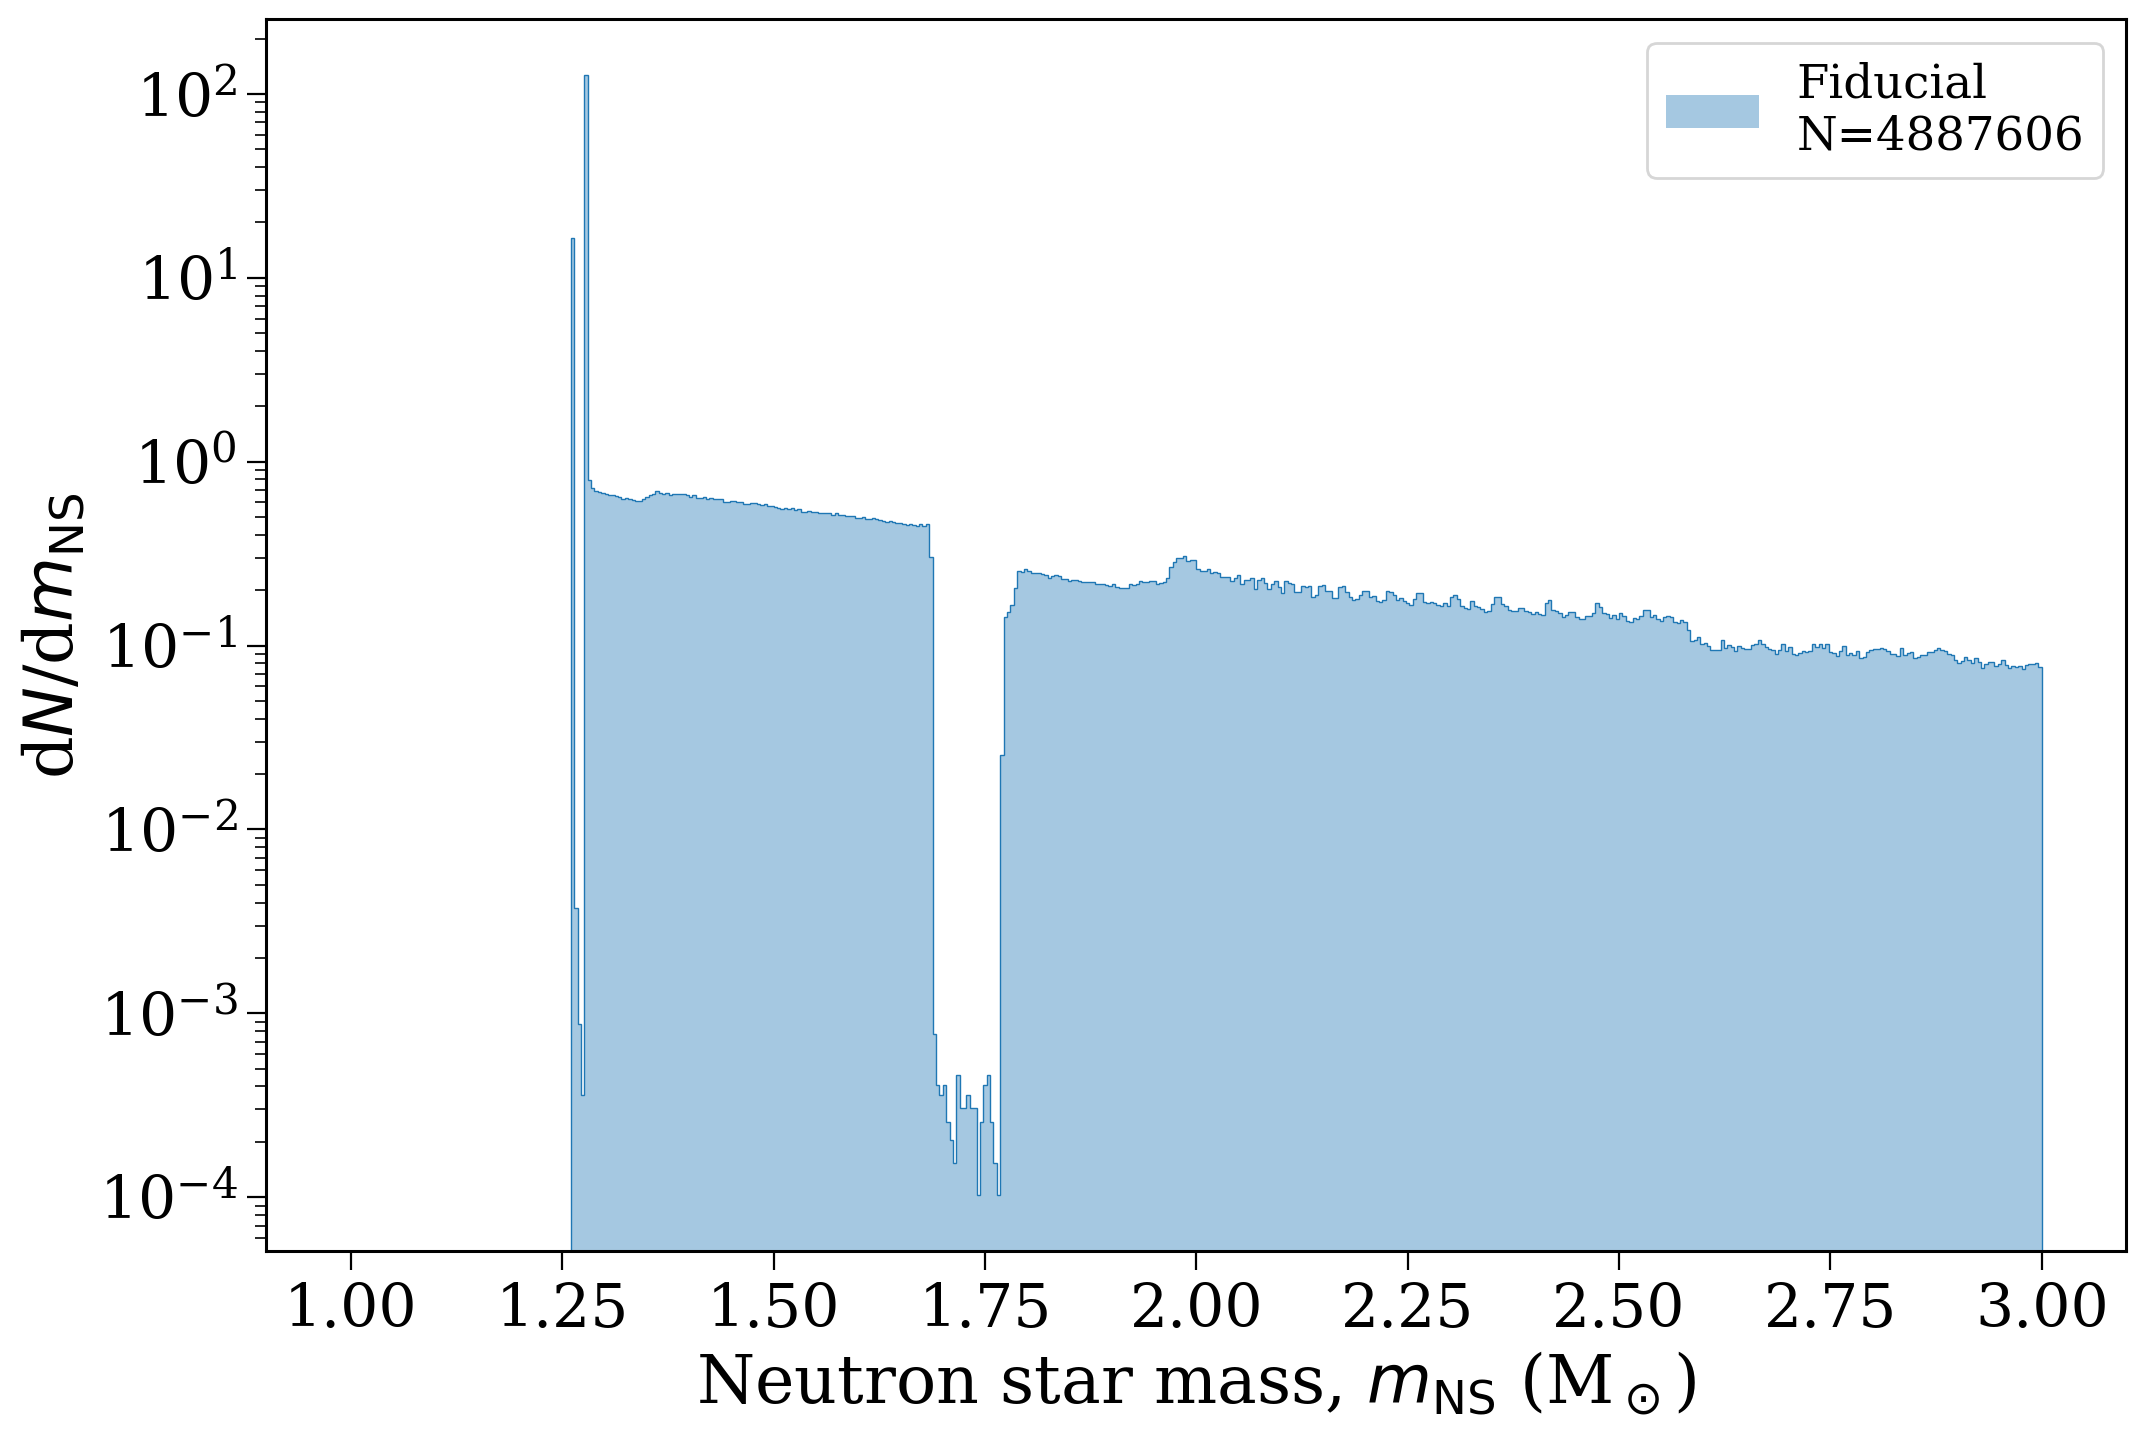

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Neutron star mass, $m_{\\rm NS}$ (M$_\\odot$)', ylabel='d$N$/d$m_{\\rm NS}$'>)

In [41]:
reload(plotting)
fig, ax = plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 50, 500),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False,
    lw=0.5
)
plt.savefig("../plots/bh_mass_distribution.pdf", format="pdf", bbox_inches='tight')
plt.show()

plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=13,
    bins=np.linspace(1, 3, 501),
    xlabel=r"Neutron star mass, $m_{\rm NS}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm NS}$",
    yscale='log',
    lw=0.5
)

In [172]:
pop.bpp.loc[190919]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_1,massc_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,bin_num,row_num
190919,0.000000,14.858191,3.621039,1,1,1752.614831,1978.153329,0.003037,1,0.005437,0.004536,0.000000,0.000000,1.831542e+04,1.726247e+02,3.083663e+04,14480.998011,0,0,190919,1395022
190919,13.311862,14.572540,3.621006,2,1,1780.128474,2040.753258,0.003037,2,0.013012,0.004578,3.579956,0.000000,5.303900e+04,1.770072e+02,2.584390e+04,14353.552486,0,0,190919,1395023
190919,13.339689,14.566218,3.621008,4,1,1780.745640,2042.169414,0.003037,2,0.071994,0.004577,3.651554,0.000000,6.593449e+04,1.770172e+02,1.159988e+04,14353.297394,0,0,190919,1395024
190919,14.809301,11.374744,3.709891,5,1,1540.680418,1804.569482,0.000000,2,0.937269,0.004988,4.799841,0.000000,7.725554e+04,1.940541e+02,3.679190e+03,14562.406390,0,0,190919,1395025
190919,14.816321,11.354126,3.710761,5,1,1526.561521,1780.986764,0.000000,3,1.000974,0.005032,4.799841,0.000000,8.351116e+04,1.942236e+02,3.647610e+03,14564.503637,0,0,190919,1395026
190919,14.816321,11.354126,3.710761,5,1,1526.561521,1780.986764,0.000000,7,1.000974,0.005032,4.799841,0.000000,8.351116e+04,1.942236e+02,3.647610e+03,14564.503637,0,0,190919,1395027
190919,14.816321,4.799841,3.710761,8,1,63.965696,20.324165,0.000000,8,0.000859,0.005032,2.919009,0.000000,5.464258e+04,1.942236e+02,1.120197e+05,14564.503637,0,0,190919,1395028
190919,14.816321,4.799841,3.710761,8,1,63.965696,20.324165,0.000000,4,0.024390,0.096748,2.919009,0.000000,5.464258e+04,1.942236e+02,1.120197e+05,14564.503637,0,0,190919,1395029
190919,14.888200,4.681032,3.711041,8,1,64.859688,20.897764,0.000000,15,0.024390,0.096748,3.360026,0.000000,1.104250e+05,1.943067e+02,6.539783e+04,14564.482643,1,0,190919,1395030
190919,14.888200,1.630700,3.711041,13,1,384.482247,378.046463,0.909851,1,0.000001,2.000000,1.630700,0.000000,2.775368e+00,1.943069e+02,2.000026e+06,14564.484039,1,0,190919,1395031


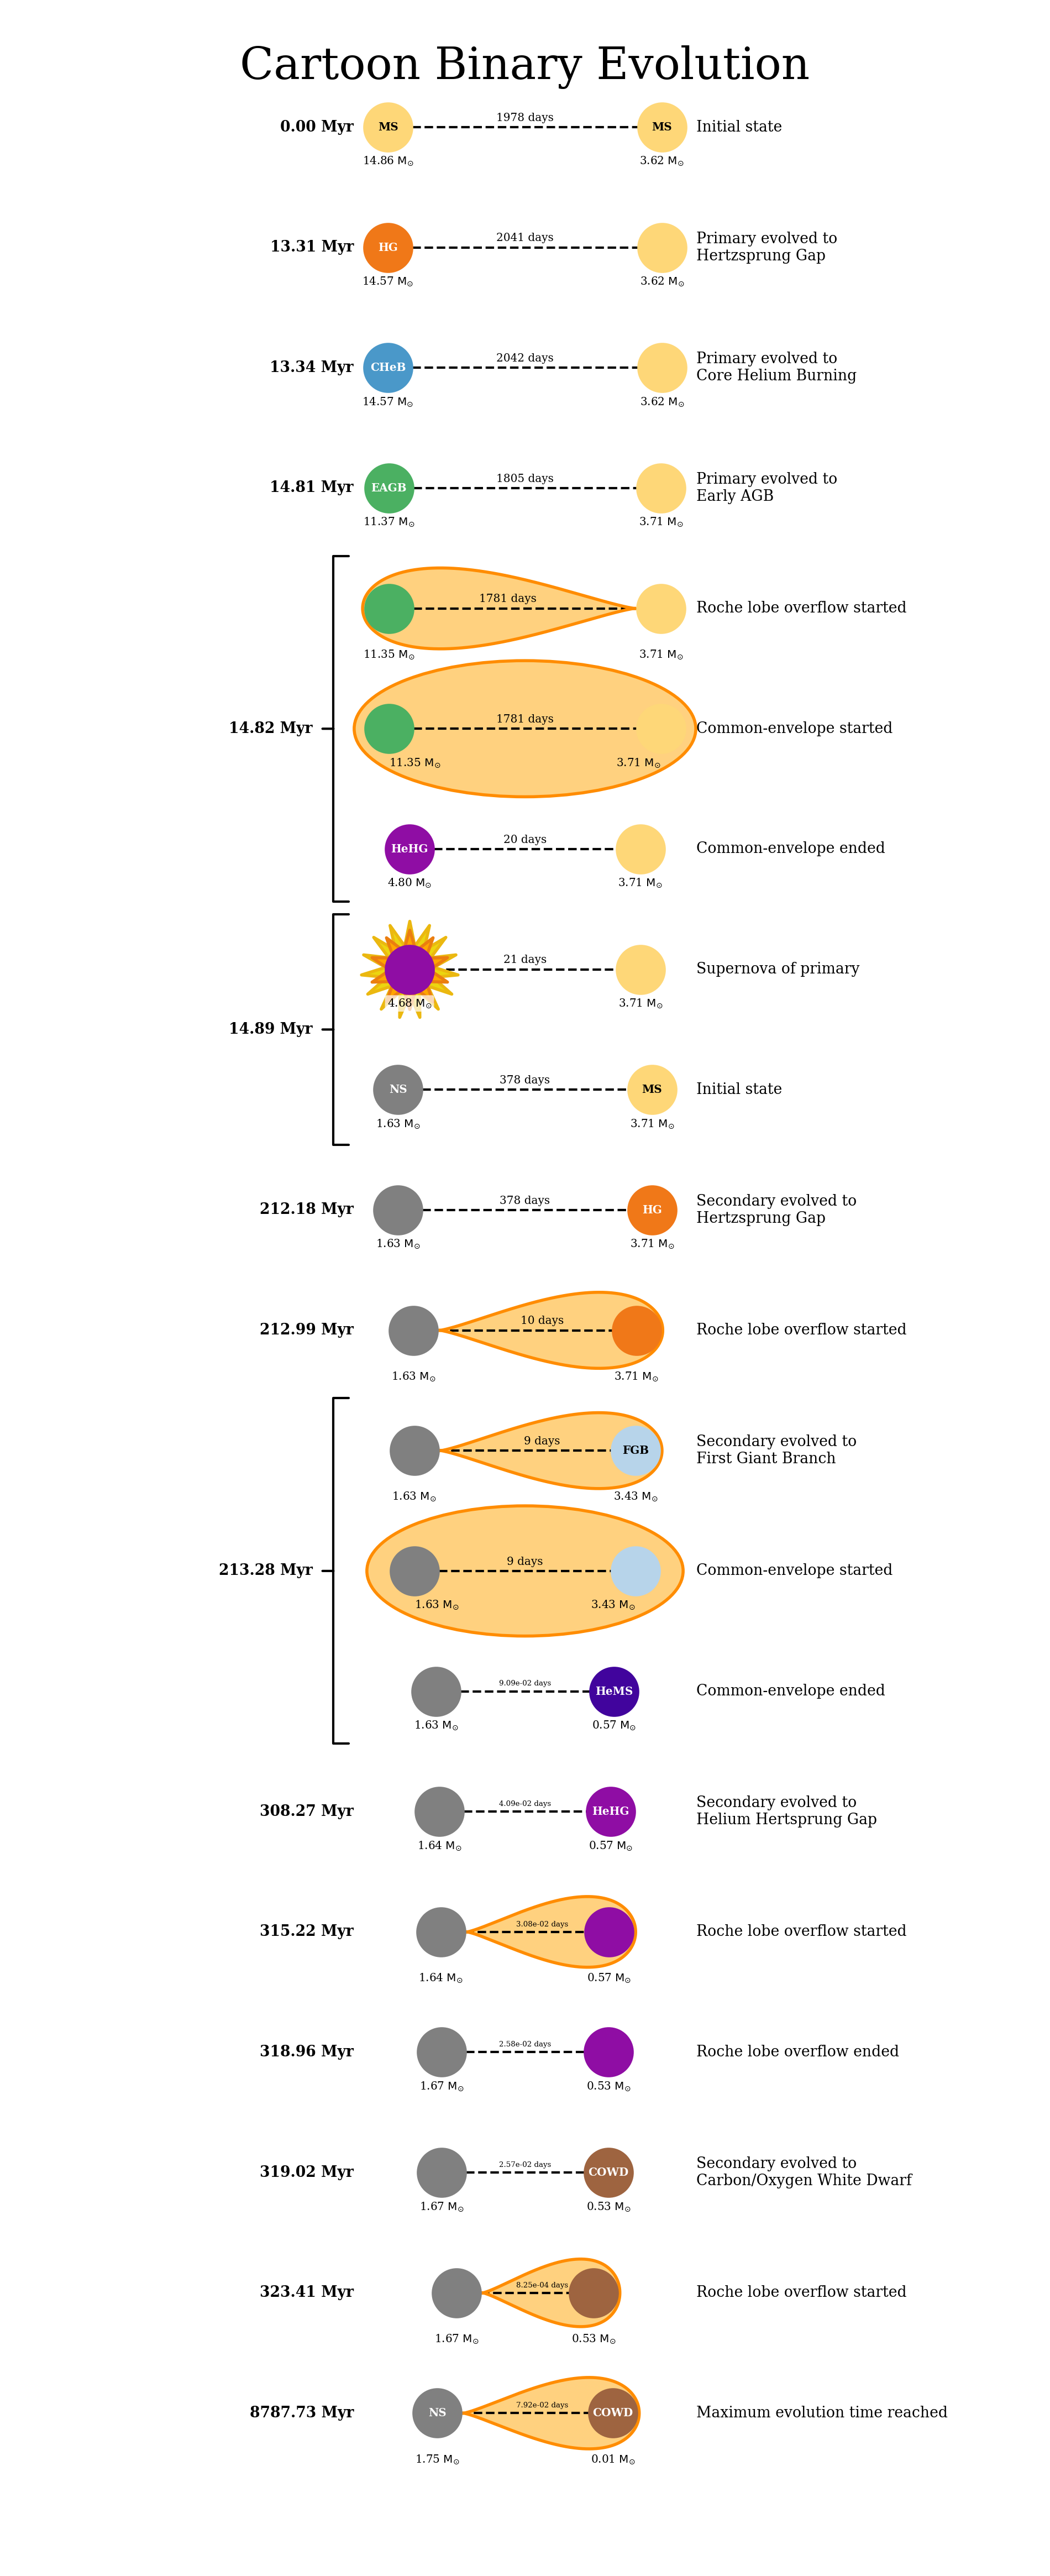

(<Figure size 1200x3000 with 1 Axes>, <Axes: >)

In [173]:
pop.plot_cartoon_binary(190919)

In [180]:
peak_15 = pop.final_bpp[((pop.final_bpp["kstar_1"] == 14) & (pop.final_bpp["mass_1"] > 14.7) & (pop.final_bpp["mass_1"] < 15.1))]#[["kstar_1", "kstar_2"]].value_counts()

In [181]:
peak_15

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_1,massc_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,bin_num,row_num,metallicity
299,3375.099206,15.026919,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,15.026919,0.000000,1.000000e-10,3.263424e+05,2296.950869,2.851714e+04,1,0,299,2193,0.021029
896,9330.731142,14.896476,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,14.896476,0.000000,1.000000e-10,4.620581e+04,2306.985725,3.369950e+04,1,0,896,6603,0.002361
3556,2930.027945,15.011560,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,15.011560,0.000000,1.000000e-10,2.884369e+05,2298.125614,3.512376e+04,1,0,3556,27109,0.015678
3745,10273.329353,14.751682,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,14.751682,0.000000,1.000000e-10,1.000000e-10,2318.280113,1.833452e+06,1,0,3745,28359,0.004269
4433,9926.809079,14.750897,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,14.750897,0.000000,1.000000e-10,2.174844e+04,2318.341833,3.083915e+04,1,0,4433,33199,0.004600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10805700,11460.000632,15.080090,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,15.080090,0.000000,1.000000e-10,1.354924e+05,2292.897930,3.810587e+04,1,0,10805700,78912773,0.001188
10805753,7805.618316,14.934721,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,14.934721,0.000000,1.000000e-10,2.054026e+04,2304.030016,2.965476e+04,1,0,10805753,78913242,0.004727
10806080,5822.465893,14.750733,4.471093,14,14,-1.0,-1.0,-1.0,10,0.0001,0.0001,14.750733,4.471093,1.000000e-10,1.000000e-10,2318.354668,4.210948e+03,1,1,10806080,78915530,0.005460
10806093,2092.932801,14.721205,0.000000,14,15,0.0,0.0,-1.0,10,0.0001,-1.0000,14.721205,0.000000,1.000000e-10,2.916595e+05,2320.678616,2.991693e+04,1,0,10806093,78915620,0.012808


In [186]:
pop.bpp.loc[peak_15["bin_num"].values[0]]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_1,massc_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,bin_num,row_num
299,0.000000,50.028545,37.361634,1,1,248.334829,48.517375,0.095659,1,0.128089,0.120499,0.000000,0.0,3.722306e+05,203823.284900,41986.605023,39805.222799,0,0,299,2182
299,4.206800,37.618971,34.073174,2,1,293.693598,68.893475,0.094170,2,0.345568,0.239327,12.886311,0.0,4.969411e+05,326007.637636,25790.608310,28528.914829,0,0,299,2183
299,4.208343,37.598412,34.073982,2,1,266.057433,59.409965,0.000000,3,1.000995,0.239517,12.954463,0.0,4.865370e+05,326123.614928,15073.904180,28517.108741,0,0,299,2184
299,4.209586,37.576229,34.084857,2,1,266.033392,59.406600,0.000000,5,2.358858,0.239568,13.009364,0.0,4.783143e+05,326342.392605,9779.195333,28517.143149,0,0,299,2185
299,4.209586,37.576229,34.084857,2,1,266.033392,59.406600,0.000000,7,2.358858,0.239568,13.009364,0.0,4.783143e+05,326342.392605,9779.195333,28517.143149,0,0,299,2186
299,4.209586,68.202670,34.084857,2,15,0.000000,0.000000,0.000000,8,0.990000,0.239568,29.055725,0.0,4.783143e+05,326342.392605,9779.195333,28517.143149,0,0,299,2187
299,4.211451,67.922905,0.000000,4,15,0.000000,0.000000,-1.000000,2,0.000100,-1.000000,29.356478,0.0,1.389302e+06,326342.392605,3529.584736,28517.143149,0,0,299,2188
299,4.440395,33.581281,0.000000,7,15,0.000000,0.000000,-1.000000,2,0.000100,-1.000000,0.000000,0.0,1.345517e+06,326342.392605,138694.361440,28517.143149,0,0,299,2189
299,4.613072,15.802027,0.000000,8,15,0.000000,0.000000,-1.000000,2,0.000100,-1.000000,11.642420,0.0,4.716832e+05,326342.392605,136456.137998,28517.143149,0,0,299,2190
299,4.618698,15.526919,0.000000,8,15,0.000000,0.000000,-1.000000,15,0.000100,-1.000000,11.848999,0.0,5.150418e+05,326342.392605,138671.532069,28517.143149,1,0,299,2191


(array([  21.,    4.,    3.,    5.,    4.,    4.,    3.,    6.,    9.,
           4.,    9.,   14.,   15.,   13.,   21.,   17.,   18.,   23.,
          22.,   30.,   42.,   43.,   56.,   65.,   69.,   82.,   83.,
          69.,   82.,   91.,  113.,  113.,  153.,  173.,  198.,  233.,
         243.,  273.,  367.,  446.,  481.,  282.,  212.,  244.,  207.,
         224.,  294.,  300.,  279.,  317.,  376.,  333.,  411.,  518.,
        1782., 1519., 1553., 1887.,  432.,  472.,  408.,  436.,  426.,
         433.,  384.,  378.,  383.,  359.,  325.,  320.,  309.,  588.,
         286.,  131.,  127.,   84.,   77.,   80.,   53.,   44.,  198.]),
 array([-2.30103   , -2.27044825, -2.23986651, -2.20928476, -2.17870302,
        -2.14812128, -2.11753953, -2.08695779, -2.05637604, -2.0257943 ,
        -1.99521256, -1.96463081, -1.93404907, -1.90346733, -1.87288558,
        -1.84230384, -1.81172209, -1.78114035, -1.75055861, -1.71997686,
        -1.68939512, -1.65881337, -1.62823163, -1.59764989, -1.5670

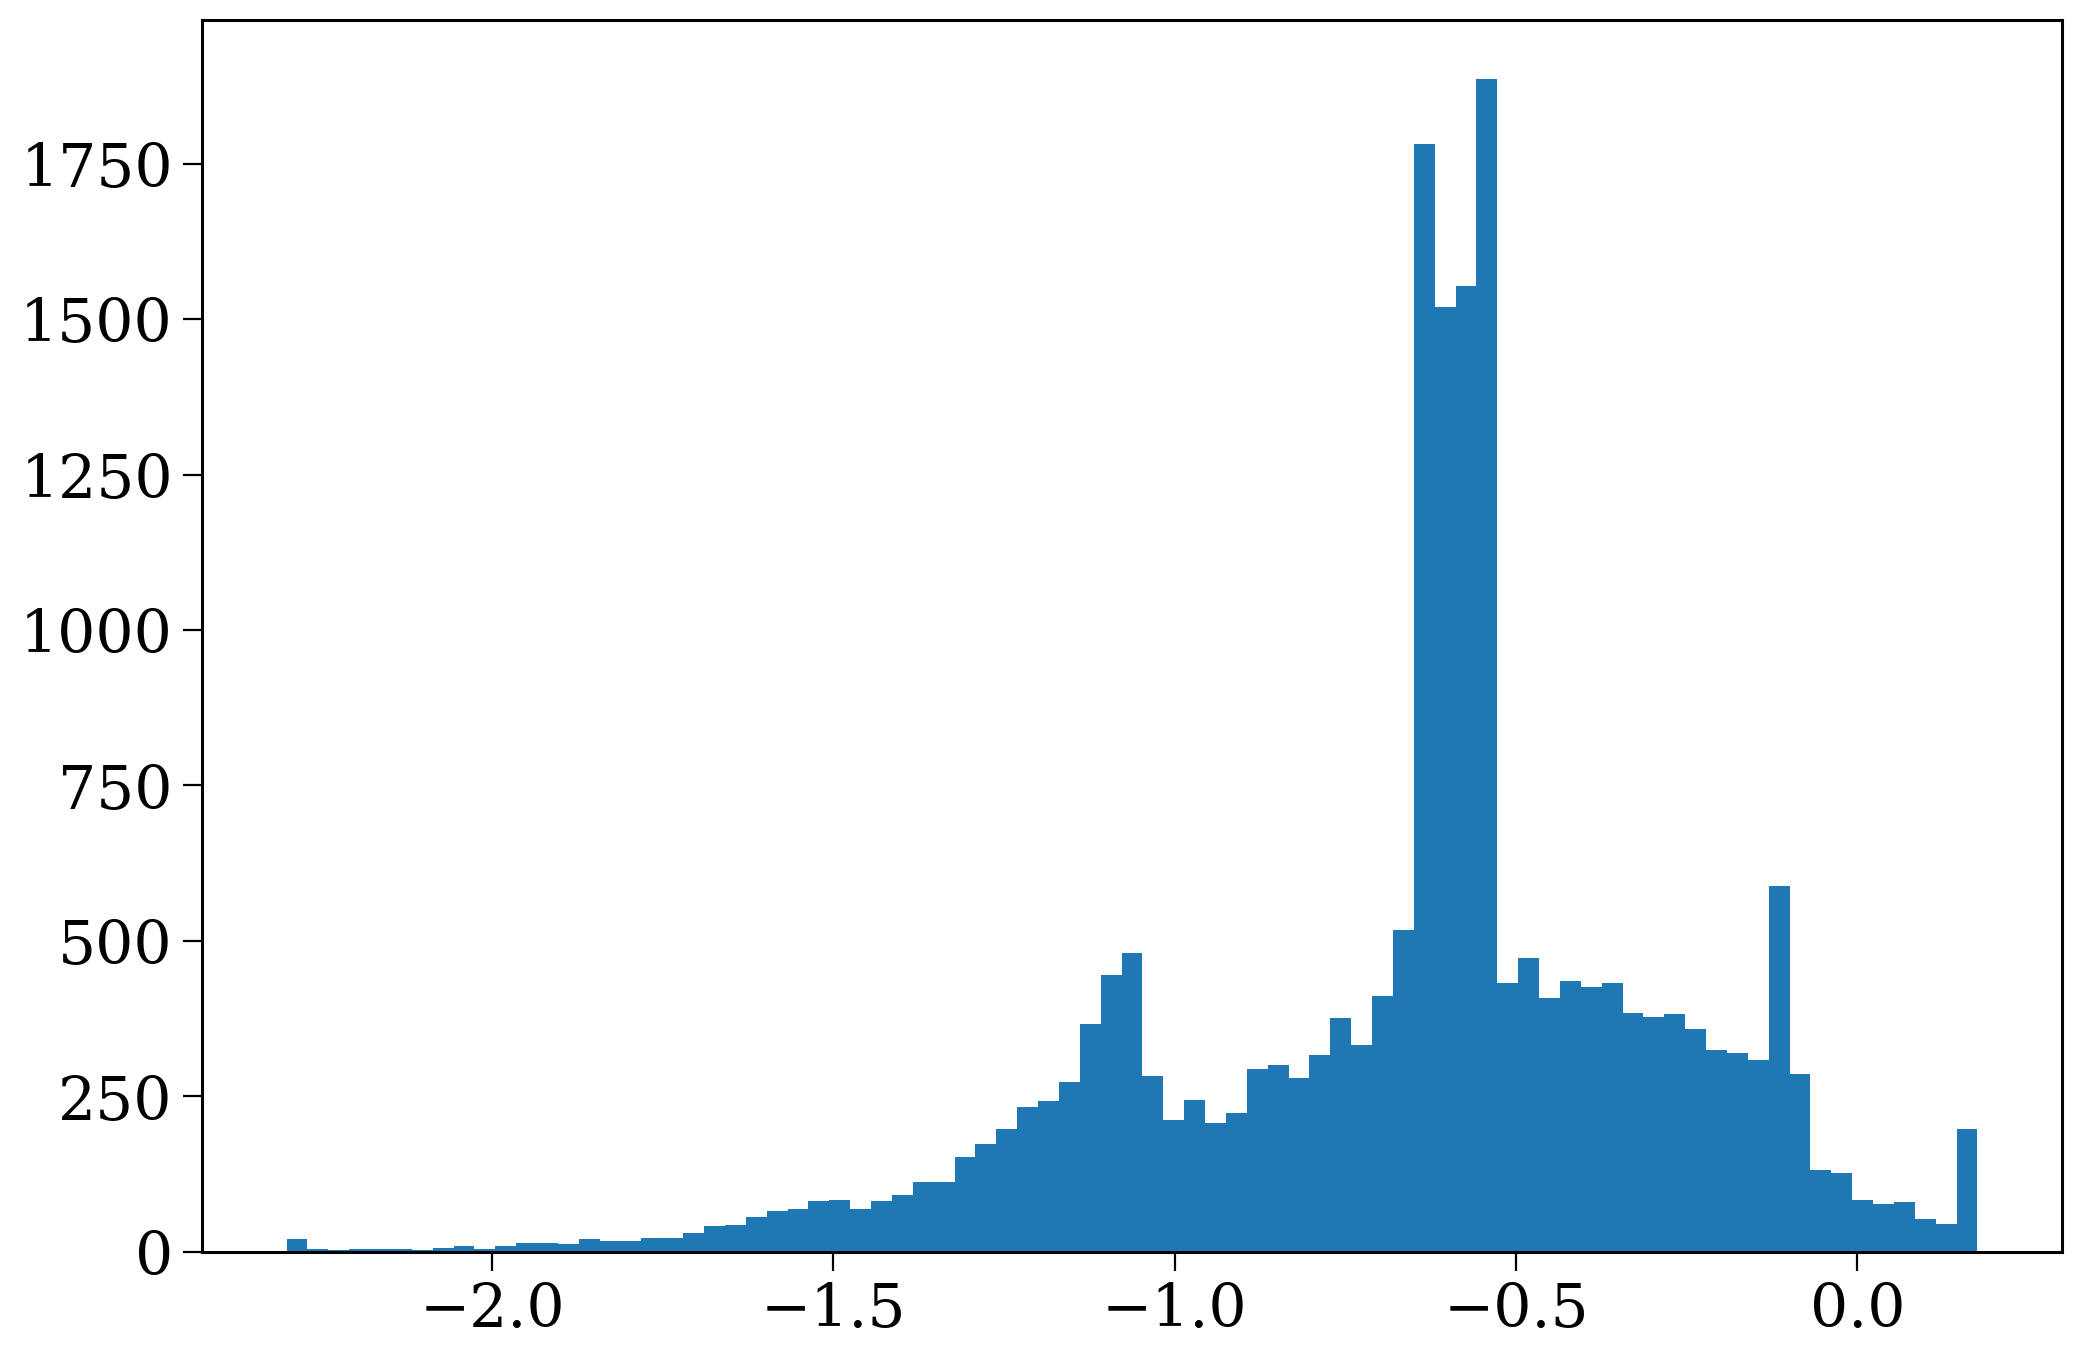

In [185]:
plt.hist(np.log10(pop.initC.loc[peak_15["bin_num"]]["metallicity"] / 0.02), bins="fd")

# Spatial vs. Mass

Larger mass objects (particularly BHs) are going to get different kicks, we should see that show up in their distribution

In [50]:
masses = {
    "BH": np.concatenate((
        pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
        pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
    )),
    "NS": np.concatenate((
        pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
        pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
    )),
}
masses["CO"] = np.concatenate((masses["NS"], masses["BH"]))

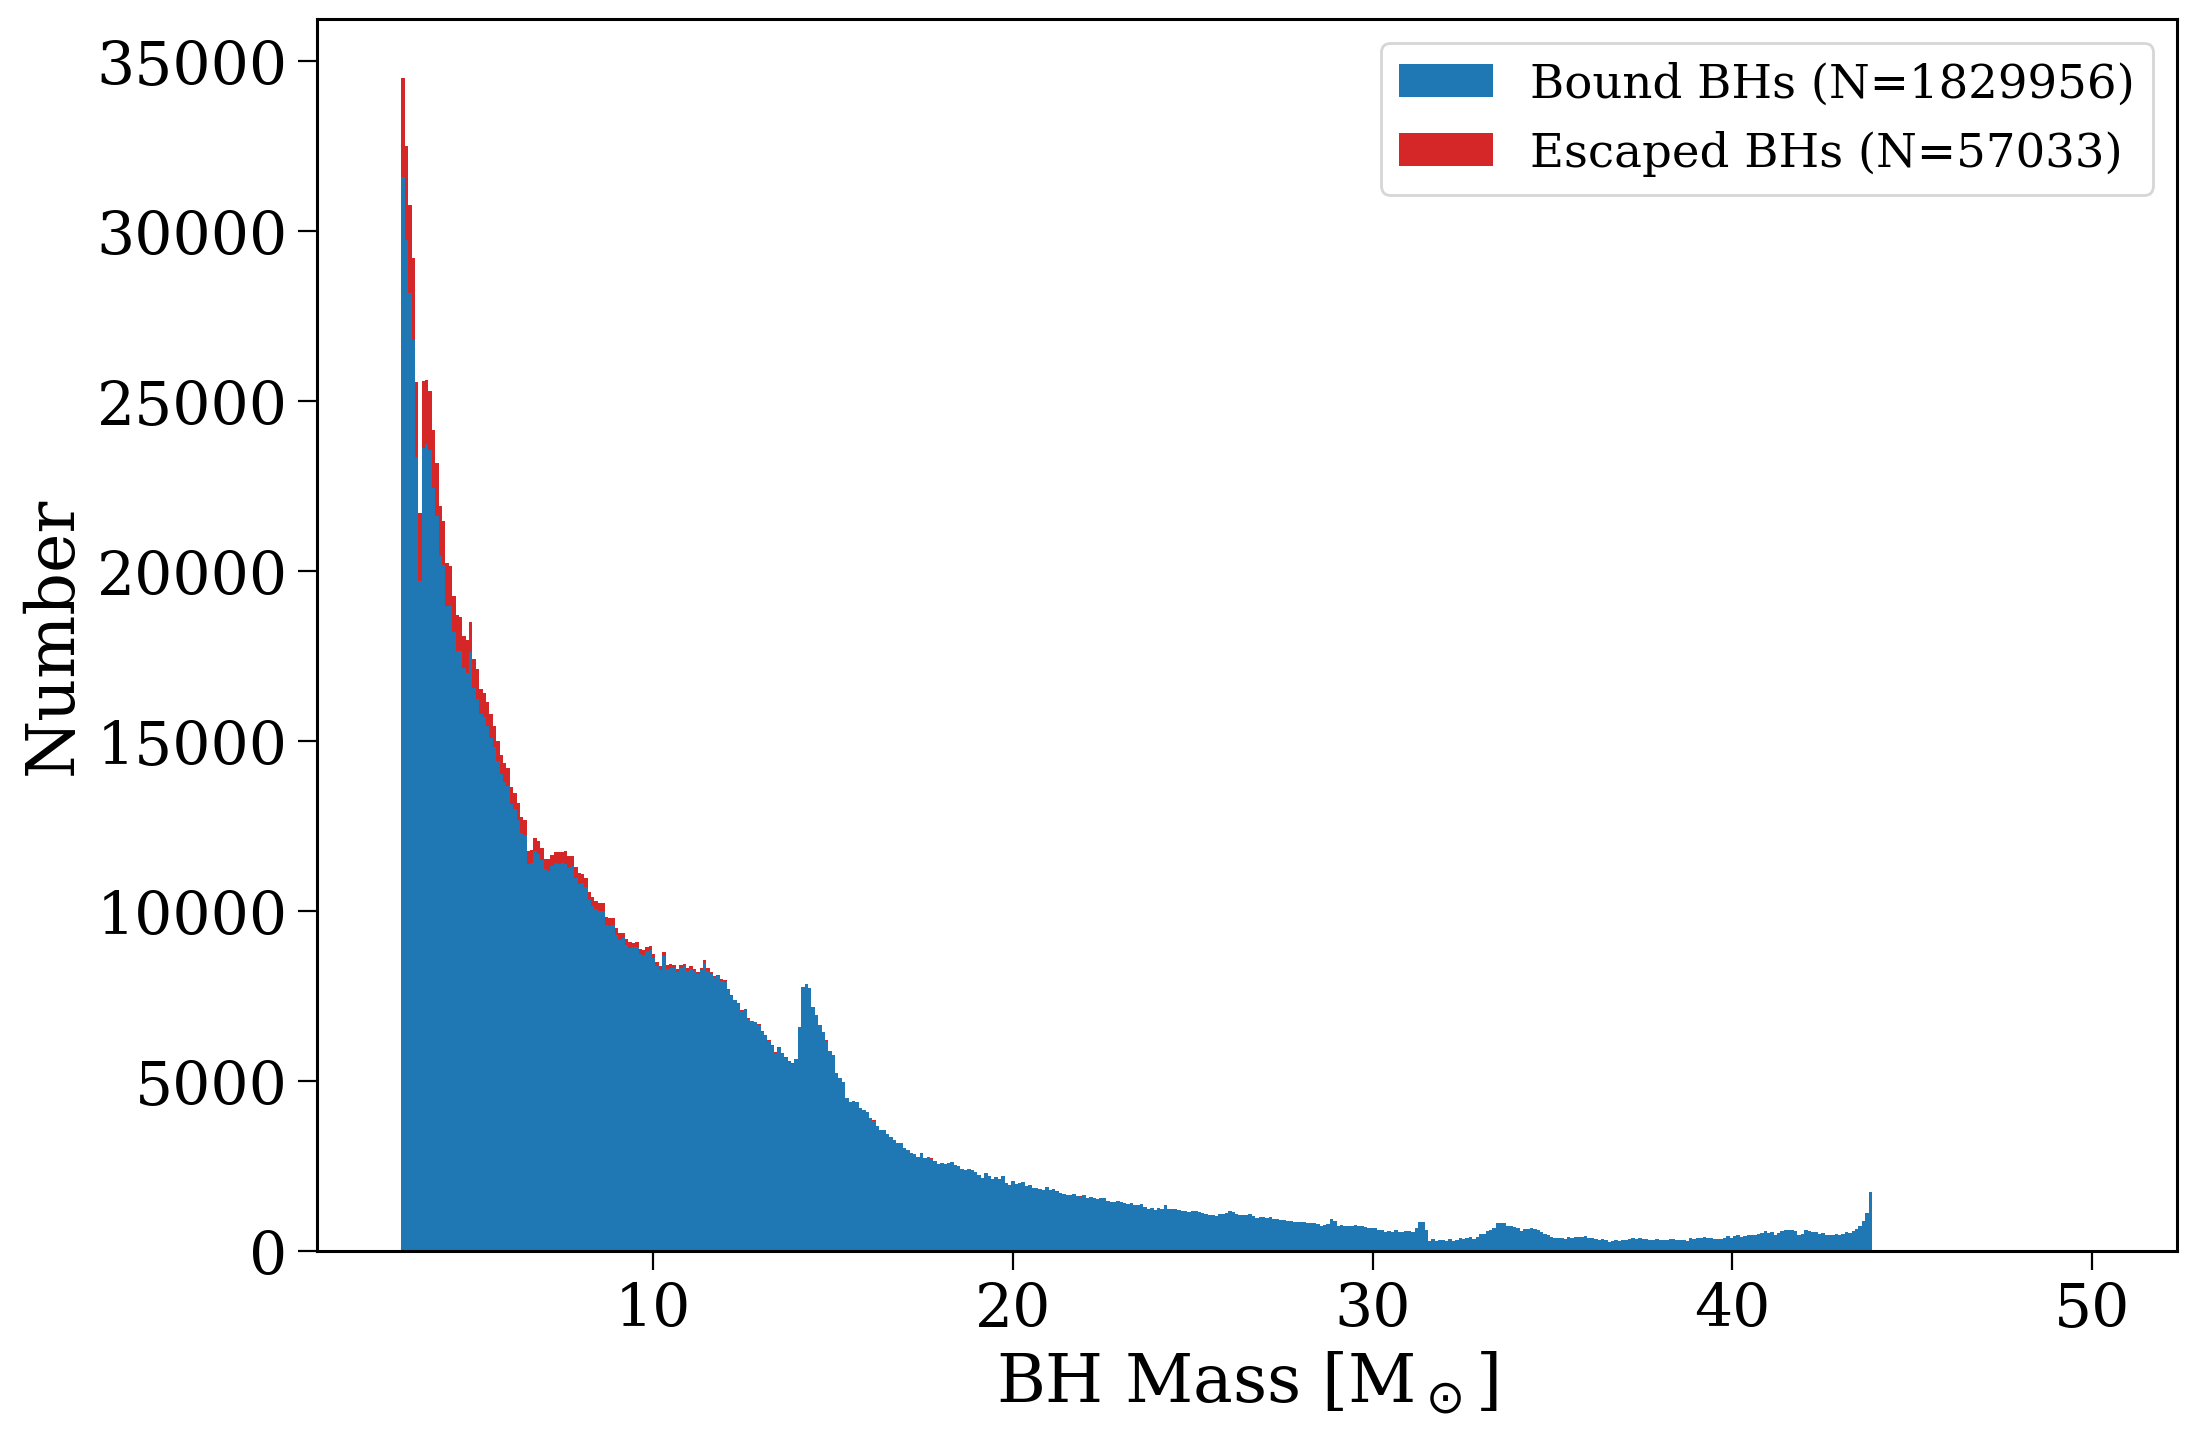

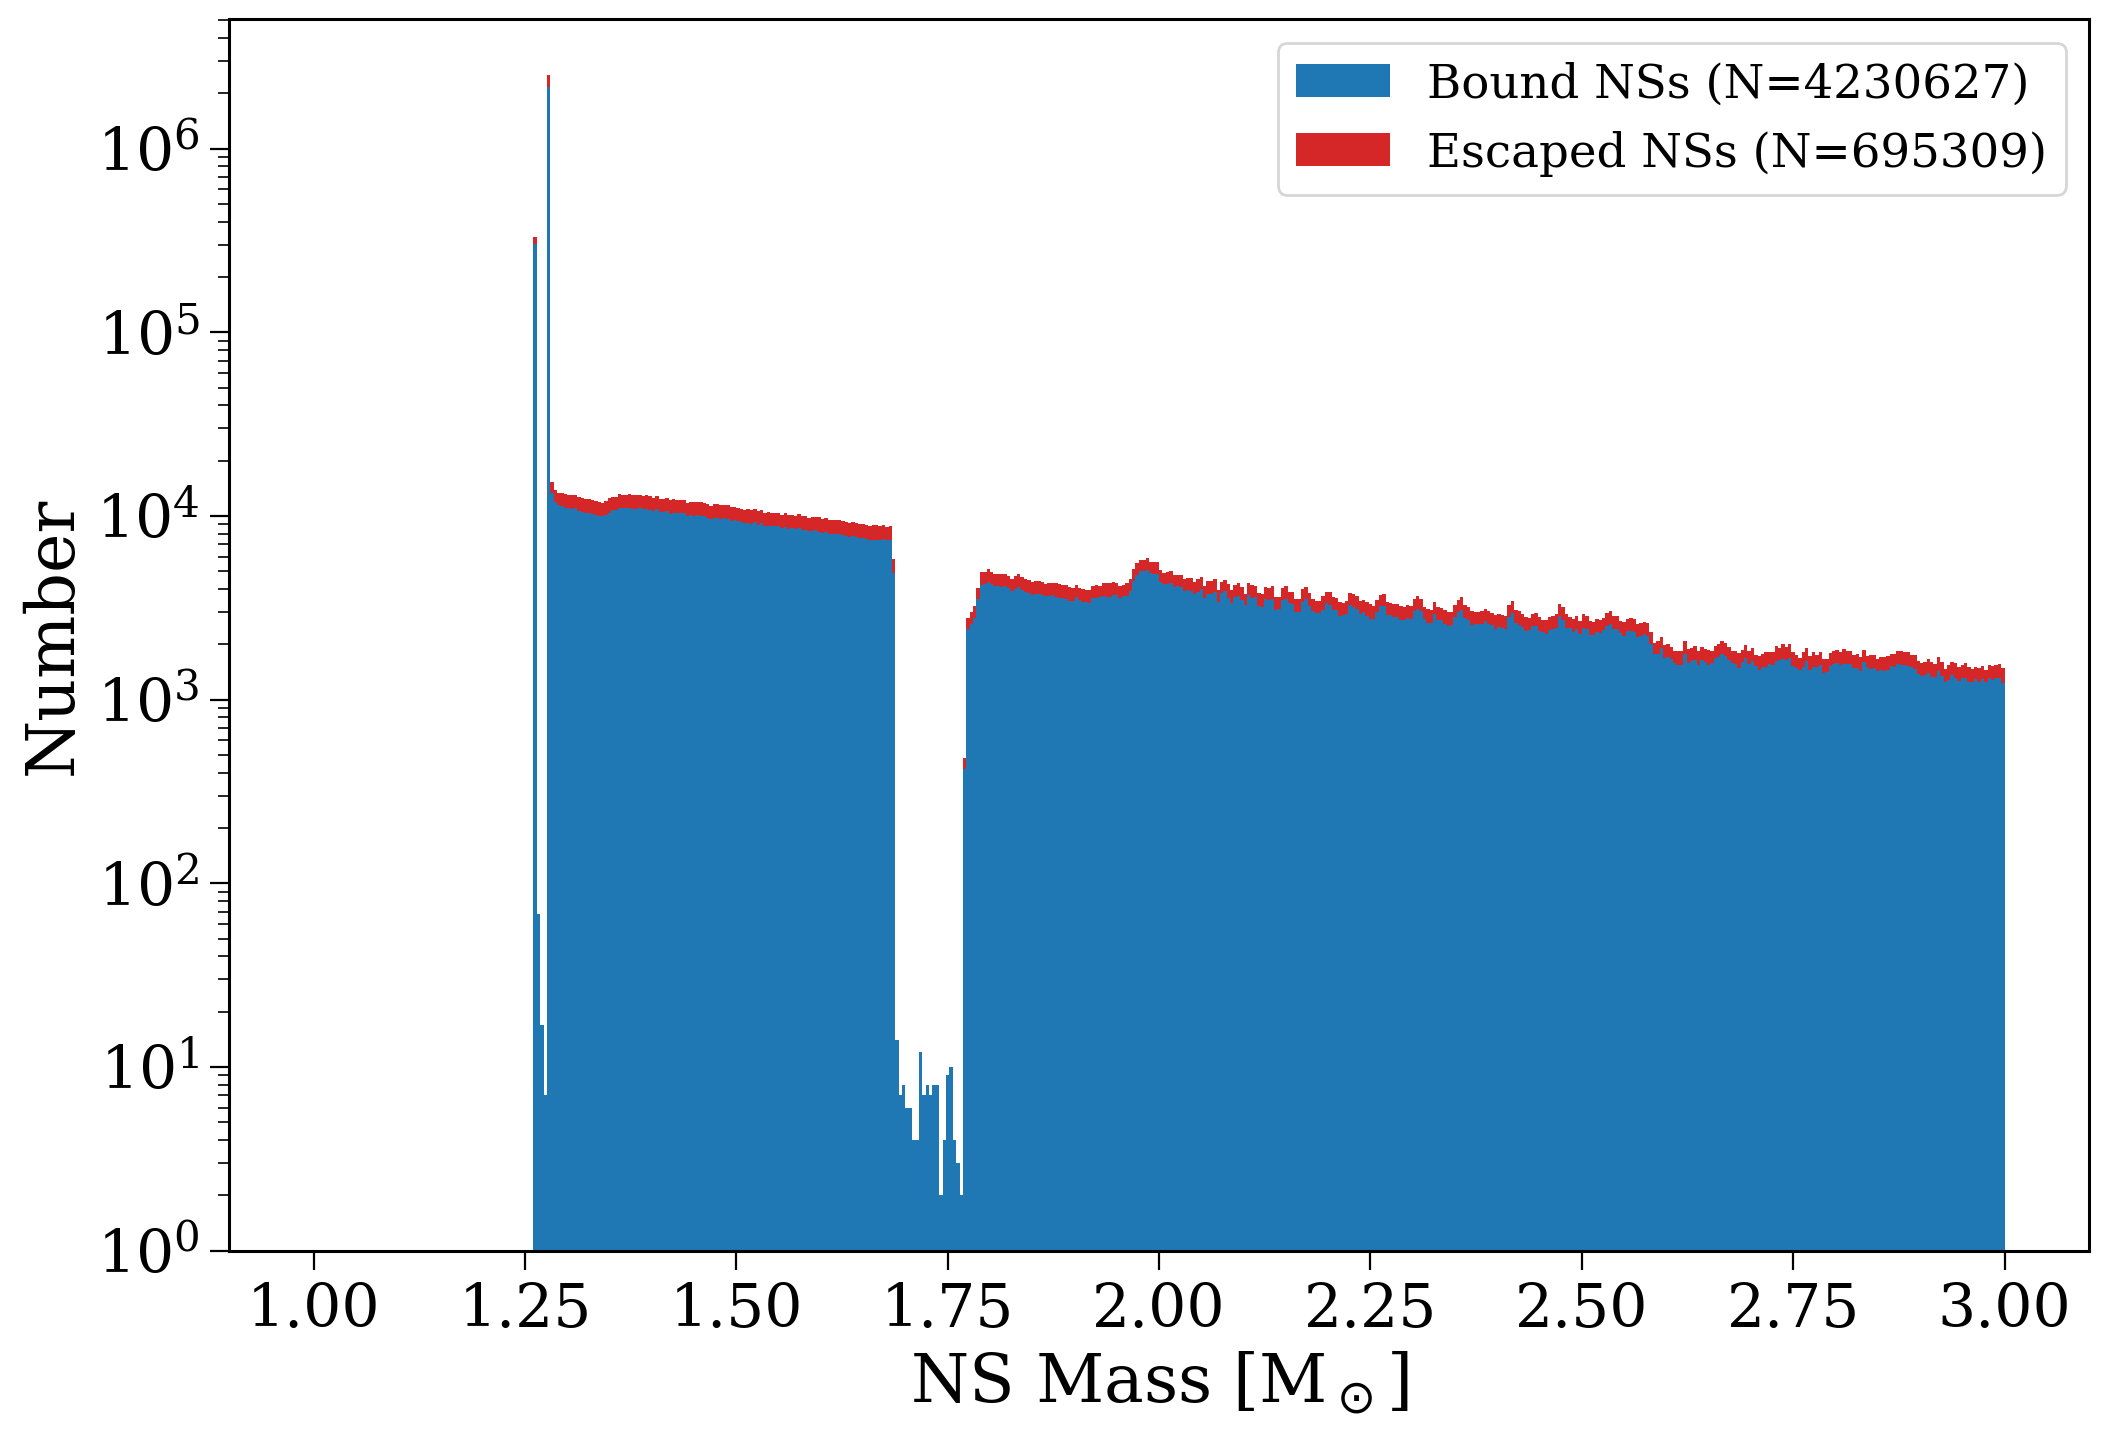

In [51]:
kinematics[pop.label]["escaped"] = {}
for co_type, bins in zip(["CO", "BH", "NS"], [None, np.linspace(3, 50, 500), np.linspace(1, 3, 501)]):

    pos = kinematics[pop.label]["pos"][co_type]
    vel = kinematics[pop.label]["vel"][co_type]

    V = np.linalg.norm(vel.to(u.km/u.s).value, axis=1)

    escaped = V >= np.sqrt(-2 * pop.galactic_potential(pos.T)).to(u.km / u.s).value

    kinematics[pop.label]["escaped"][co_type] = escaped

    if co_type == "CO":
        continue

    fig, ax = plt.subplots()

    stacked_data = [masses[co_type][~escaped], masses[co_type][escaped]]
    ax.hist(
        stacked_data,
        bins=bins,
        color=["tab:blue", "tab:red"],
        label=[f'Bound {co_type}s (N={np.sum(~escaped)})', f'Escaped {co_type}s (N={np.sum(escaped)})'],
        stacked=True,
    )

    plt.legend()

    ax.set(
        xlabel=f'{co_type} Mass [M$_\odot$]',
        ylabel='Number',
        yscale='log' if co_type == "NS" else 'linear',
    )

    plt.show()

## Stats

In [52]:
average_escaped_BH_mass = np.mean(masses["BH"][kinematics[pop.label]["escaped"]["BH"]])
average_bound_BH_mass = np.mean(masses["BH"][~kinematics[pop.label]["escaped"]["BH"]])

In [53]:
avg_bound_BH_close_to_disc = np.mean(masses["BH"][(
    ~kinematics[pop.label]["escaped"]["BH"] &
    (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) < 1)
)])

avg_bound_BH_far_from_disc = np.mean(masses["BH"][(
    ~kinematics[pop.label]["escaped"]["BH"] &
    (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) >= 1)
)])

In [54]:
print("Average BH masses:")
print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")

Average BH masses:
  Escaped: 5.2 Msun
  Bound:   10.8 Msun
    Close to disc (<1 kpc):  12.1 Msun
    Far from disc (>=1 kpc): 7.9 Msun


In [55]:
# convert the above print statements to a LaTeX table
print("\nLaTeX table:")
print(r"\begin{tabular}{l c}")
print(r"  \hline")
print(r"  Population & Average BH Mass (M$_\odot$) \\")
print(r"  \hline")
print(f"  Escaped & {average_escaped_BH_mass:.1f} \\")
print(f"  Bound & {average_bound_BH_mass:.1f} \\")
print(f"  \quad Close to disc (<1 kpc) & {avg_bound_BH_close_to_disc:.1f} \\")
print(f"  \quad Far from disc (>=1 kpc) & {avg_bound_BH_far_from_disc:.1f} \\")
print(r"  \hline")
print(r"\end{tabular}")


LaTeX table:
\begin{tabular}{l c}
  \hline
  Population & Average BH Mass (M$_\odot$) \\
  \hline
  Escaped & 5.2 \
  Bound & 10.8 \
  \quad Close to disc (<1 kpc) & 12.1 \
  \quad Far from disc (>=1 kpc) & 7.9 \
  \hline
\end{tabular}


# Progenitors

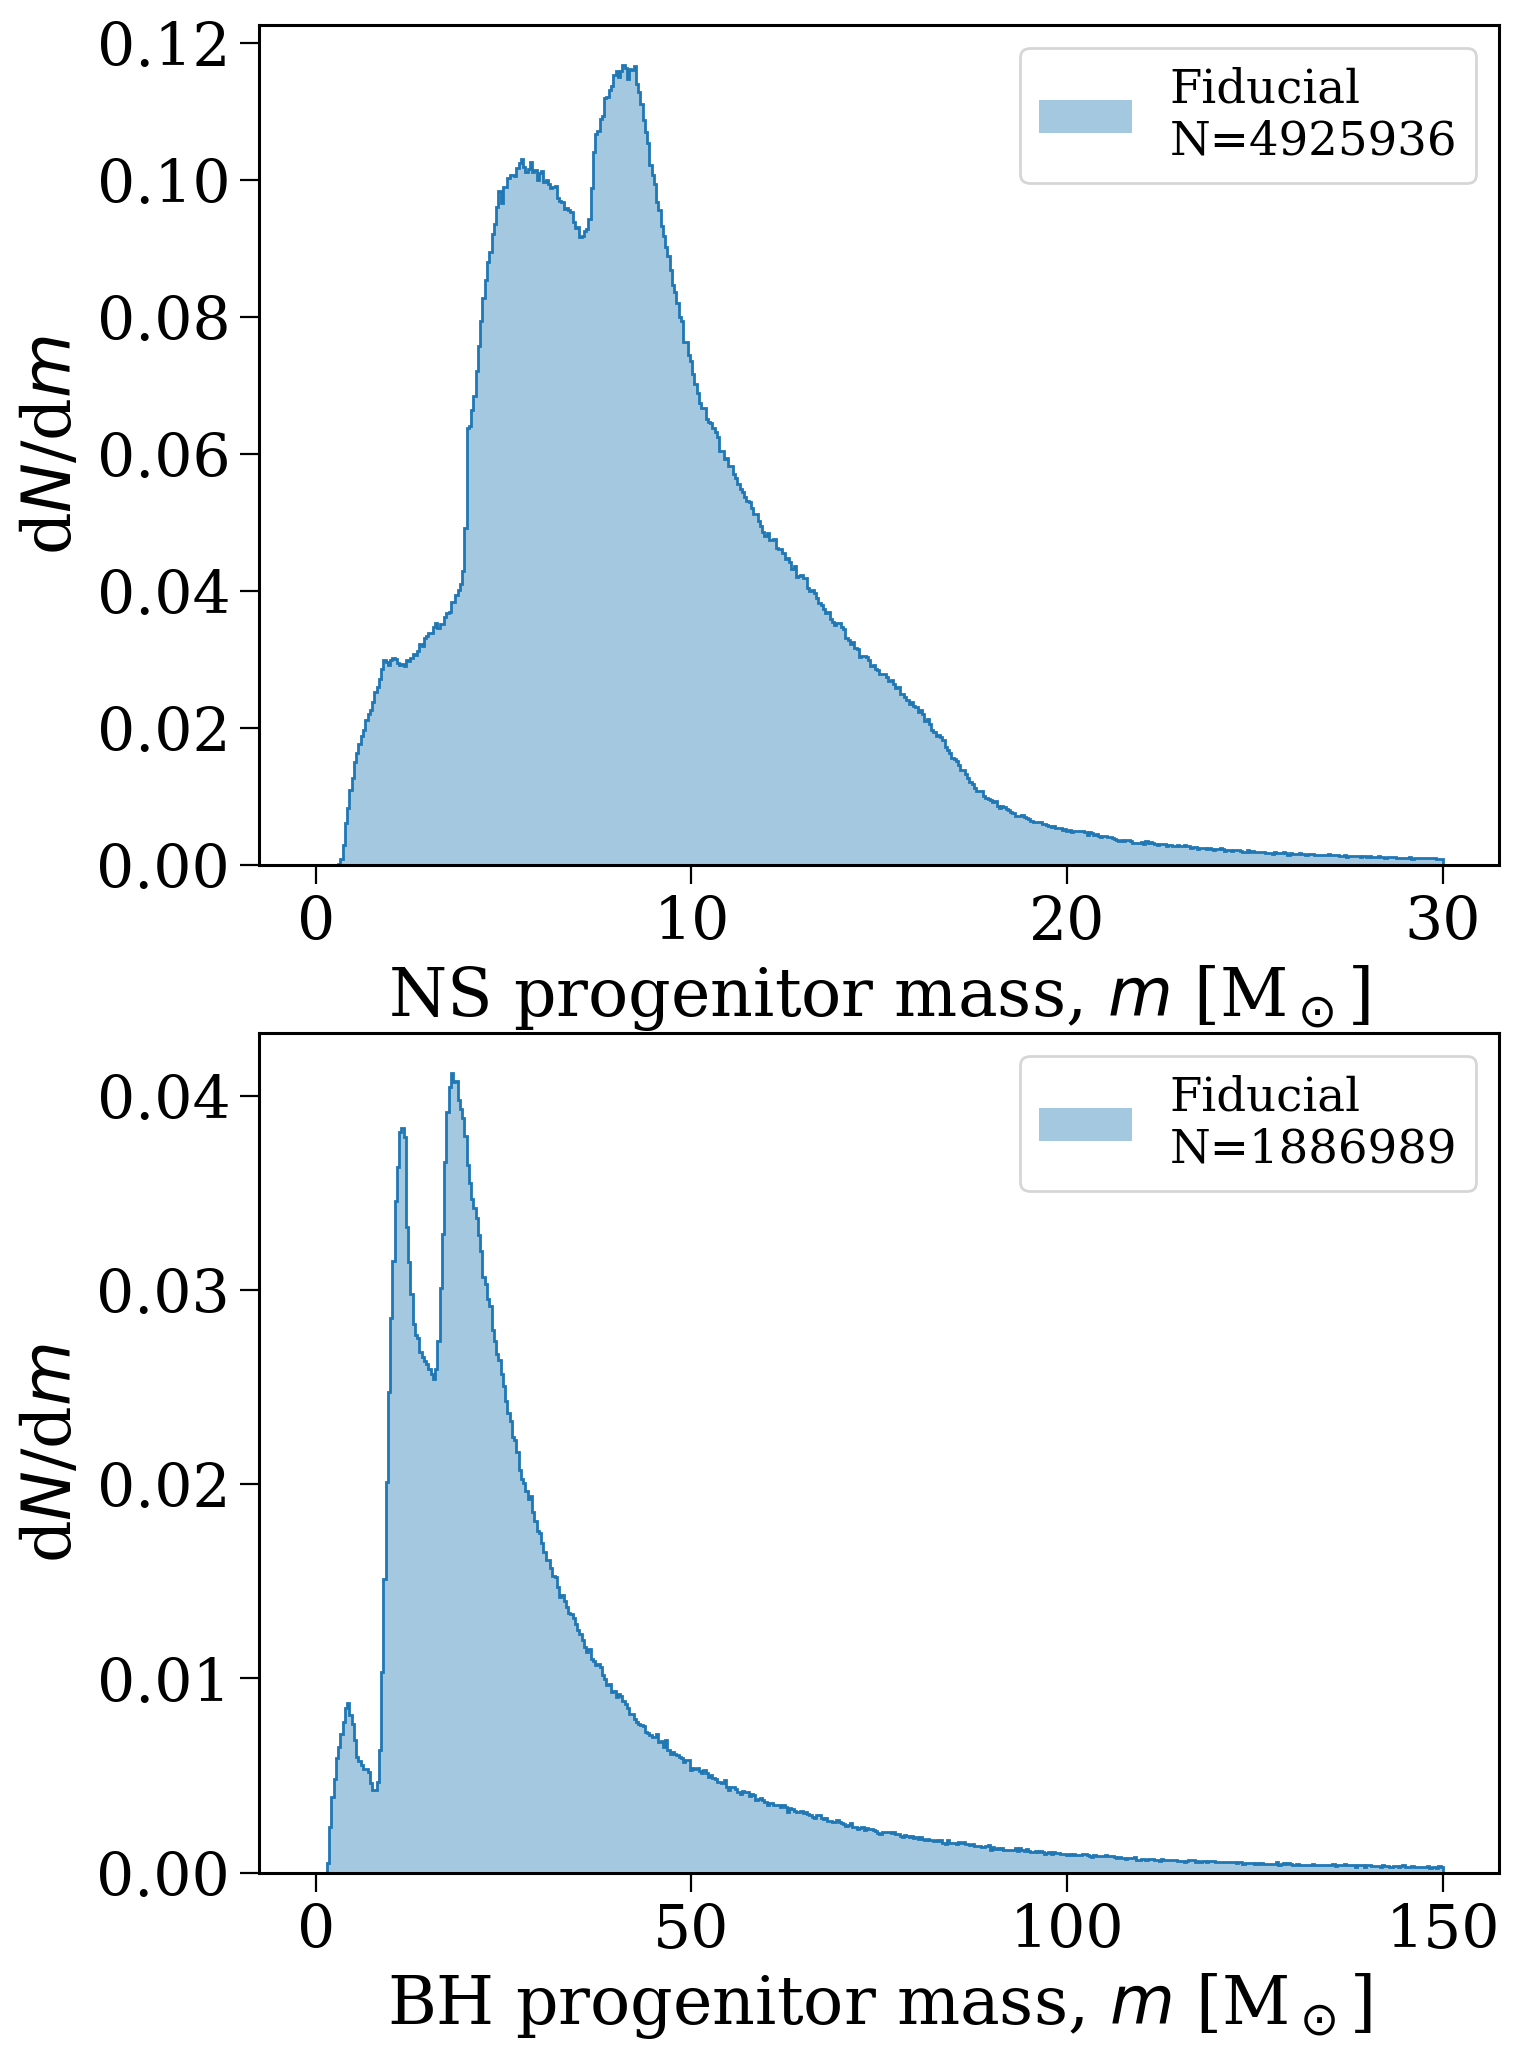

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 501), np.linspace(0, 150, 501)]):
    plotting.compare_table_quantity(
        pops=[pop],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor mass, $m$ [M$_\odot$]",
        ylabel=f"d$N$/d$m$",
        density=True,
        ax=ax,
        fig=fig,
        show=False,
        lw=1
    )

plt.savefig("../plots/progenitor_masses.pdf", format="pdf", bbox_inches='tight')
plt.show()

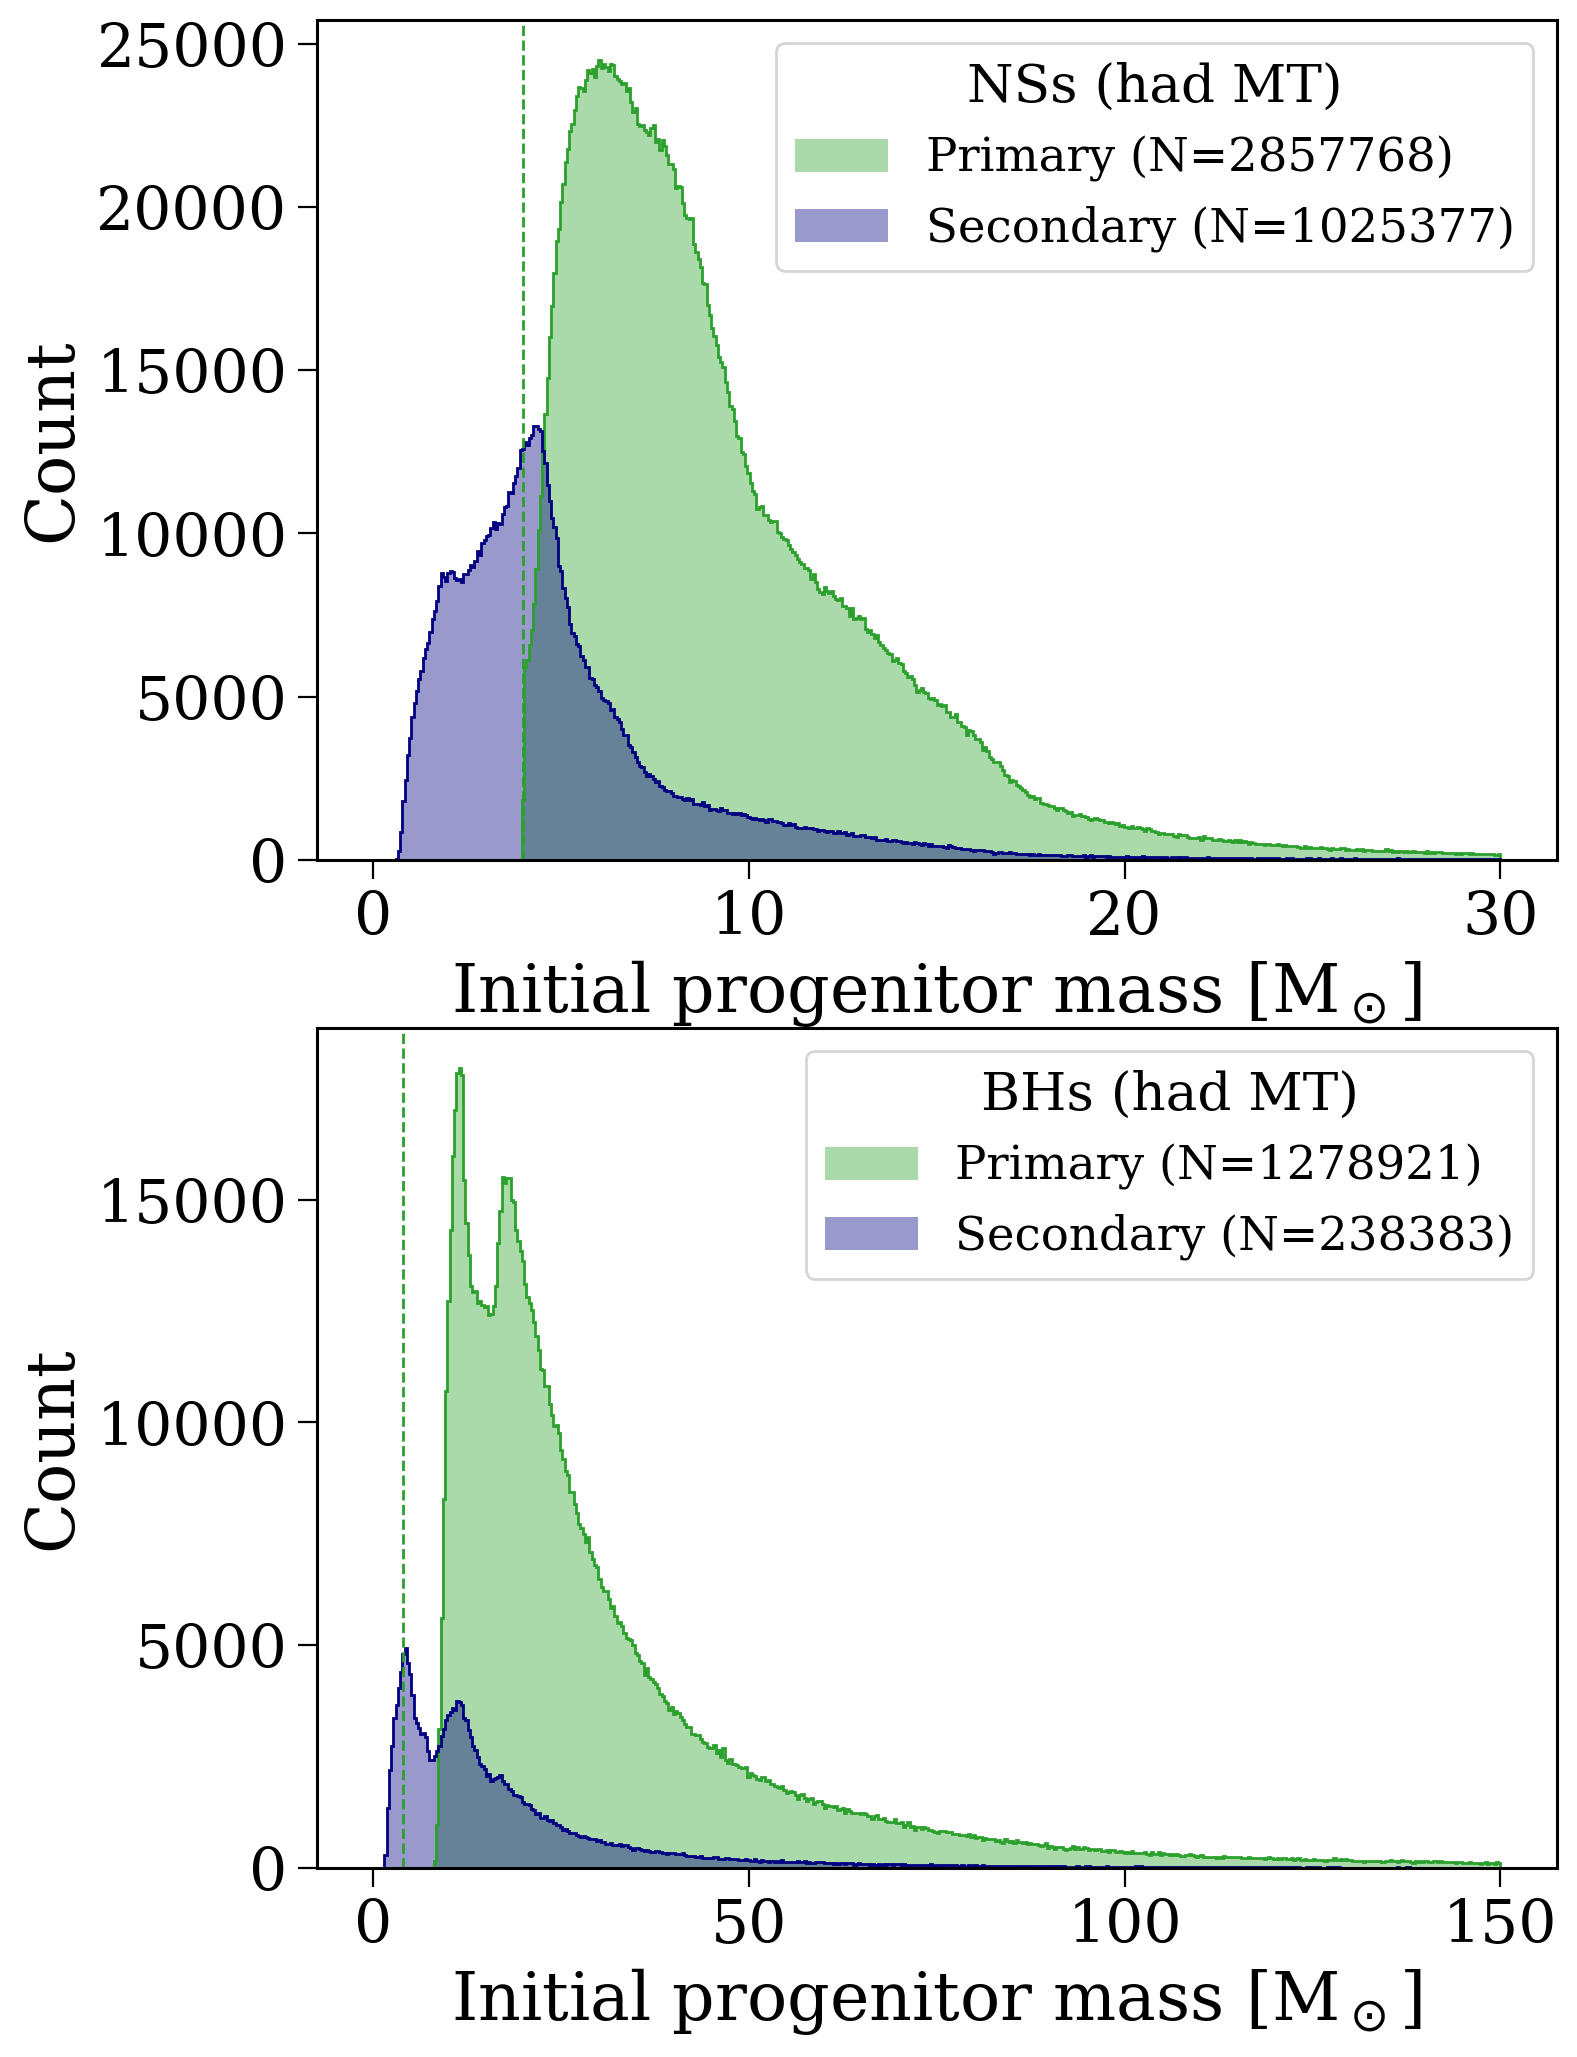

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 501), np.linspace(0, 150, 501)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            # & ~(pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=1, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")
        
    ax.axvline(4, color="tab:green", ls='--', lw=1)

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had MT)")

plt.savefig("../plots/progenitor_masses_mt.pdf", format="pdf", bbox_inches='tight')
plt.show()

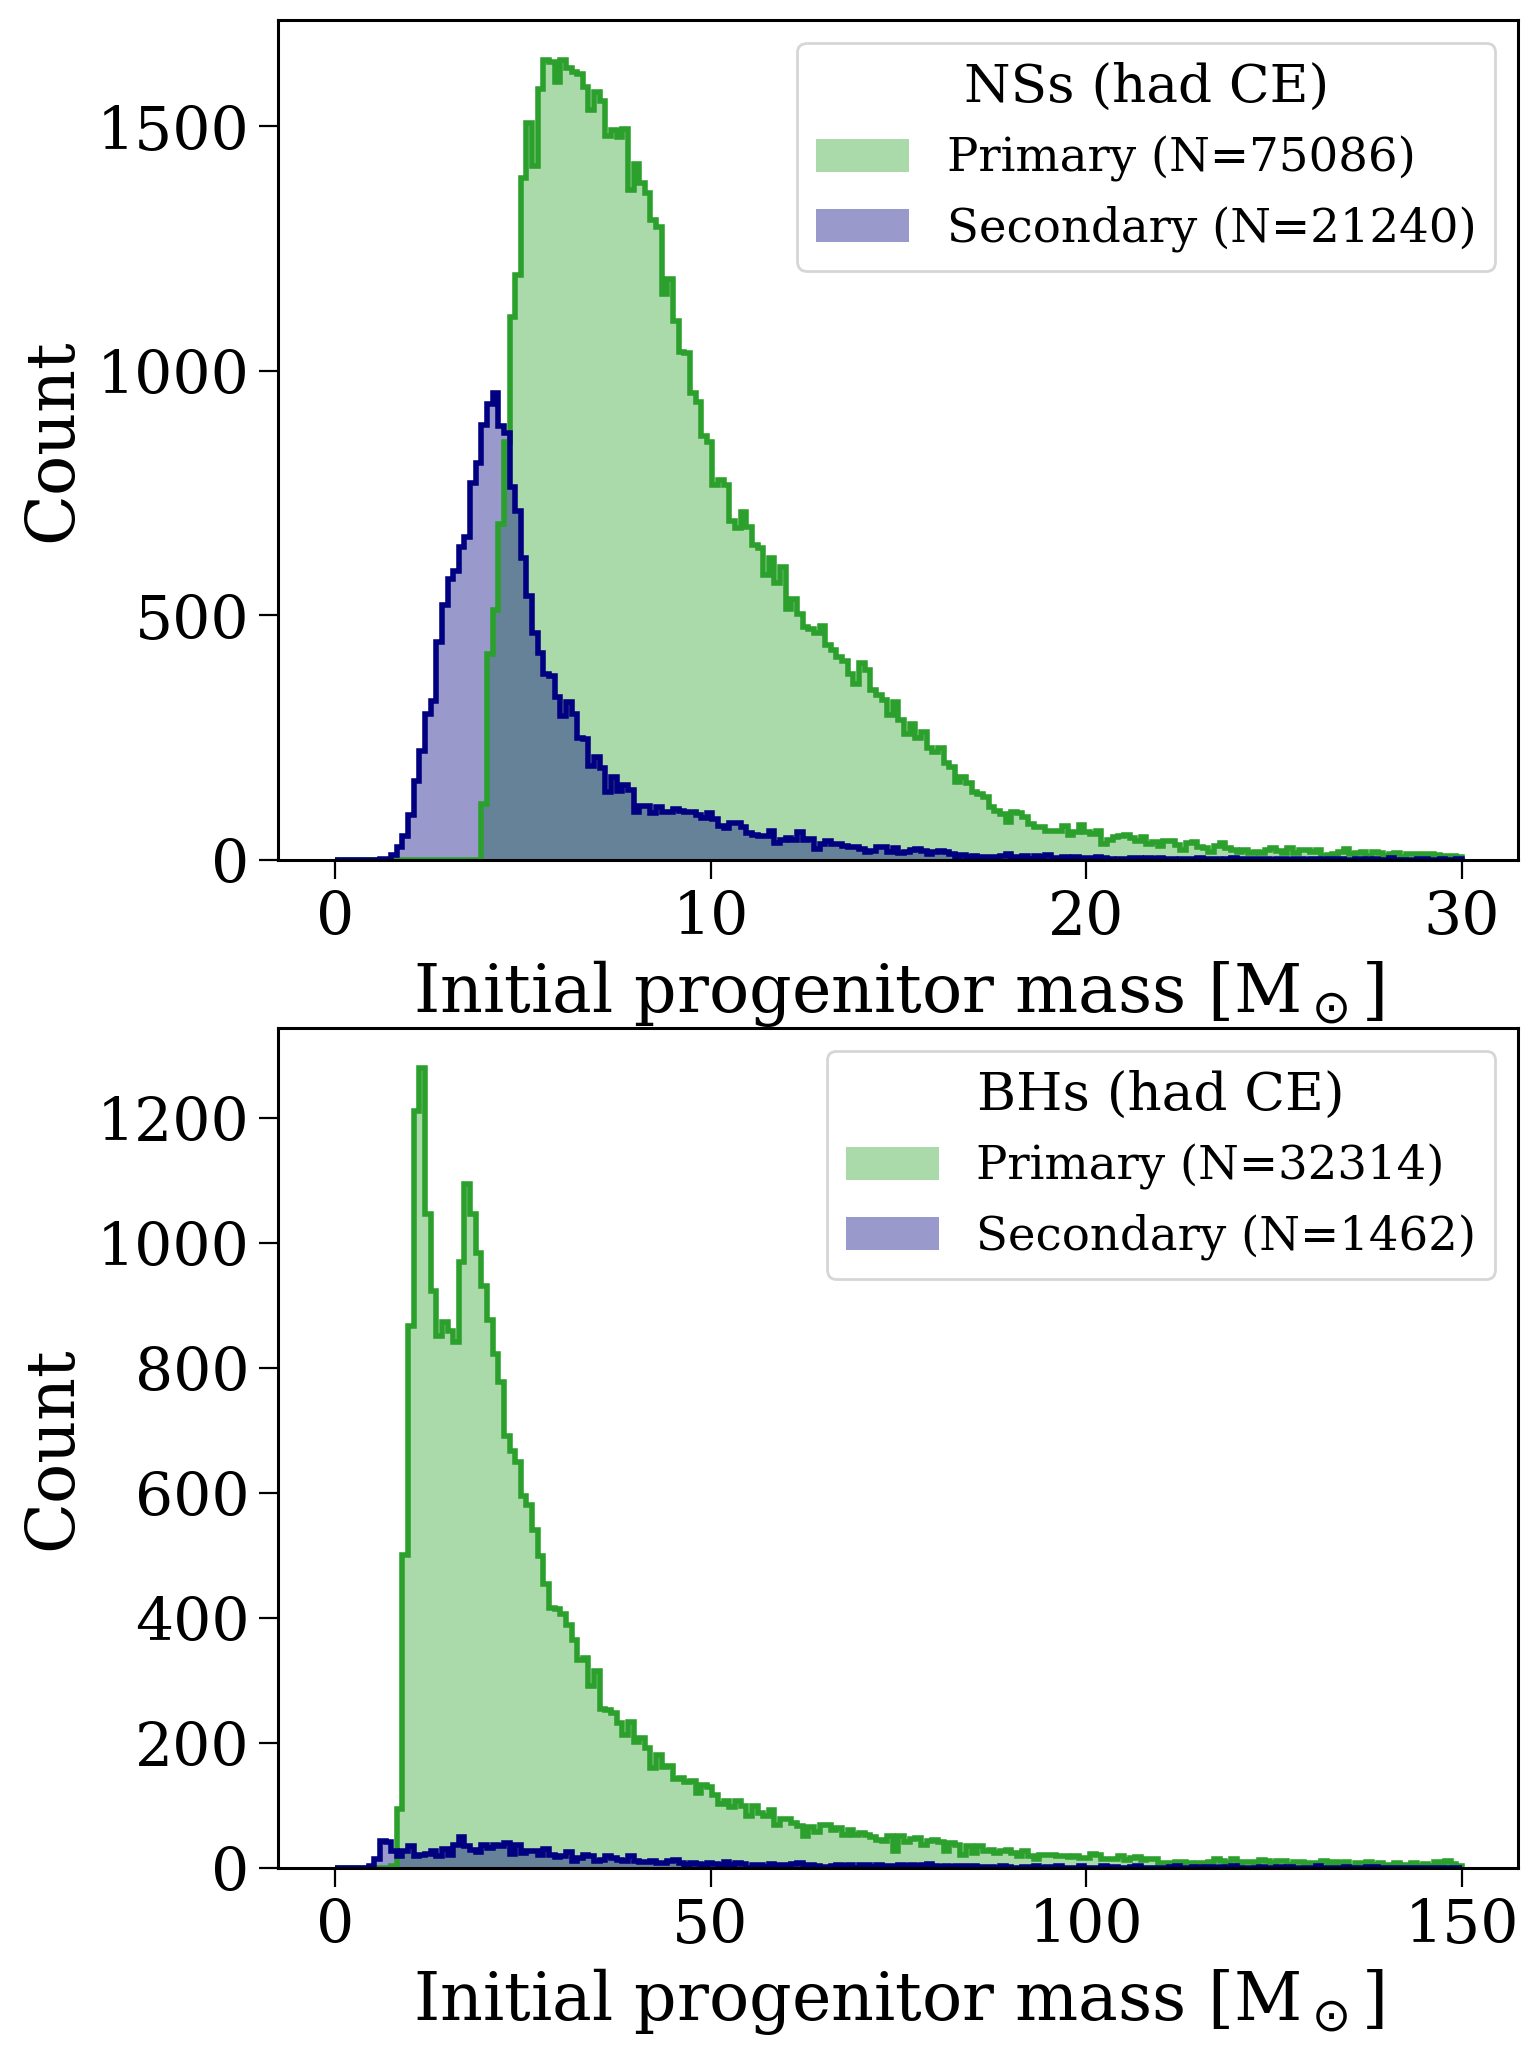

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            & (pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=2, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had CE)")

plt.savefig("../plots/progenitor_masses_ce.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Nearest COs

In [74]:
init_m_tot = pop.initC["mass_1"] + pop.initC["mass_2"]

In [60]:
def get_solar_neighbourhood_density(pos, masses, major_axis=8*u.kpc, minor_axis=0.2*u.kpc):
    R = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
    z = pos[:, 2]
    torus_mask = ((R - major_axis)**2 + z**2) <= minor_axis**2

    n_in_torus = torus_mask.sum()

    # mass contained in torus
    mass_in_torus = masses[torus_mask].sum() * u.Msun

    # density of COs in torus in pc^-3
    torus_volume = 2 * np.pi**2 * major_axis * minor_axis**2
    co_density = n_in_torus / torus_volume.to(u.pc**3)
    co_mass_density = mass_in_torus / torus_volume.to(u.pc**3)

    return co_density, co_mass_density

In [61]:
for co_type in ["CO", "NS", "BH"]:
    co_density, co_mass_density = get_solar_neighbourhood_density(
        kinematics["Fiducial"]["pos"][co_type],
        masses[co_type]
    )
    co_density *= scale_up
    co_mass_density *= scale_up
    nearest_distance = (3 / (4 * np.pi * co_density))**(1/3)
    print(f"{co_type} density: {co_density:.1e}, mass density: {co_mass_density:.1e}, nearest neighbour distance: {nearest_distance:.1f}")

CO density: 4.0e-04 1 / pc3, mass density: 2.5e-03 solMass / pc3, nearest neighbour distance: 8.4 pc
NS density: 2.3e-04 1 / pc3, mass density: 3.4e-04 solMass / pc3, nearest neighbour distance: 10.1 pc
BH density: 1.7e-04 1 / pc3, mass density: 2.2e-03 solMass / pc3, nearest neighbour distance: 11.3 pc


In [191]:
135 / n_ns

np.float64(2.7405958989316956e-05)

In [7]:
underworld_binaries = helpers.get_underworld_binaries([pop], verbose=True)["Fiducial"]

Fiducial Underworld Binaries (scale up by 97x):
  BH-BH:     34160  	3.3e+06 (scaled)	19.5 Msun 	0.0 Msun 	 8.7e+04 Rsun
  BH-NS:     1075  	1.0e+05 (scaled)	12.6 Msun 	2.1 Msun 	 1.1e+03 Rsun
  BH-WD:     5570  	5.4e+05 (scaled)	10.0 Msun 	0.0 Msun 	 5.6e+04 Rsun
  BH-Star:   59  	5.7e+03 (scaled)	5.2 Msun 	0.0 Msun 	 5.3e+03 Rsun

  NS-NS:     135  	1.3e+04 (scaled)	0.0 Msun 	1.9 Msun 	 1.0e+02 Rsun
  NS-WD:     3715  	3.6e+05 (scaled)	0.0 Msun 	1.8 Msun 	 1.4e+04 Rsun
  NS-Star:   722  	7.0e+04 (scaled)	0.0 Msun 	2.0 Msun 	 2.6e+02 Rsun



In [46]:
underworld_binaries = helpers.get_underworld_binaries([pop], verbose=True)["Fiducial"]

Fiducial Underworld Binaries (scale up by 97x):
  BH-BH:     33870  	3.3e+06 (scaled)	19.6 Msun 	0.0 Msun 	 8.8e+04 Rsun
  BH-NS:     1066  	1.0e+05 (scaled)	12.5 Msun 	2.1 Msun 	 1.0e+03 Rsun
  BH-WD:     4039  	3.9e+05 (scaled)	11.6 Msun 	0.0 Msun 	 7.7e+04 Rsun
  BH-Star:   36  	3.5e+03 (scaled)	6.2 Msun 	0.0 Msun 	 8.7e+03 Rsun

  NS-NS:     179  	1.7e+04 (scaled)	0.0 Msun 	1.8 Msun 	 8.7e+01 Rsun
  NS-WD:     4291  	4.2e+05 (scaled)	0.0 Msun 	1.6 Msun 	 1.2e+04 Rsun
  NS-Star:   702  	6.8e+04 (scaled)	0.0 Msun 	1.7 Msun 	 2.8e+02 Rsun



In [47]:
underworld_binary_pos = pop.final_pos[:len(pop)][np.isin(pop.bin_nums, pd.concat(underworld_binaries.values())["bin_num"])]
underworld_binary_vel = pop.final_pos[:len(pop)][np.isin(pop.bin_nums, pd.concat(underworld_binaries.values())["bin_num"])]

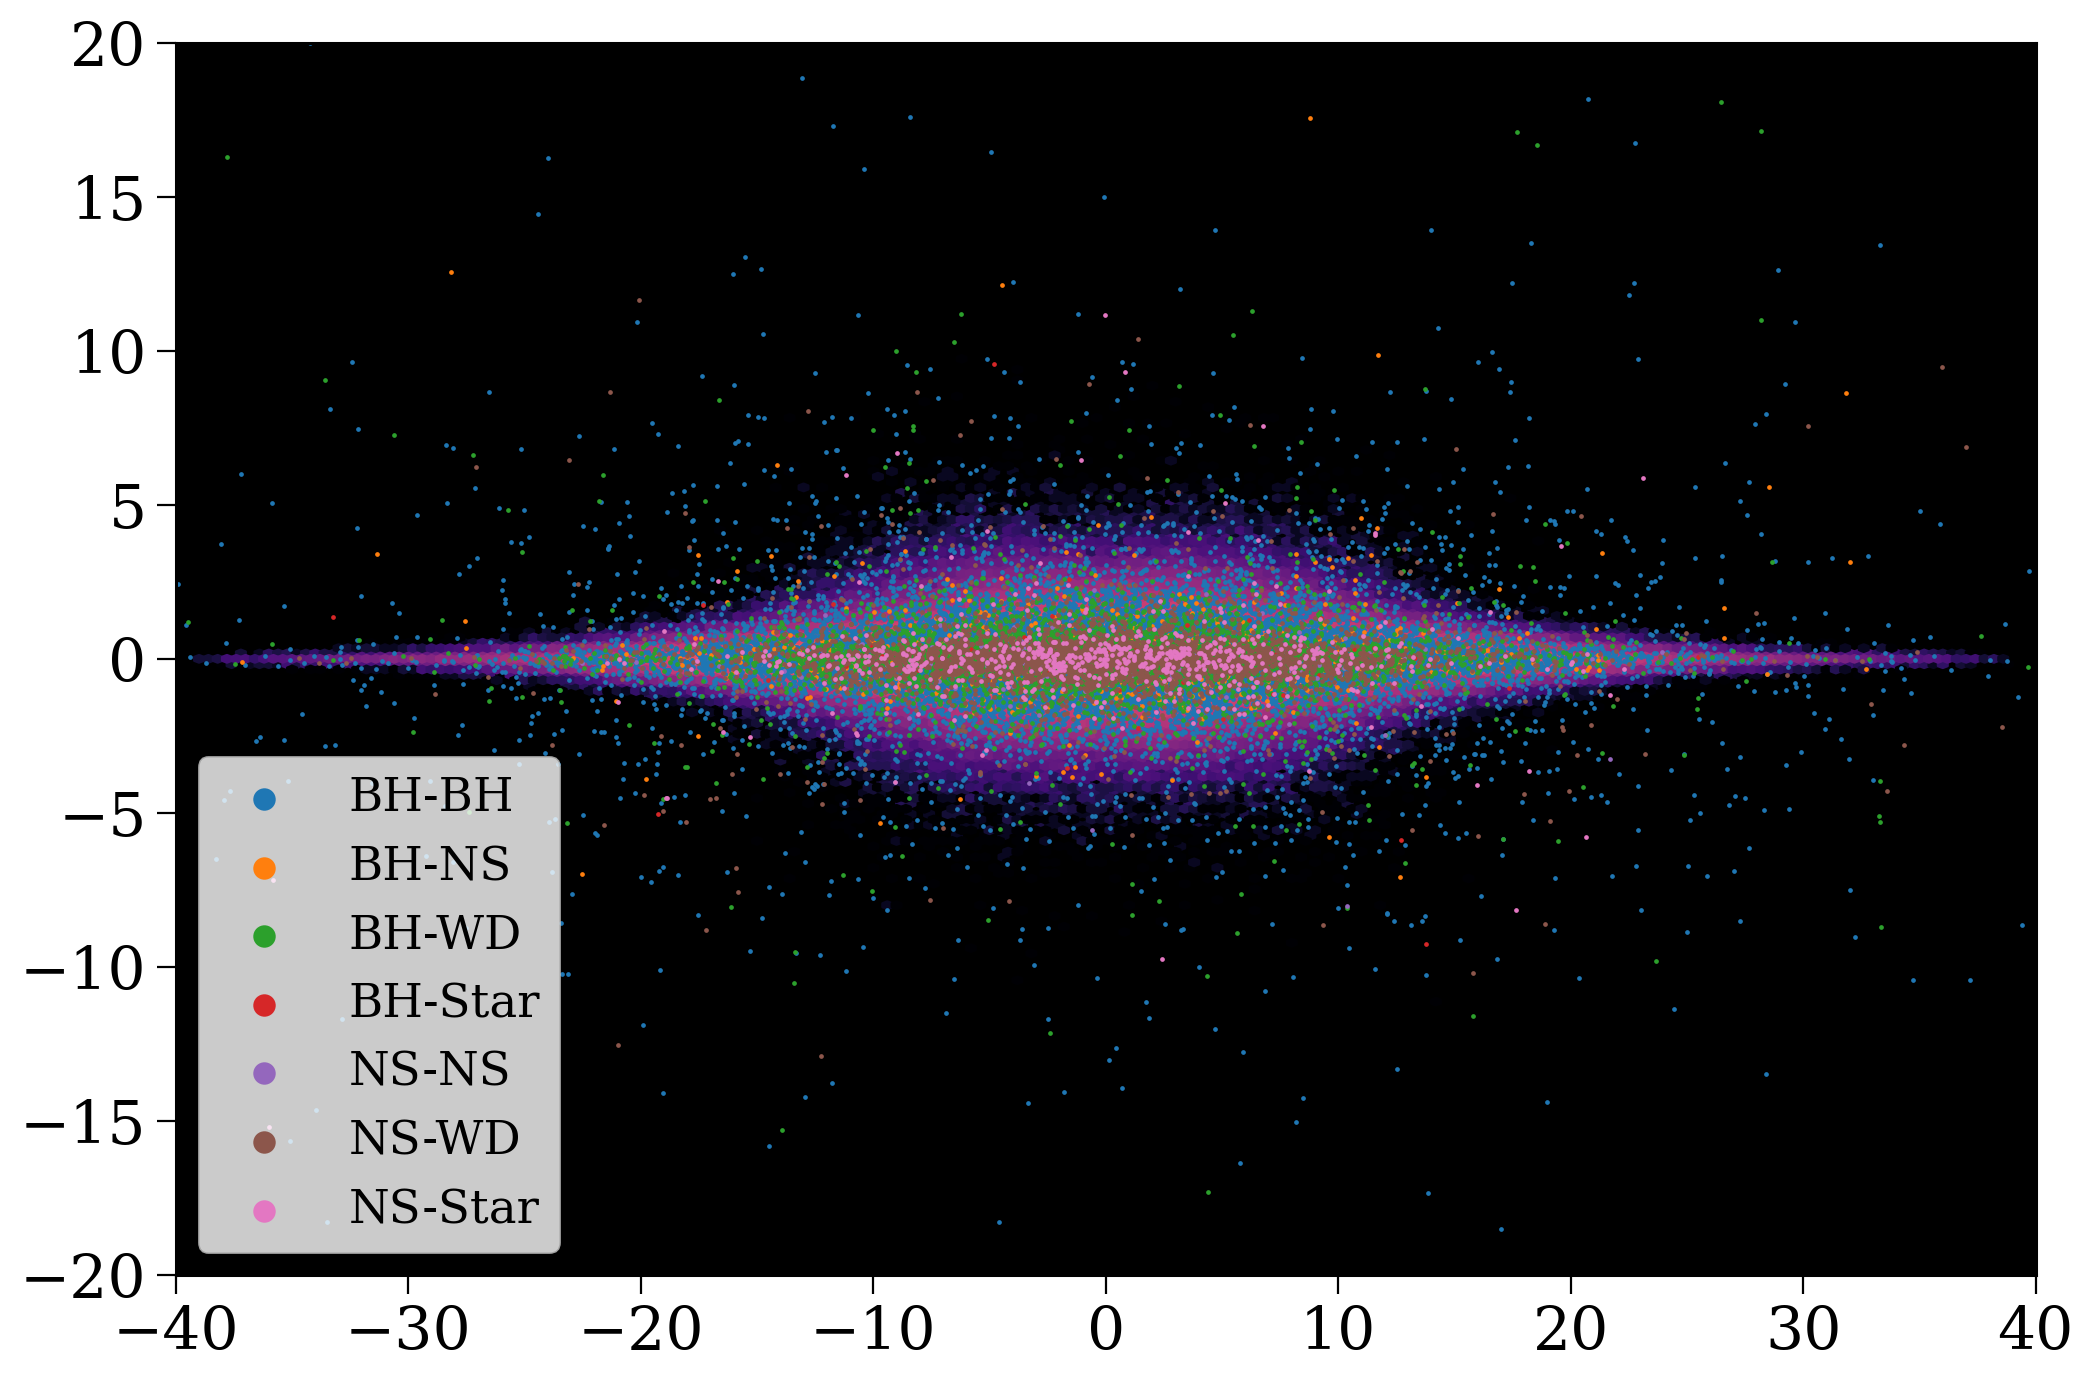

In [133]:
fig, ax = plt.subplots()
plt.hexbin(stars.x, stars.z, gridsize=200, extent=[-40, 40, -20, 20], cmap='magma', bins='log', mincnt=1)
cursor = 0
c = 0
for label, table in underworld_binaries.items():
    plt.scatter(underworld_binary_pos[cursor:cursor+len(table), 0], underworld_binary_pos[cursor:cursor+len(table), 2], s=.5, label=label, c=f"C{c}")
    cursor += len(table)
    c+= 1
plt.xlim(-40, 40)
plt.ylim(-20, 20)
plt.legend(markerscale=10)
ax.set_fc('black')
plt.show()

In [9]:
bhbh_mergers = pop.bpp[(pop.bpp["evol_type"] == 3) & (
    (pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 14)
)]
nsns_mergers = pop.bpp[(pop.bpp["evol_type"] == 3) & (
    (pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 13)
)]
nsbh_mergers = pop.bpp[(pop.bpp["evol_type"] == 3) & (
    ((pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 14)) |
    ((pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 13))
)]
gw_mergers = pd.concat([bhbh_mergers, nsns_mergers, nsbh_mergers])
print(f"Estimated number of mergers in a MW-mass galaxy (minimum here would be {scale_up:.0f}):")
print(f"  BH-BH mergers: {len(bhbh_mergers) * scale_up:.0f}")
print(f"  NS-NS mergers: {len(nsns_mergers) * scale_up:.0f}")
print(f"  NS-BH mergers: {len(nsbh_mergers) * scale_up:.0f}")

Estimated number of mergers in a MW-mass galaxy (minimum here would be 97):
  BH-BH mergers: 205545
  NS-NS mergers: 2332
  NS-BH mergers: 104862


In [48]:
bhbh_mergers = pop.bpp[(pop.bpp["evol_type"] == 3) & (
    (pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 14)
)]
nsns_mergers = pop.bpp[(pop.bpp["evol_type"] == 3) & (
    (pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 13)
)]
nsbh_mergers = pop.bpp[(pop.bpp["evol_type"] == 3) & (
    ((pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 14)) |
    ((pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 13))
)]
gw_mergers = pd.concat([bhbh_mergers, nsns_mergers, nsbh_mergers])
print(f"Estimated number of mergers in a MW-mass galaxy (minimum here would be {scale_up:.0f}):")
print(f"  BH-BH mergers: {len(bhbh_mergers) * scale_up:.0f}")
print(f"  NS-NS mergers: {len(nsns_mergers) * scale_up:.0f}")
print(f"  NS-BH mergers: {len(nsbh_mergers) * scale_up:.0f}")

Estimated number of mergers in a MW-mass galaxy (minimum here would be 97):
  BH-BH mergers: 207877
  NS-NS mergers: 9621
  NS-BH mergers: 119634


In [80]:
pop.max_ev_time - pop.initial_galaxy.tau[np.isin(pop.bin_nums, bhbh_mergers["bin_num"])] + bhbh_mergers["tphys"].values * u.Myr

<Quantity [2.74881613, 1.4296275 , 5.80773296, ..., 6.54733501, 2.42770426,
           2.85348732] Gyr>

In [102]:
np.linspace(0, 12, 13)

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.])

Delay times for 2115 mergers: median=4.45 Gyr, 5th percentile=0.97 Gyr, 95th percentile=10.81 Gyr
Delay times for 24 mergers: median=5.61 Gyr, 5th percentile=1.75 Gyr, 95th percentile=10.98 Gyr
Delay times for 1079 mergers: median=4.68 Gyr, 5th percentile=1.08 Gyr, 95th percentile=10.76 Gyr


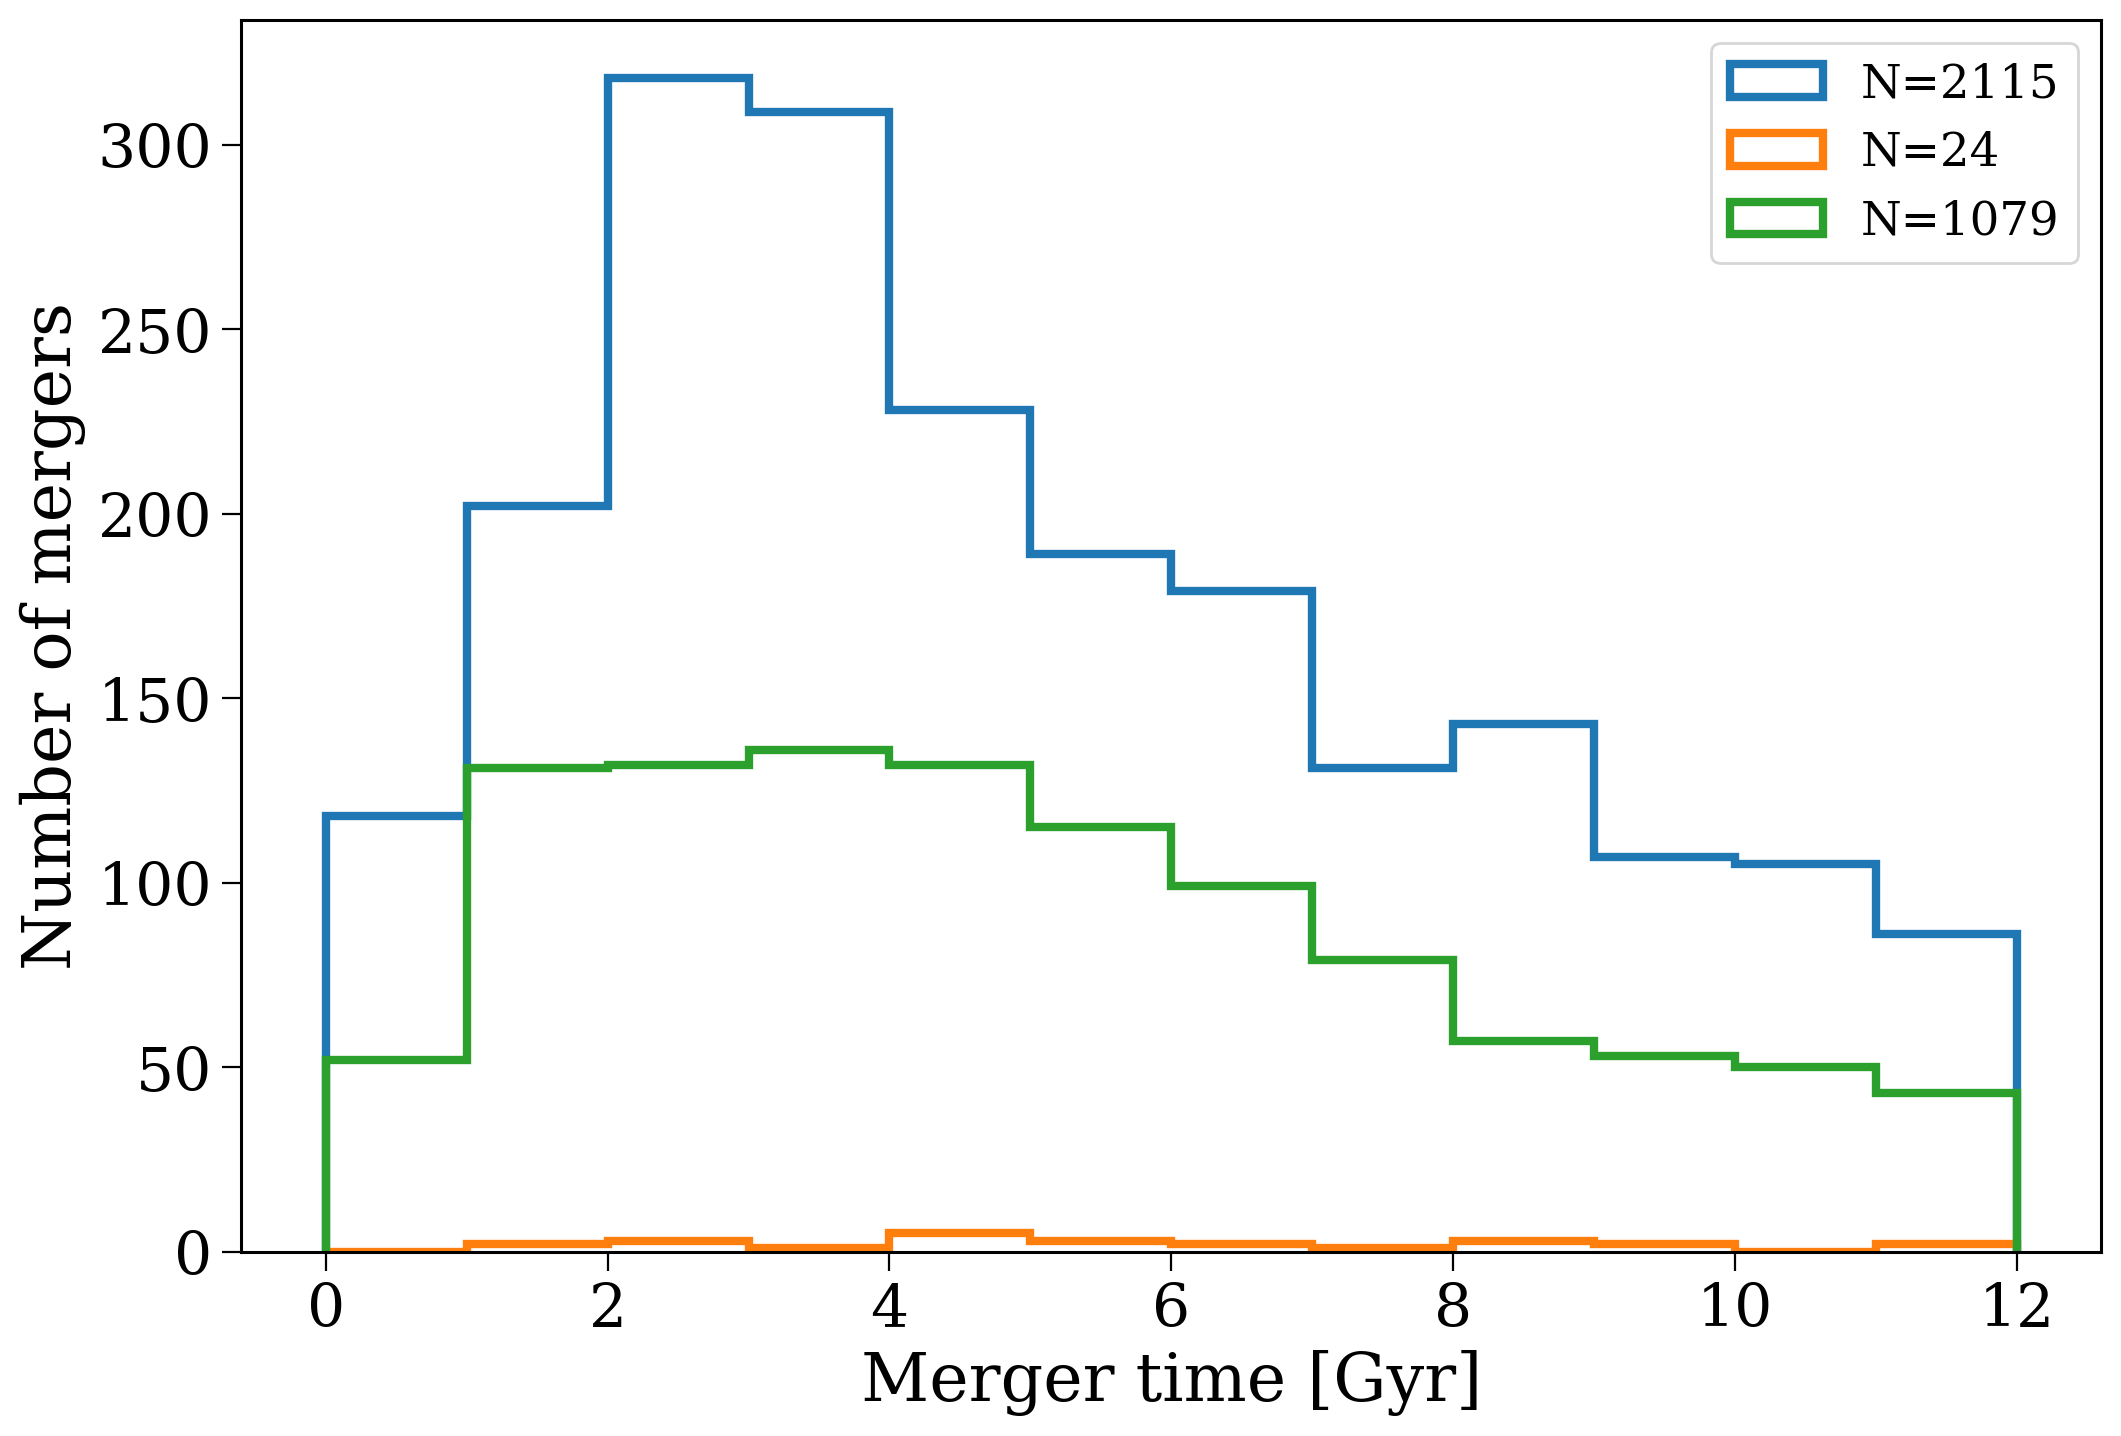

In [167]:
for co_mergers in [bhbh_mergers, nsns_mergers, nsbh_mergers]:
    delay_times = pop.max_ev_time - pop.initial_galaxy.tau[np.isin(pop.bin_nums, co_mergers["bin_num"])] + co_mergers["tphys"].values * u.Myr
    median_delay = np.median(delay_times)
    p5_delay = np.percentile(delay_times, 5)
    p95_delay = np.percentile(delay_times, 95)
    print(f"Delay times for {len(co_mergers)} mergers: median={median_delay:.2f}, 5th percentile={p5_delay:.2f}, 95th percentile={p95_delay:.2f}")
    plt.hist(delay_times.to(u.Gyr).value, bins=np.linspace(0, 12, 13), label=f"N={len(co_mergers)}", histtype='step', lw=3)

# plt.yscale('log')

plt.xlabel("Merger time [Gyr]")
plt.ylabel("Number of mergers")
plt.legend()

plt.show()
# plt.hist(pop.max_ev_time - pop.initial_galaxy.tau[np.isin(pop.bin_nums, bhbh_mergers["bin_num"])] + bhbh_mergers["tphys"].values * u.Myr, bins="fd")

In [10]:
gw_merger_pop = pop[np.isin(pop.bin_nums, gw_mergers["bin_num"])]
gw_merger_pop.bpp_columns = [col.decode('utf-8') if isinstance(col, bytes) else col for col in gw_merger_pop.bpp_columns]
gw_merger_pop.store_entire_orbits = True
# gw_merger_pop.perform_stellar_evolution()
gw_merger_pop.perform_galactic_evolution()

  0%|          | 0/3218 [00:00<?, ?it/s]

/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(
/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(
/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential20

 16%|█▌        | 520/3218 [00:00<00:00, 4735.70it/s]


/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(

/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(


/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotenti

100%|██████████| 3218/3218 [00:04<00:00, 801.64it/s]


In [11]:
# find the location at which mergers occurs (the time in the orbit that corresponds to the merger time in the bpp table where sep == 0)
birth_lookback_times = gw_merger_pop.initial_galaxy.tau[np.isin(gw_merger_pop.bin_nums, gw_mergers["bin_num"])]
gw_merger_locs = np.zeros((len(gw_merger_pop.bin_nums), 3)) * u.kpc
gw_merger_times = np.zeros(len(gw_merger_pop.bin_nums)) * u.Myr
for i, bin_num in enumerate(gw_merger_pop.bin_nums):
    time_birth_to_merger = gw_merger_pop.bpp[(gw_merger_pop.bpp["bin_num"] == bin_num) & (gw_merger_pop.bpp["sep"] == 0.0)]["tphys"].values[0] * u.Myr
    merger_time = gw_merger_pop.max_ev_time - birth_lookback_times[i] + time_birth_to_merger
    orbit_times = gw_merger_pop.primary_orbits[i].t.to(u.Myr)
    closest_time_idx = np.argmin(np.abs(orbit_times - merger_time))
    merger_pos = gw_merger_pop.primary_orbits[i].pos[closest_time_idx].xyz
    gw_merger_times[i] = merger_time
    gw_merger_locs[i] = merger_pos
    # print(f"Bin {bin_num}: Merger time = {merger_time:.2f}, Position at merger = ({merger_pos[0]:.2f}, {merger_pos[1]:.2f}, {merger_pos[2]:.2f}) kpc")

In [ ]:
gw_merger_types = np.repeat("BHBH", len(gw_merger_pop))
gw_merger_types[np.isin(gw_merger_pop.bin_nums, nsns_mergers["bin_num"])] = "NSNS"
gw_merger_types[np.isin(gw_merger_pop.bin_nums, nsbh_mergers["bi`n_num"])] = "BHNS"

([<matplotlib.axis.YTick at 0x14b40e0653d0>,
 [Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7'),
  Text(0, 0.8, '0.8'),
  Text(0, 0.9, '0.9'),
  Text(0, 1.0, '1.0')])

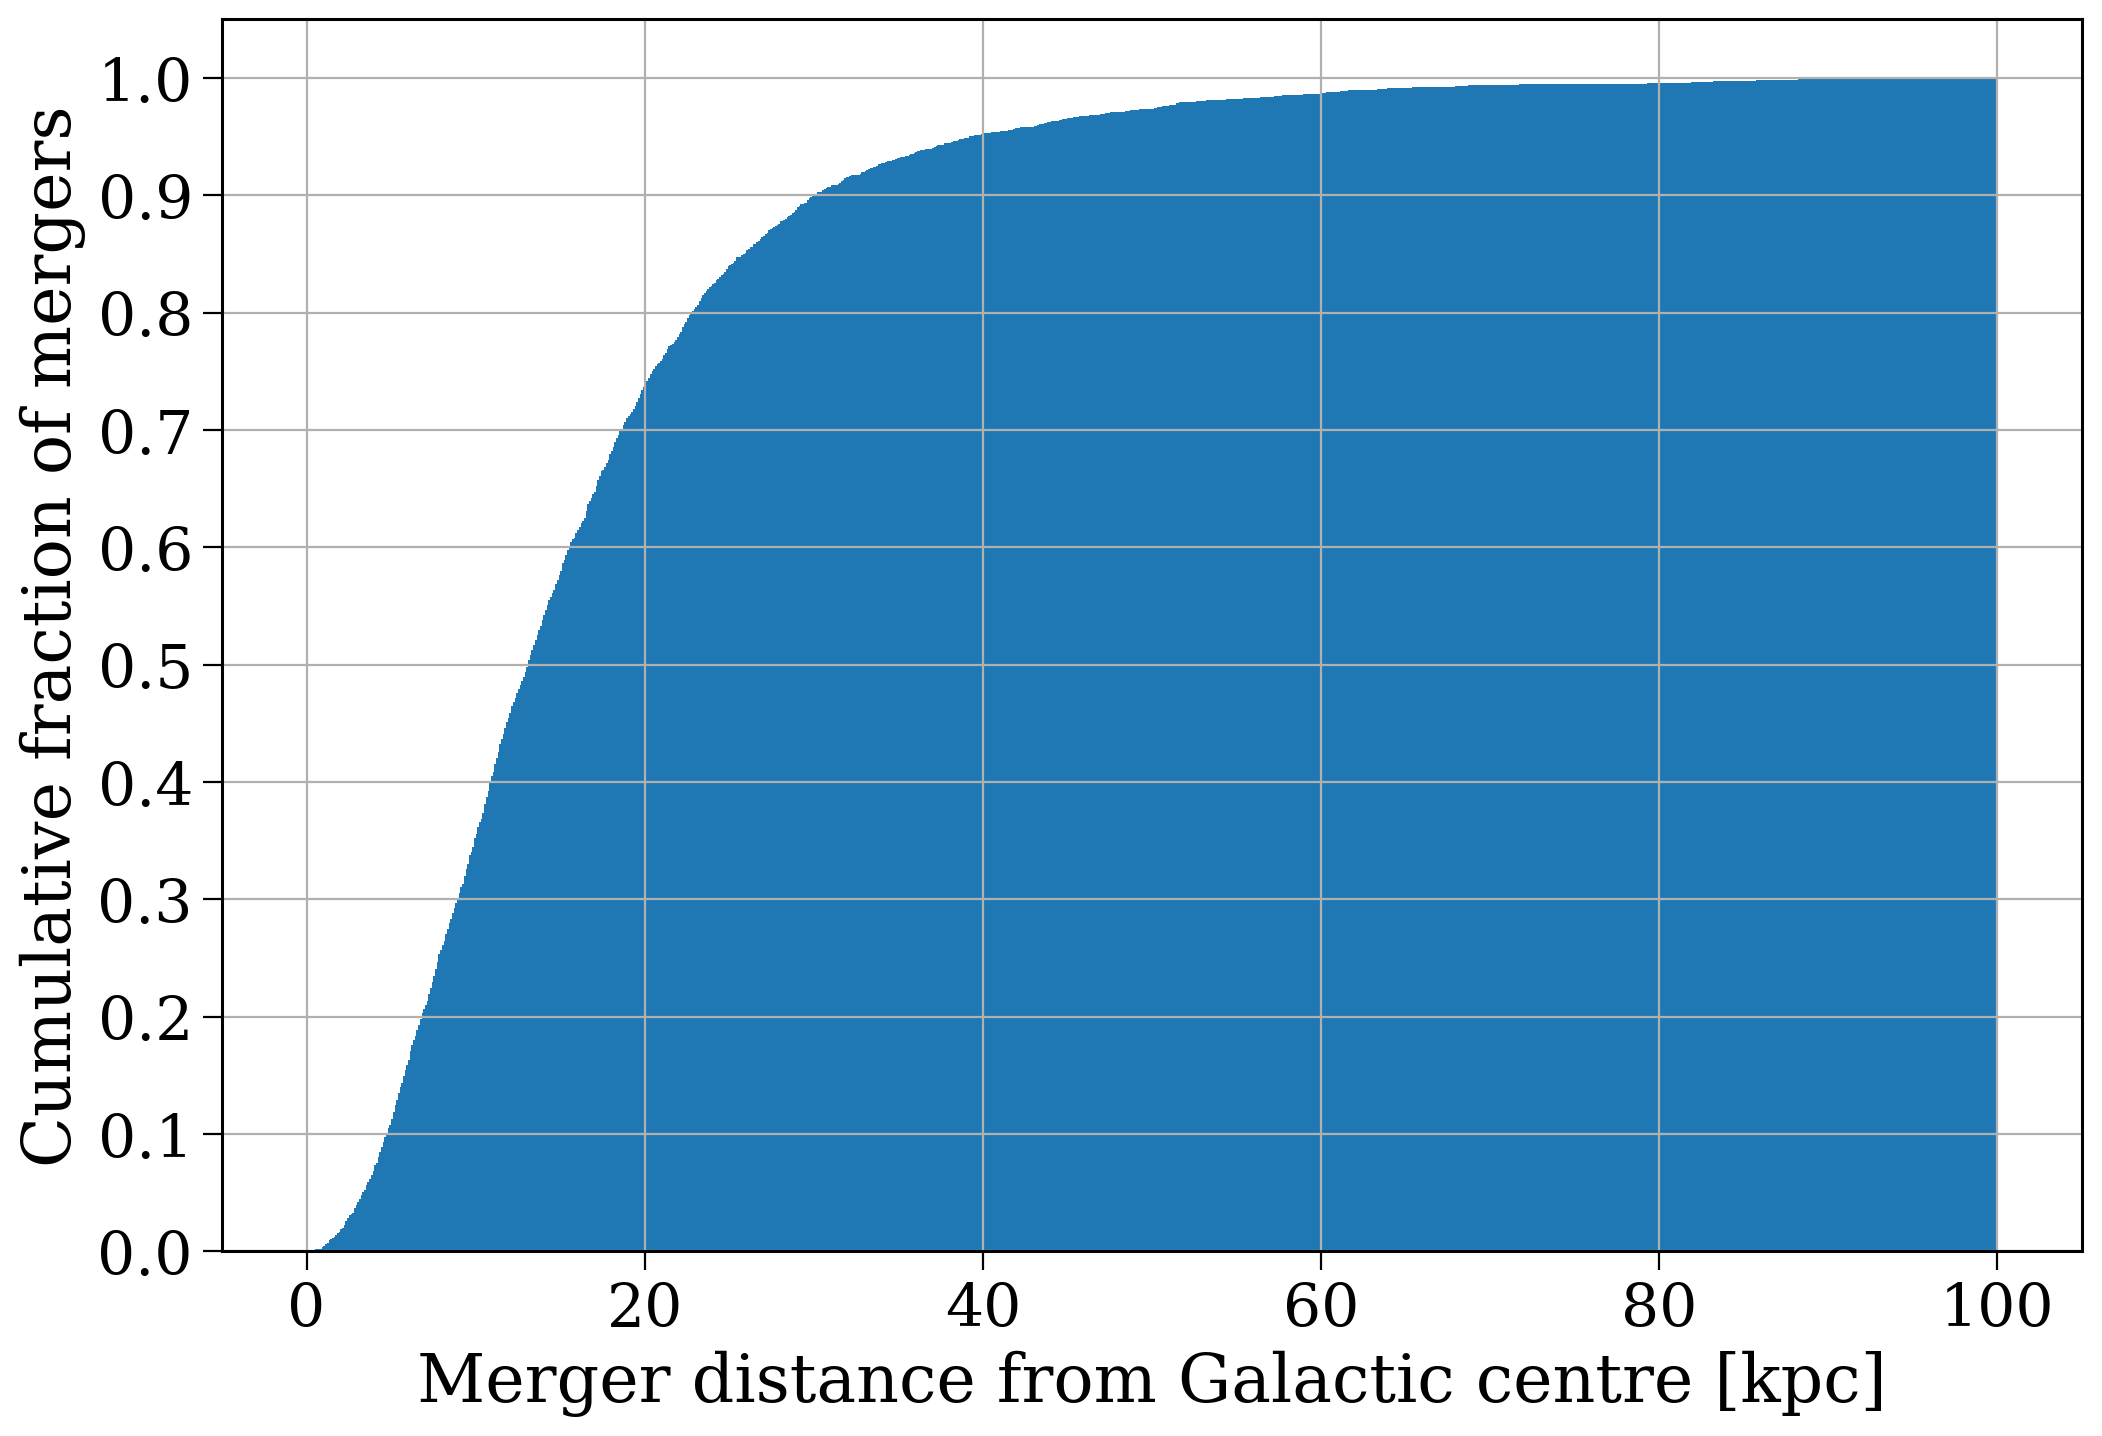

In [18]:
plt.hist(np.linalg.norm(gw_merger_locs, axis=1).value, cumulative=True, range=(0, 100), density=True, bins=1000)
plt.grid()
plt.xlabel("Merger distance from Galactic centre [kpc]")
plt.ylabel("Cumulative fraction of mergers")
plt.yticks(np.linspace(0, 1, 11))

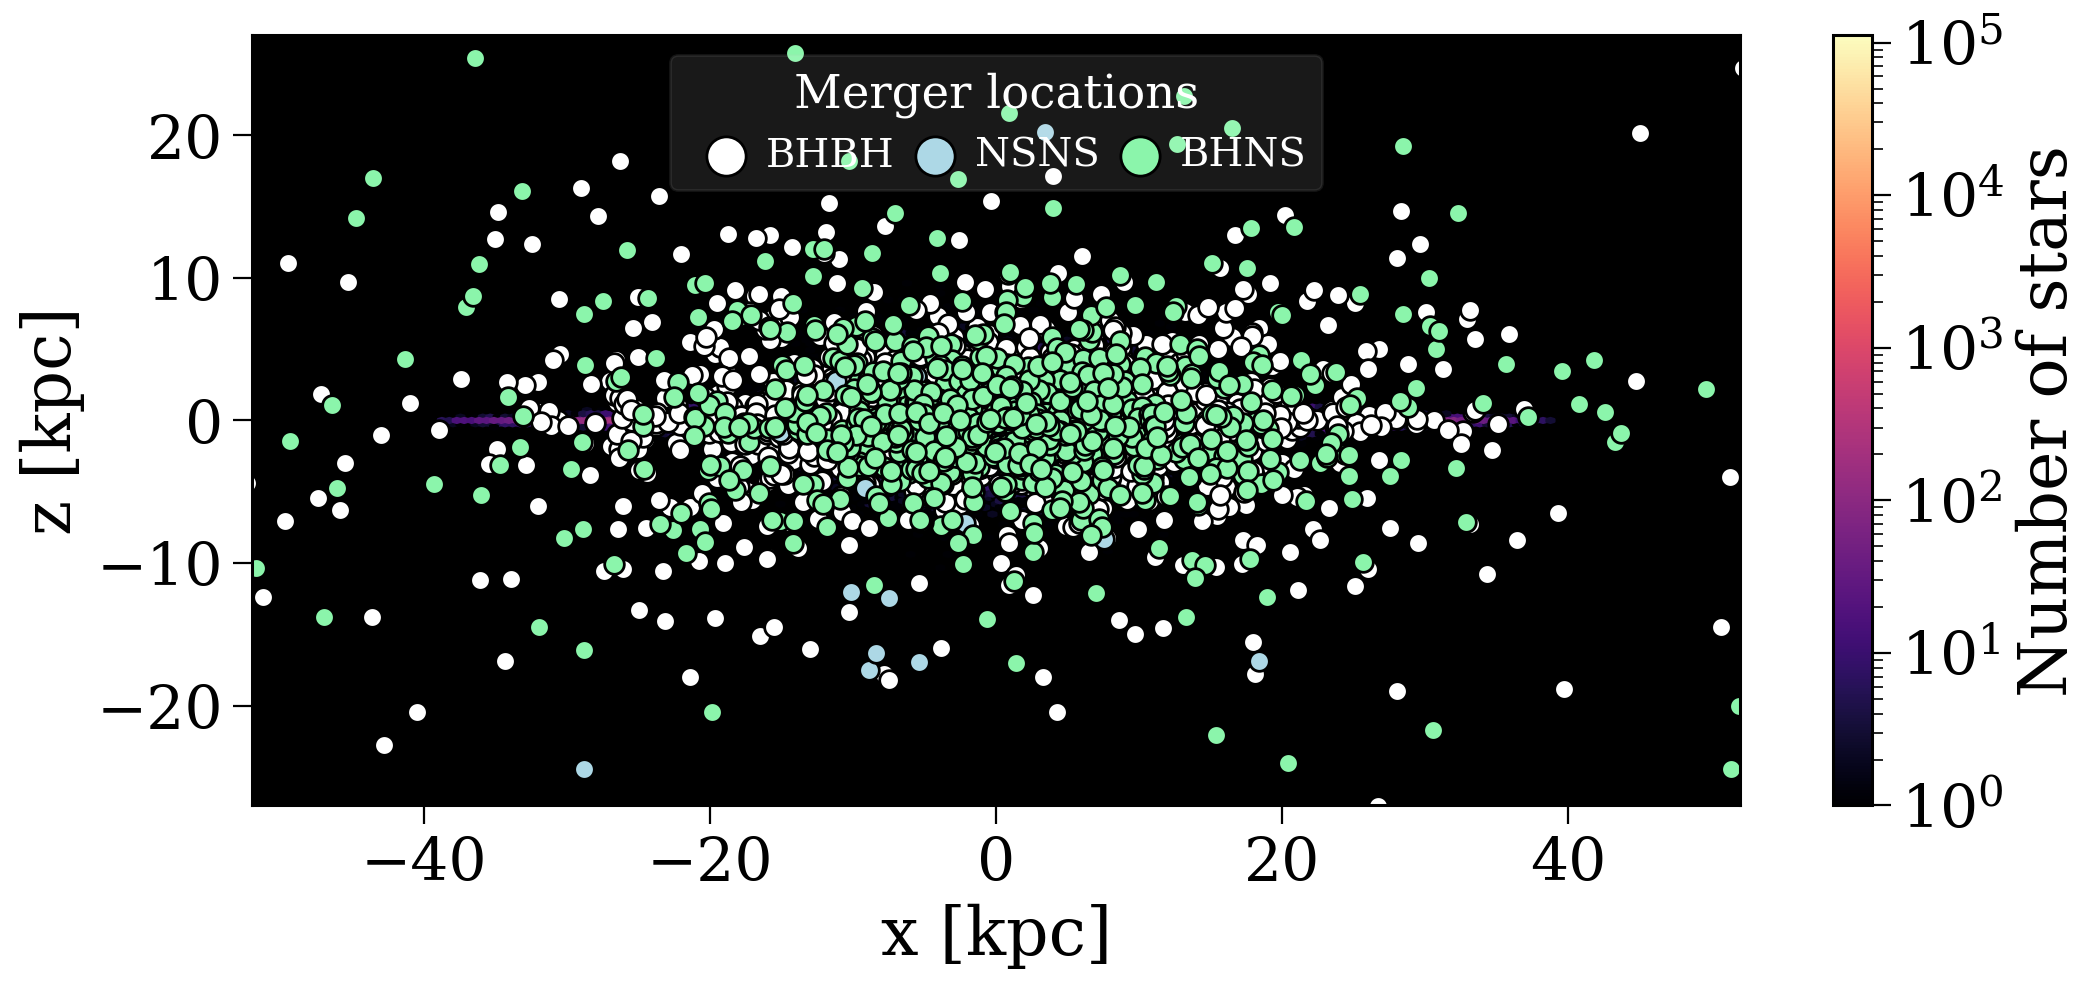

In [158]:
fig, ax = plt.subplots(figsize=(12, 5))
hexbin = plt.hexbin(stars.x, stars.z, gridsize=200, extent=[-52, 52, -27, 27], cmap='magma', bins='log', mincnt=1)

for dco_type, colour in zip(
    ["BHBH", "NSNS", "BHNS"],
    ["white", "lightblue", "#8BF5AB"],
):
    mask = gw_merger_types == dco_type
    ax.scatter(gw_merger_locs[mask, 0], gw_merger_locs[mask, 2], s=50, c=colour, label=dco_type, edgecolors='black')

fig.colorbar(hexbin, label="Number of stars")

ax.set(
    xlim=(-52, 52),
    ylim=(-27, 27),
    xlabel="x [kpc]",
    ylabel="z [kpc]",
)

leg = ax.legend(ncol=3, handletextpad=0.0, columnspacing=0.0, loc='upper center', fontsize=0.6*fs,
          markerscale=2, framealpha=0.1, labelcolor='white', title="Merger locations", title_fontsize=0.7*fs)
plt.setp(leg.get_title(), color='white')
ax.set_fc('black')
plt.show()

In [29]:
135 + 24

159

In [38]:
check_these = pop.bpp["bin_num"][(pop.bpp["kstar_1"] == 13) & (pop.bpp["kstar_2"] == 13) & (pop.bpp["sep"] > 0.0)].unique()
len(pop.final_bpp.loc[check_these][pop.final_bpp.loc[check_these, "sep"] == 0])

24

In [ ]:
pop.final_bpp[(pop.final_bpp["kstar_1"] == 13) & (pop.final_bpp["kstar_2"] == 13) & (pop.final_bpp["sep"] > 0)]

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_1,massc_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,bin_num,row_num,metallicity
30622,9819.816544,1.305900,1.660102,13,13,27.882108,9.907746,0.810853,10,7.408096e-06,6.638917e-06,1.305900,1.660102,2.488941e-10,2.927760e-10,6154.733342,6409.725950,1,1,30622,227054,0.007184
212153,4401.480940,2.065916,1.857585,13,13,30.739308,9.971865,0.401276,10,1.959751e-06,2.057278e-06,2.065916,1.857585,1.689208e-09,1.573307e-09,9934.051210,9759.081637,1,1,212153,1551151,0.002488
252987,10996.191074,1.361521,1.606673,13,13,7.203592,1.300618,0.551498,10,1.188237e-05,1.101675e-05,1.361521,1.606673,2.041756e-10,2.287299e-10,5857.422487,6026.099621,1,1,252987,1847191,0.003854
256424,9196.402537,2.788580,2.431891,13,13,174.643875,117.070464,0.723644,10,7.422057e-07,7.900975e-07,2.788580,2.431891,4.712321e-10,4.299590e-10,7219.619402,7056.061596,1,1,256424,1872005,0.001760
272456,9742.259997,1.924271,1.675377,13,13,15.208685,3.623095,0.658175,10,6.887971e-06,7.337940e-06,1.924271,1.675377,3.276659e-10,2.993009e-10,6592.701315,6445.143517,1,1,272456,1989579,0.004959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10623527,8073.363190,2.285931,2.063717,13,13,23.916517,6.499681,0.835086,10,9.152905e-06,9.590716e-06,2.285931,2.063717,5.356547e-10,5.002999e-10,7454.642561,7328.467895,1,1,10623527,77578977,0.001317
10646916,7568.079851,1.806152,2.292990,13,13,60.465737,26.914710,0.826529,10,3.723549e-06,3.338960e-06,1.806152,2.292990,5.209834e-10,6.120616e-10,7403.064872,7707.337603,1,1,10646916,77750952,0.005508
10674154,10274.790456,2.250918,1.822345,13,13,76.273746,38.252825,0.762805,10,1.947566e-06,2.144846e-06,2.250918,1.822345,3.270011e-10,2.838807e-10,6589.355107,6360.475075,1,1,10674154,77949115,0.005173
10775305,10612.361336,1.318736,1.997796,13,13,10.428306,2.143141,0.595308,10,9.655078e-06,7.987251e-06,1.318736,1.997796,2.145540e-10,2.838564e-10,5930.478425,6360.338876,1,1,10775305,78690526,0.006703


In [39]:
from psrqpy import QueryATNF

In [40]:
query = QueryATNF()
df = query.pandas

In [63]:
df["DIST"]

0       6.357
1       0.860
2       1.400
3       5.399
4       5.427
        ...  
4346    1.108
4347    0.959
4348    1.133
4349    3.444
4350    2.163
Name: DIST, Length: 4351, dtype: float64

In [74]:
(df["P0"] < 0.05) & (df["P1"] < 1e-17)

0       False
1       False
2       False
3       False
4       False
        ...  
4346    False
4347     True
4348    False
4349    False
4350    False
Length: 4351, dtype: bool

Text(0, 0.5, 'Spin period derivative $\\dot{P}$ [s/s]')

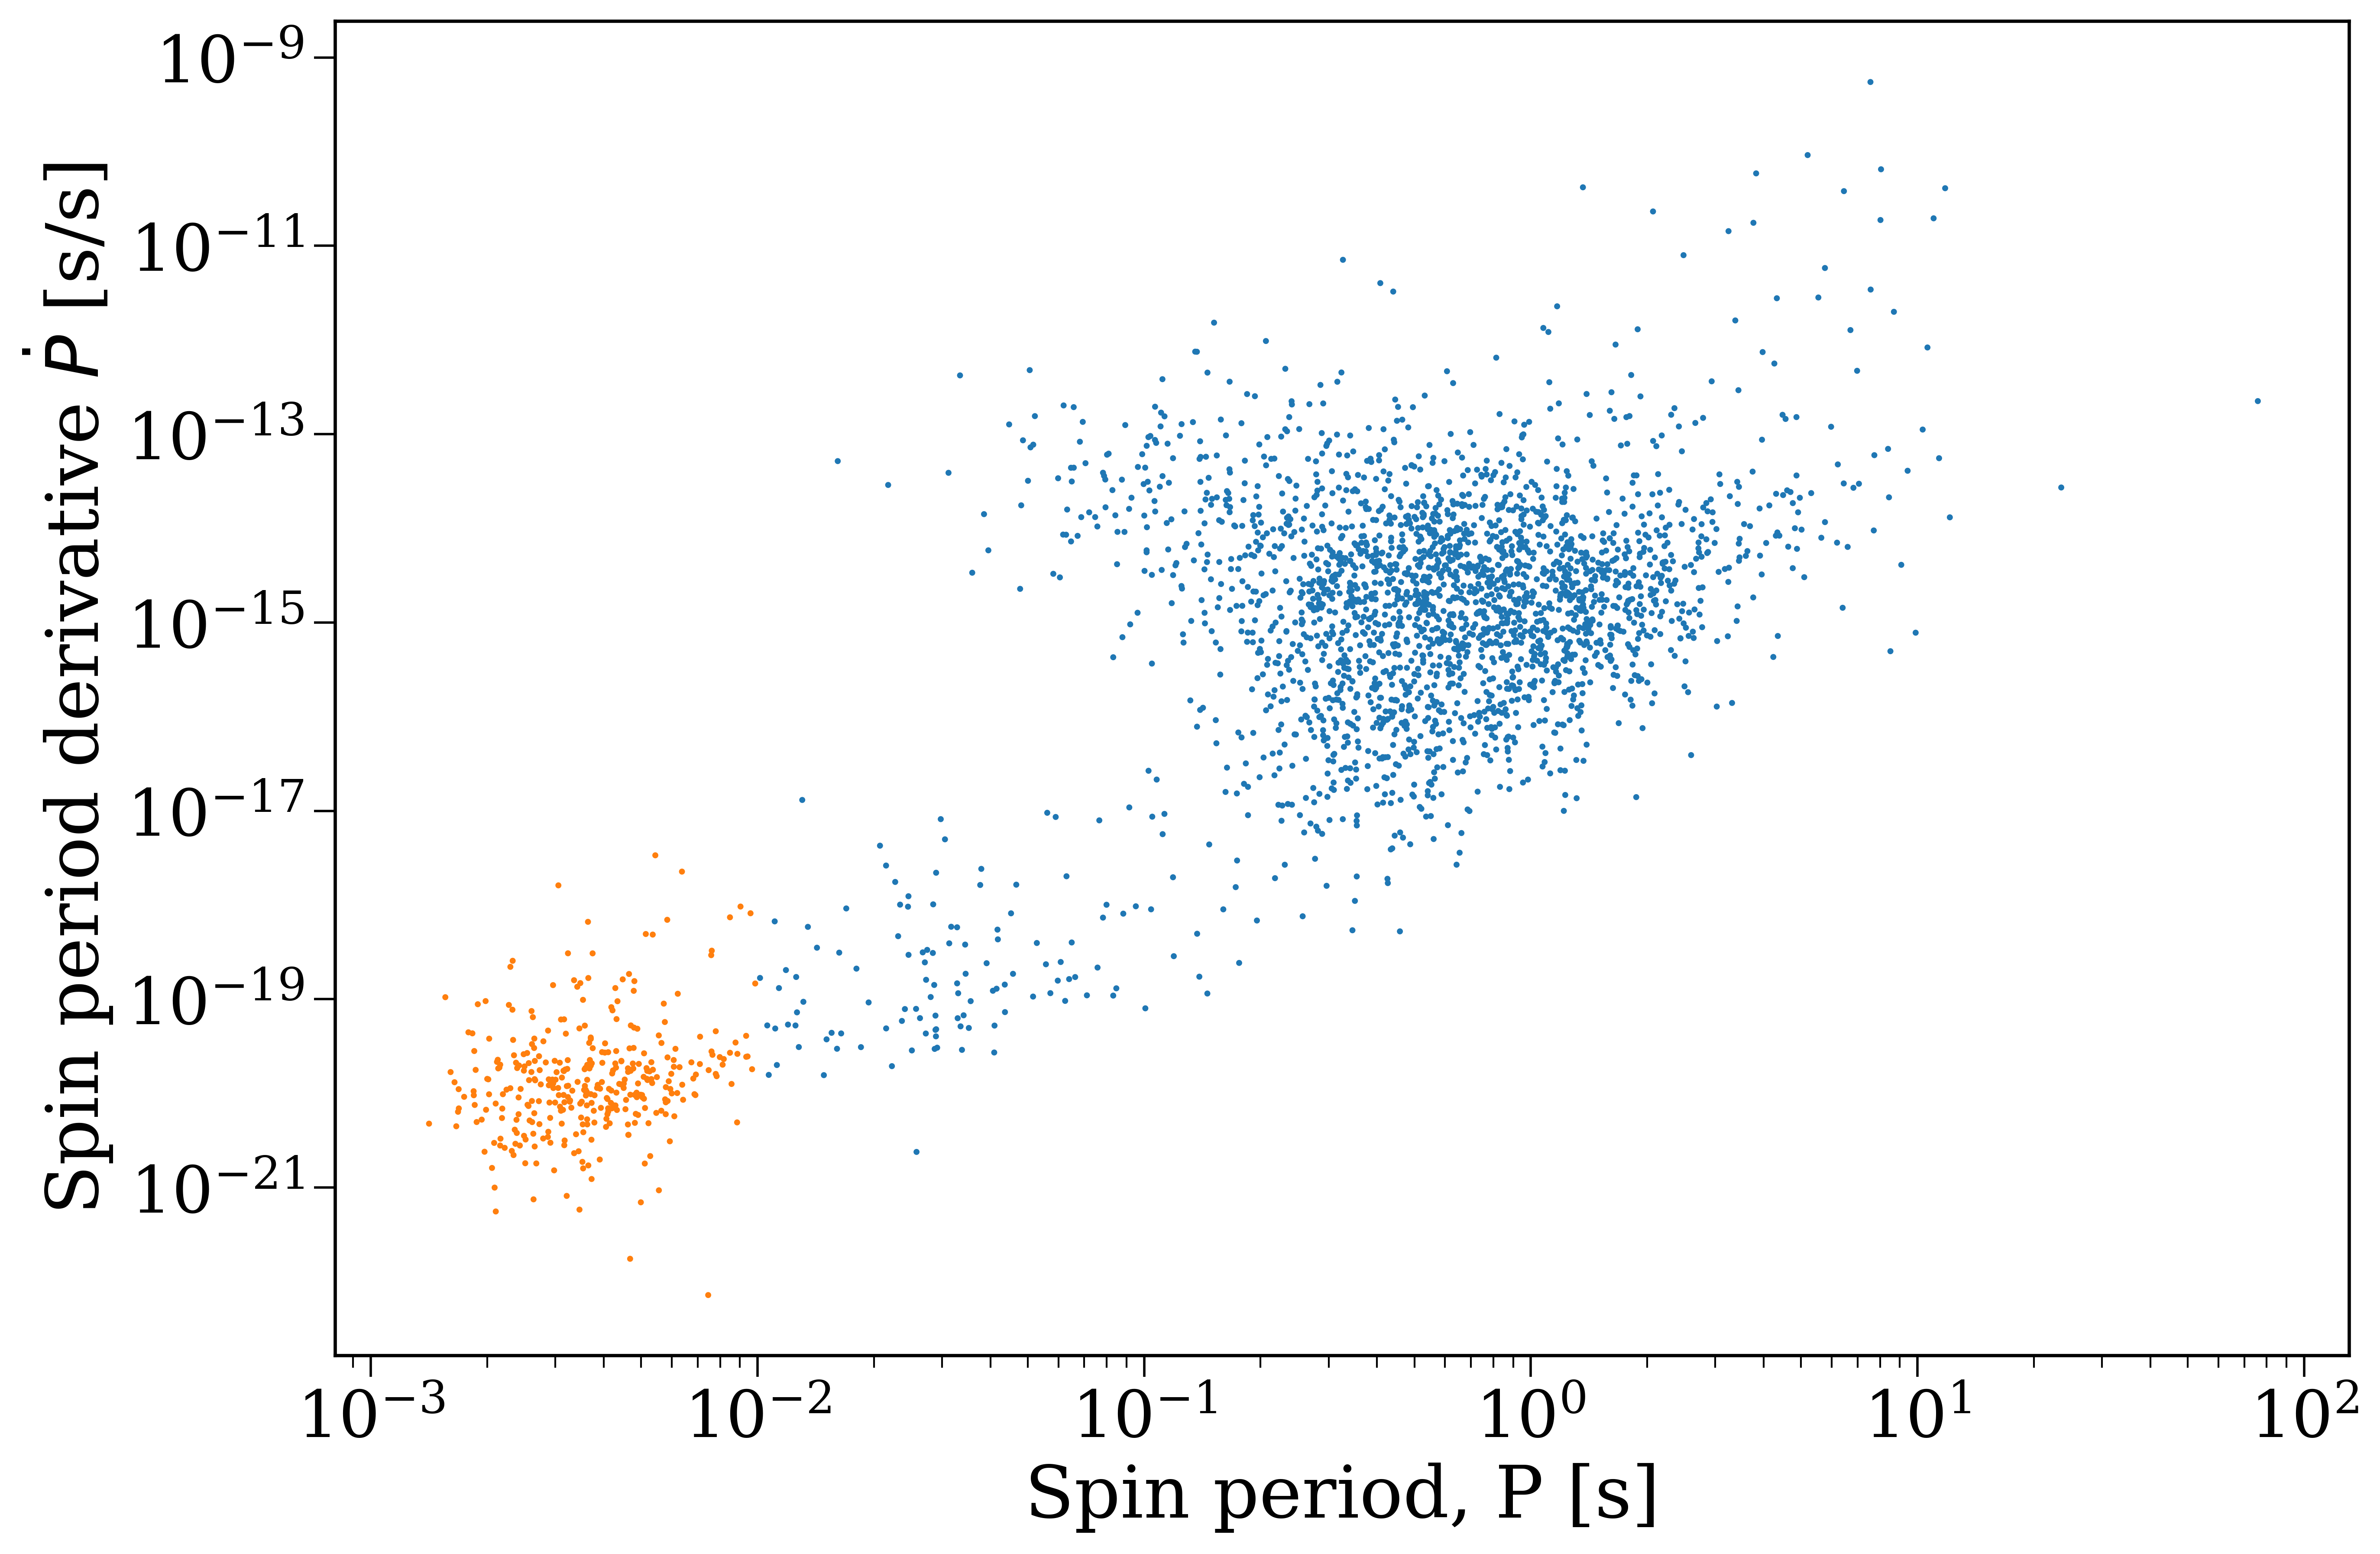

In [110]:
c = ["tab:orange" if (p0 < 0.01 and p1 < 1e-17) else "tab:blue"
     for p0, p1 in zip(df["P0"], df["P1"])]
plt.scatter(df["P0"], df["P1"], c=c, s=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Spin period, P [s]")
plt.ylabel(r"Spin period derivative $\dot{P}$ [s/s]")

Number of pulsars within 30 kpc: 4230
Number of recycled pulsars within 30 kpc: 408


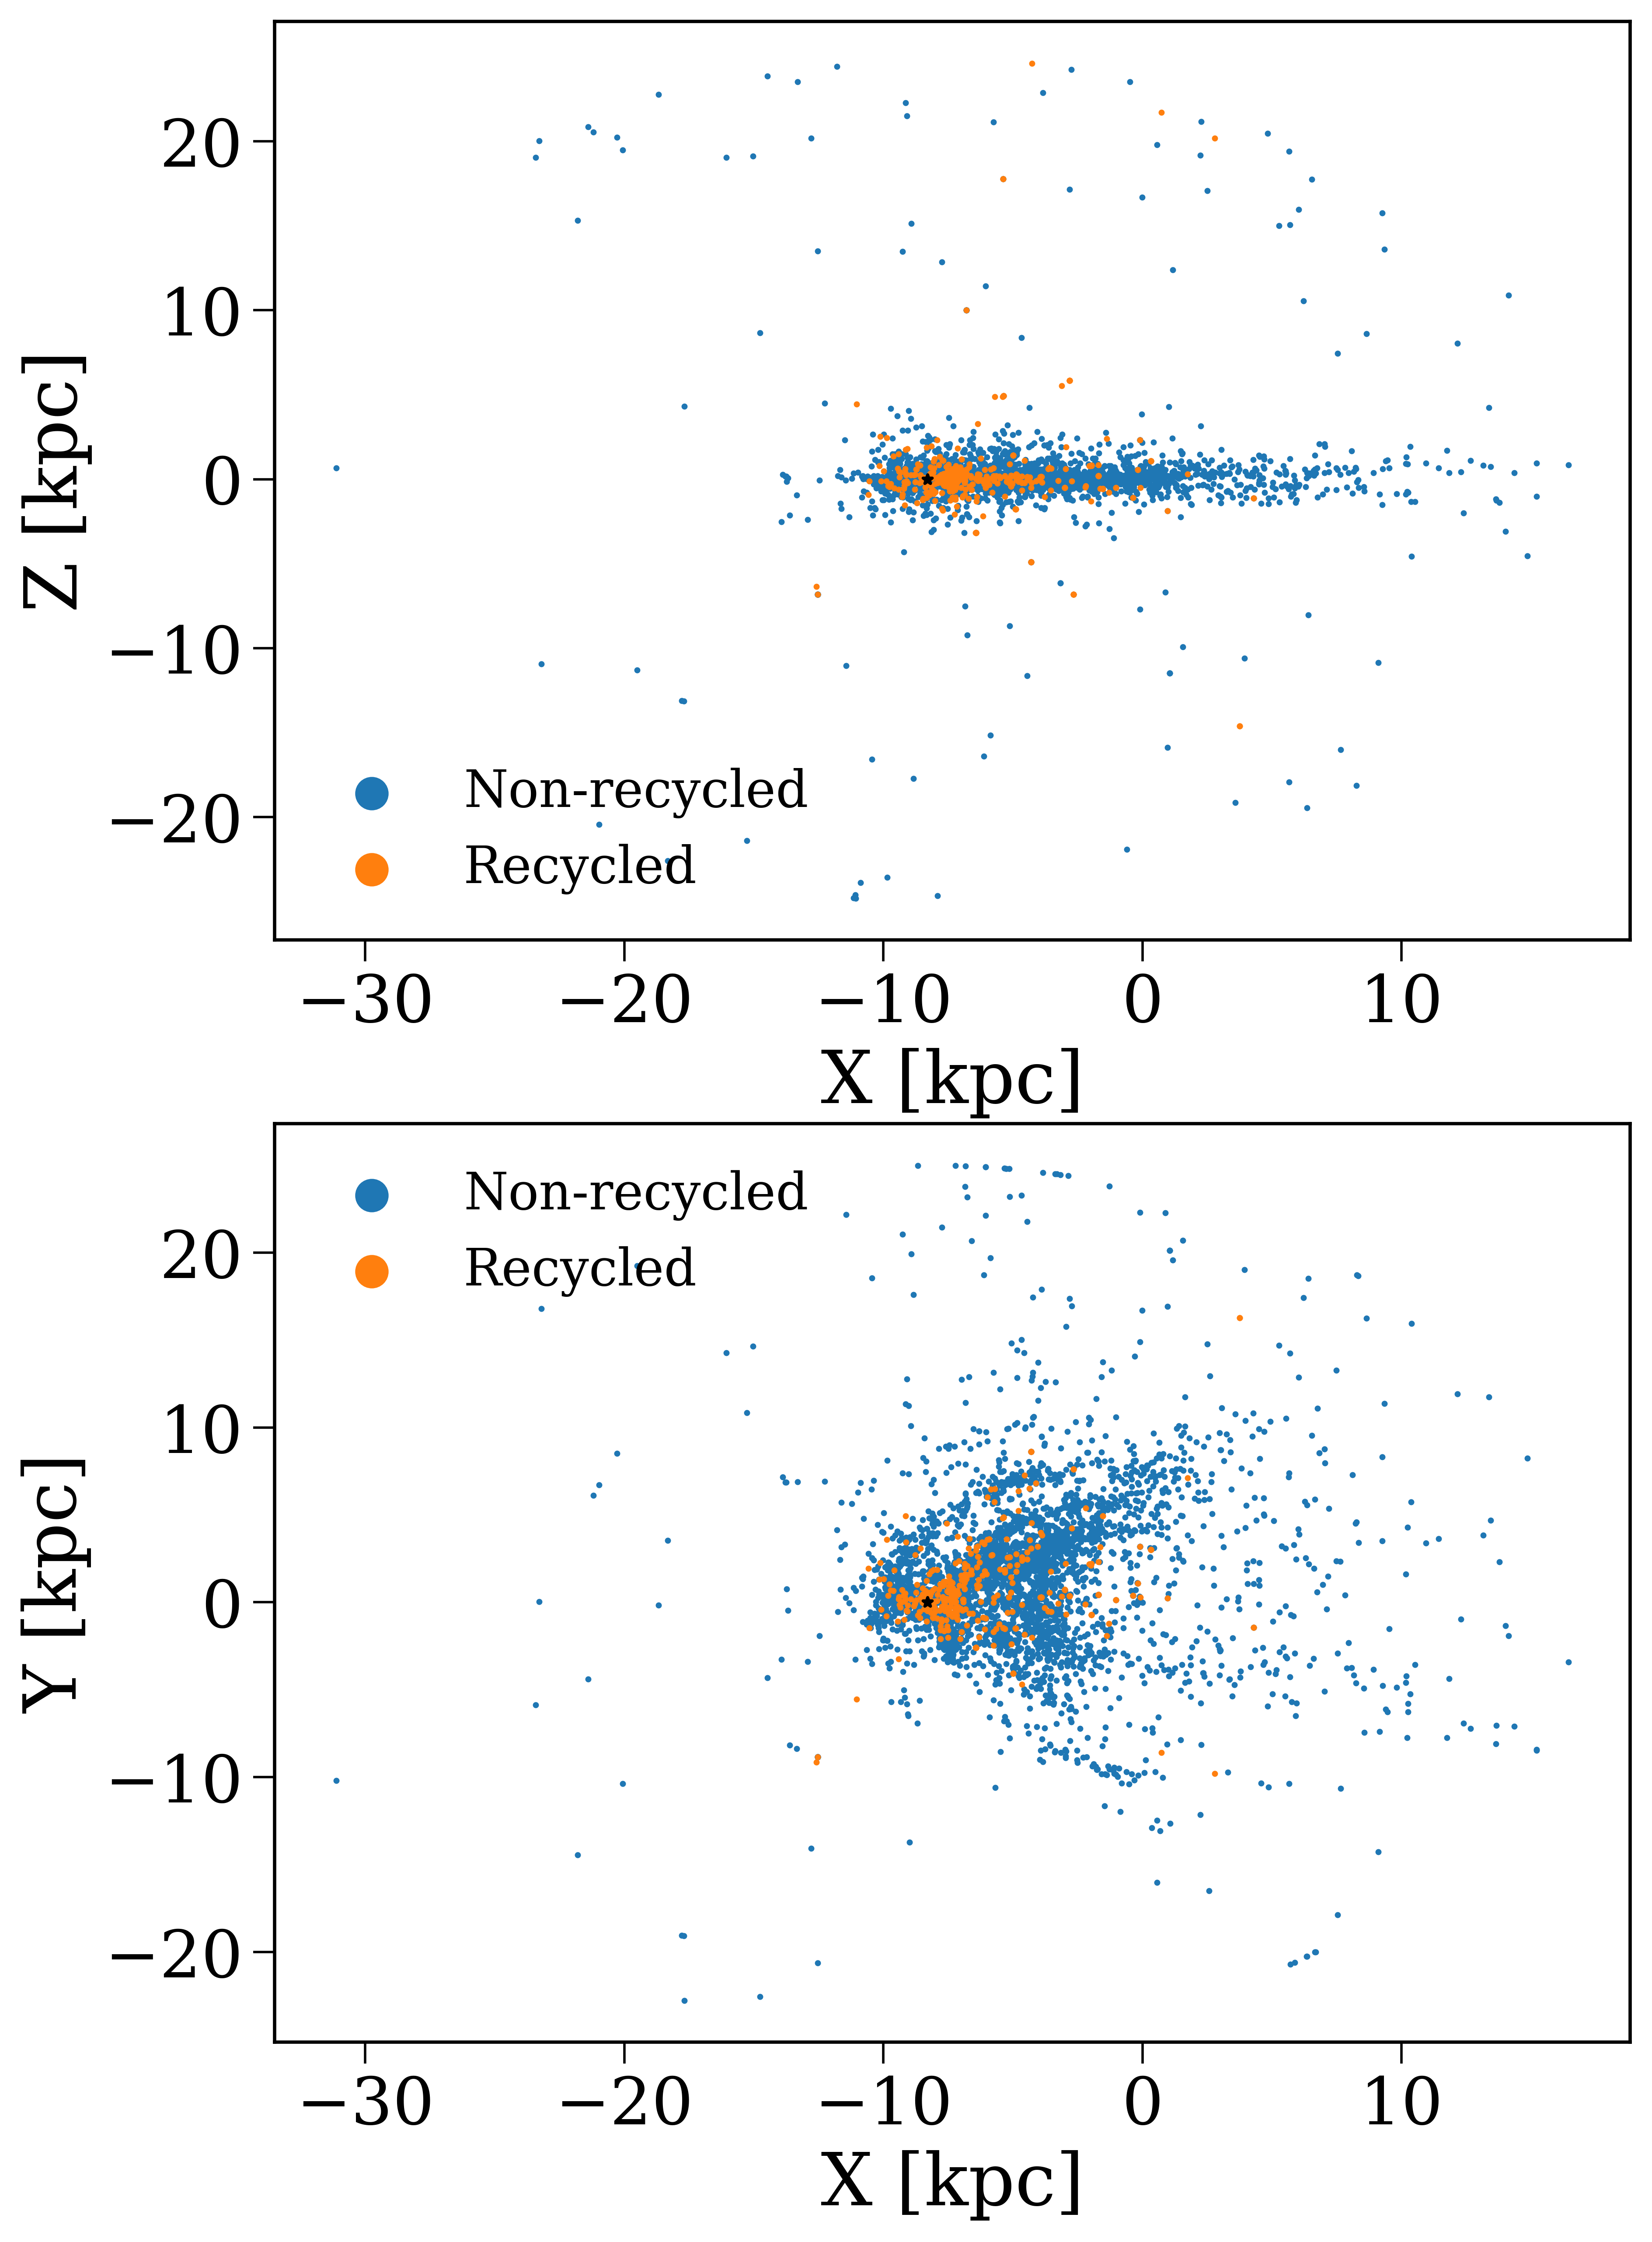

In [111]:
mask = (df["DIST"] < 30)
masked_df = df[mask]
recycled = (masked_df["P0"] < 0.01) & (masked_df["P1"] < 1e-17)

print(f"Number of pulsars within 30 kpc: {len(masked_df)}")
print(f"Number of recycled pulsars within 30 kpc: {recycled.sum()}")

fig, axes = plt.subplots(2, 1, figsize=(8, 12))
for ax, y, ylabel in zip(axes, ["ZZ", "YY"], ["Z [kpc]", "Y [kpc]"]):
    ax.scatter(
        masked_df["XX"][~recycled],
        masked_df[y][~recycled],
        label="Non-recycled",
        color="tab:blue",
        s=1,
    )
    ax.scatter(
        masked_df["XX"][recycled],
        masked_df[y][recycled],
        label="Recycled",
        color="tab:orange",
        s=1,
    )
    ax.scatter(-8.3, 0, marker='*', color='k', s=10)
    ax.set(
        xlabel="X [kpc]",
        ylabel=ylabel
    )
    ax.legend(markerscale=10, fontsize=fs*0.7)

plt.show()

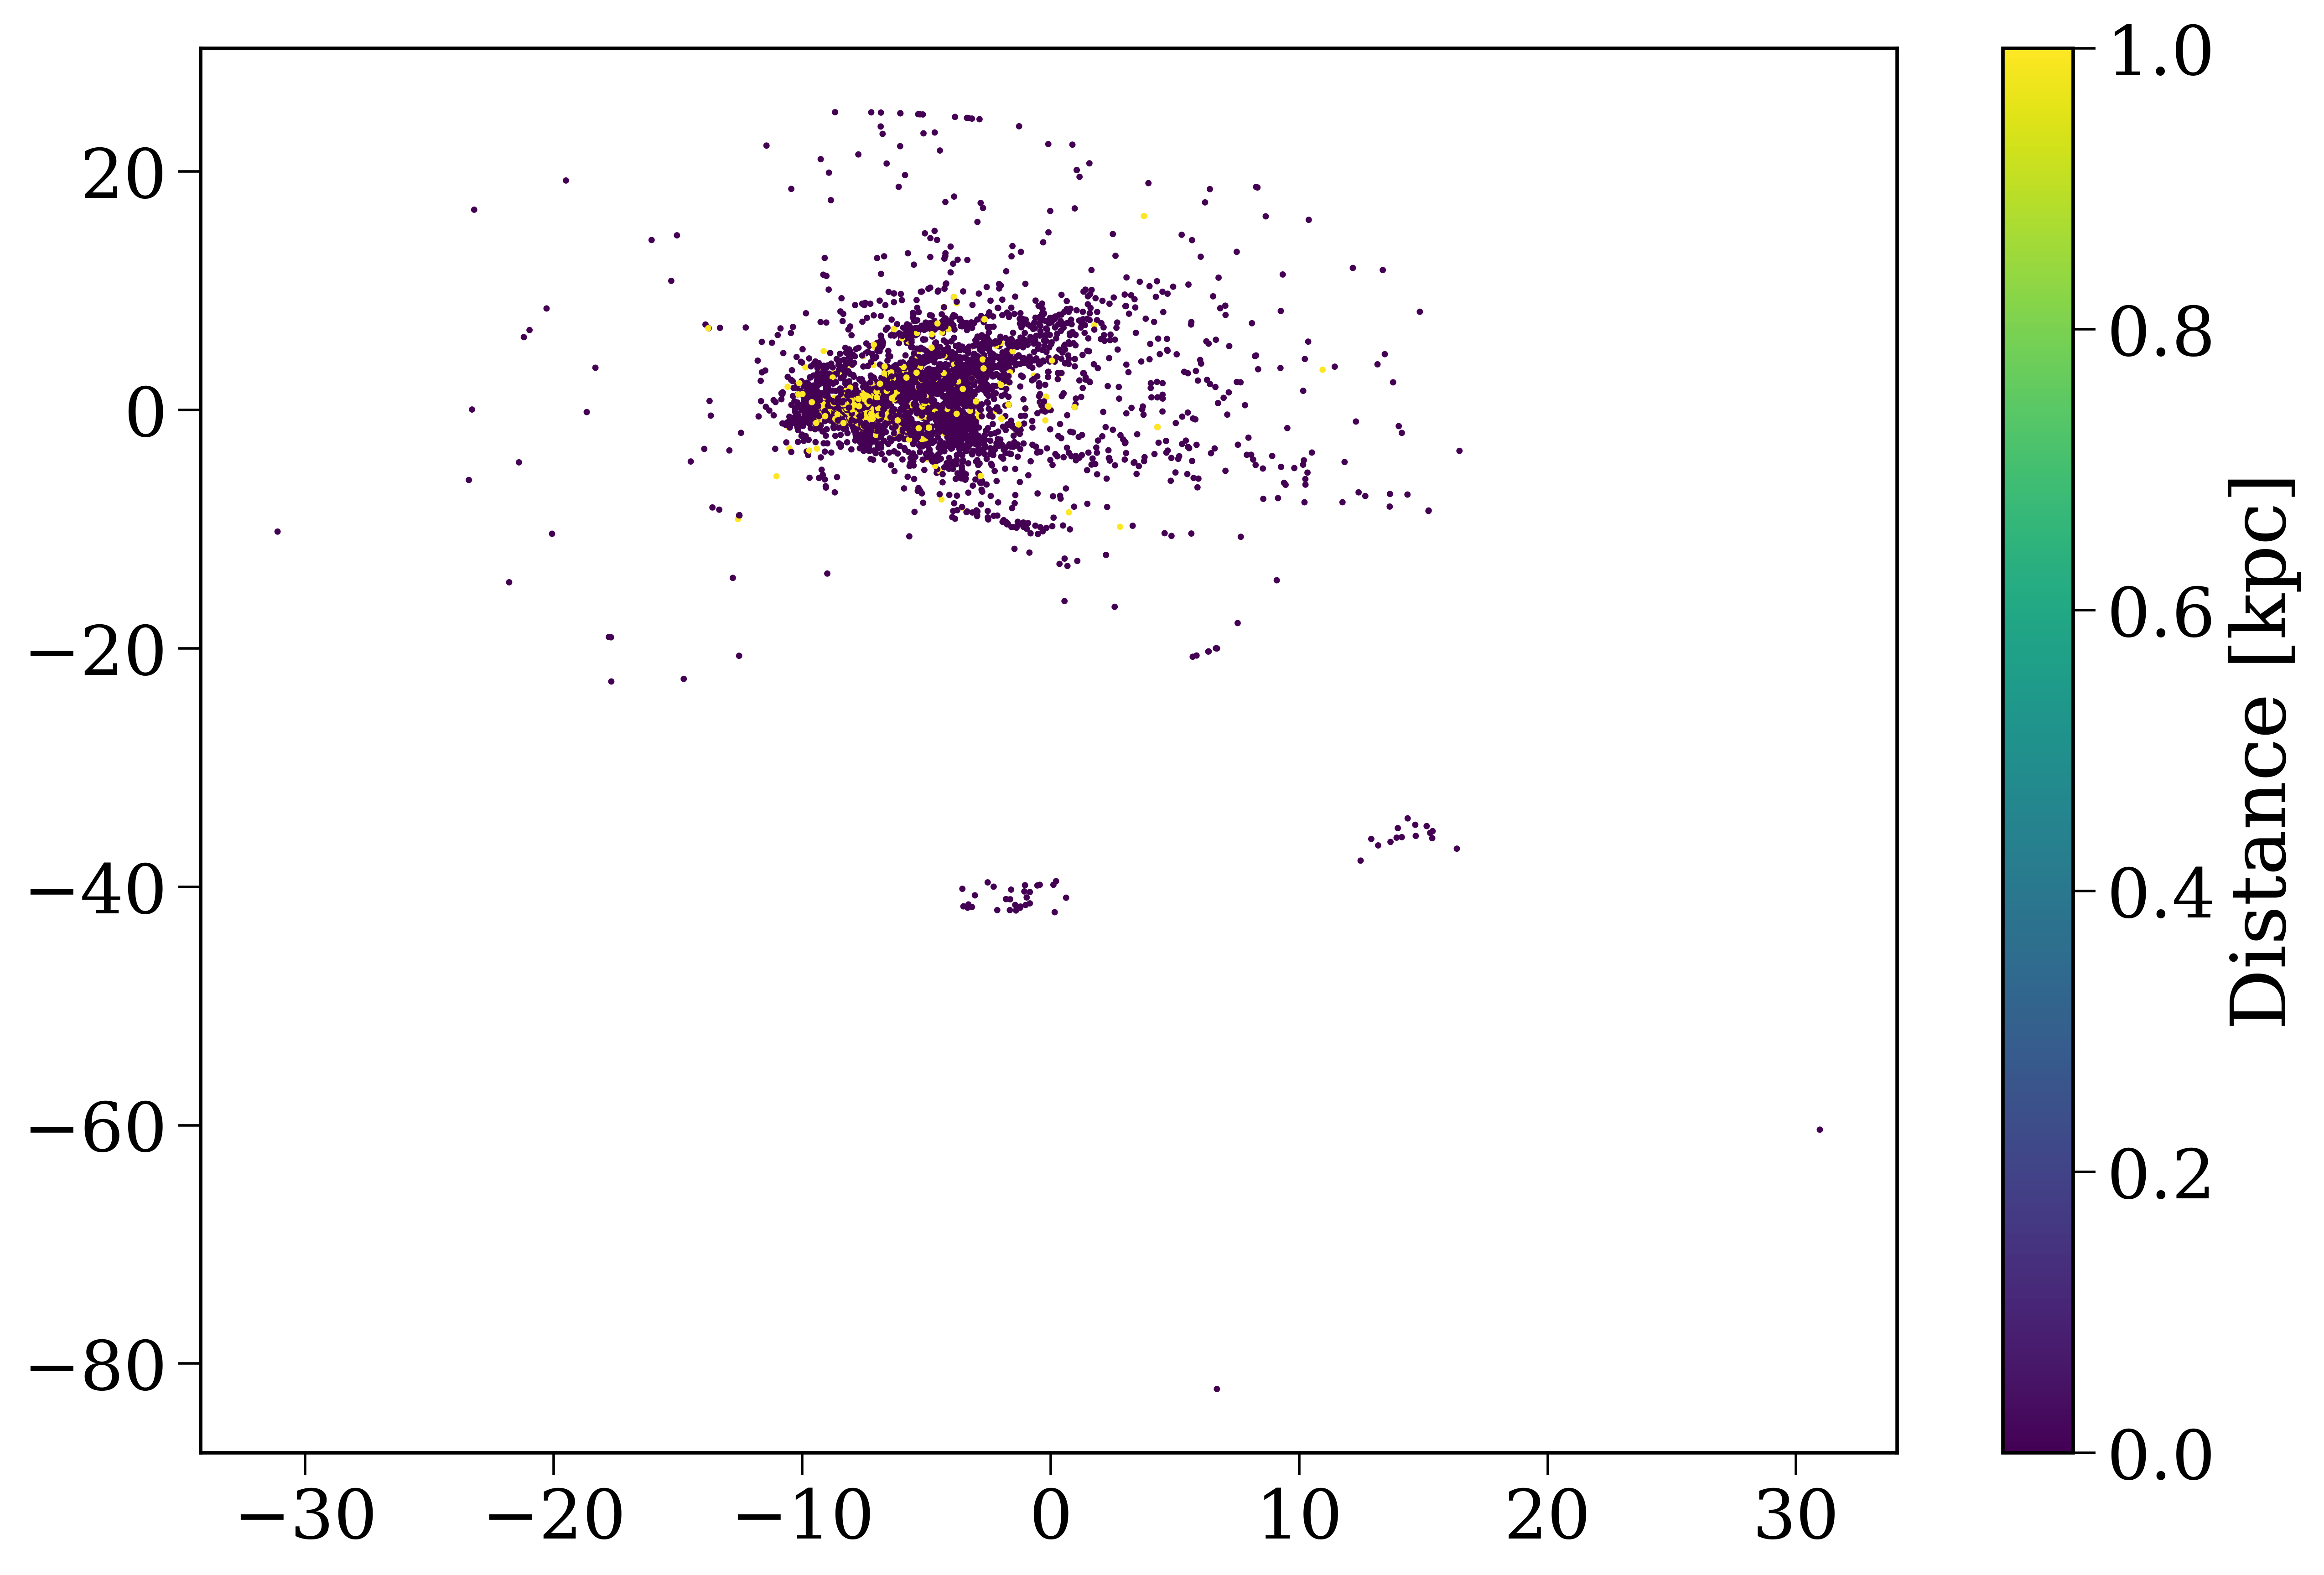

In [81]:
scatter = plt.scatter(df["XX"], df["YY"], c=(df["P0"] < 0.05) & (df["P1"] < 1e-17), s=1)
plt.colorbar(scatter, label="Distance [kpc]")
plt.show()

In [41]:
df

,PSRJ,PSRJ_REF,RAJ,RAJ_ERR,RAJ_REF,DECJ,DECJ_ERR,DECJ_REF,POSEPOCH,POSEPOCH_REF,PMRA,PMRA_ERR,PMRA_REF,PMDEC,PMDEC_ERR,PMDEC_REF,DM,DM_ERR,DM_REF,F0,F0_ERR,F0_REF,PEPOCH,PEPOCH_REF,F1,F1_ERR,F1_REF,PX,PX_ERR,PX_REF,S1400,S1400_REF,DIST_DM,DIST_DM_REF,DIST_DM1,DIST_DM1_REF,TYPE,ASSOC,SURVEY,JNAME,JNAME_REF,NAME,NAME_REF,RAJD,DECJD,RAJD_ERR,DECJD_ERR,DATE,DMEPOCH,DMEPOCH_REF,P0,P0_ERR,P0_REF,P1,P1_ERR,P1_REF,RM,RM_ERR,RM_REF,S400,S400_REF,S150,S150_ERR,S150_REF,S327,S327_ERR,S327_REF,W50,W50_REF,W10,W10_REF,W50_ERR,SPINDX,SPINDX_ERR,SPINDX_REF,FRACL,FRACL_ERR,FRACL_REF,FRACV,FRACV_ERR,FRACV_REF,FRACAV,FRACAV_ERR,FRACAV_REF,MAGINC,MAGINC_REF,IMPANG,IMPANG_REF,PASWING,PASWING_REF,F2,F2_ERR,F2_REF,F3,F3_ERR,F3_REF,NGLT,DIST_AMX,DIST_AMX_REF,DIST_AMN,DIST_AMN_REF,S300,S300_REF,W10_ERR,EPHEM,EPHEM_REF,CLK,CLK_REF,PSRB,PSRB_REF,S400_ERR,S50,S50_ERR,S50_REF,S600,S600_ERR,S600_REF,S1400_ERR,TAU_SC,TAU_SC_ERR,TAU_SC_REF,BNAME,BNAME_REF,ELONG,ELONG_ERR,ELONG_REF,ELAT,ELAT_ERR,ELAT_REF,PMELONG,PMELONG_ERR,PMELONG_REF,PMELAT,PMELAT_ERR,PMELAT_REF,S350,S350_REF,S820,S820_REF,S2000,S2000_REF,BINARY,BINARY_REF,A1,A1_ERR,A1_REF,PB,PB_ERR,PB_REF,TASC,TASC_ERR,TASC_REF,EPS1,EPS1_ERR,EPS1_REF,EPS2,EPS2_ERR,EPS2_REF,FB0,FB0_ERR,FB0_REF,FB1,FB1_ERR,FB1_REF,FB2,FB2_ERR,FB2_REF,BINCOMP,S3000,S3000_ERR,S3000_REF,S4000,S4000_ERR,S4000_REF,S800,S800_ERR,S800_REF,S2000_ERR,S900,S900_ERR,S900_REF,S1600,S1600_ERR,S1600_REF,DIST_A,DIST_A_ERR,DIST_A_REF,UNITS,UNITS_REF,ECC,ECC_ERR,ECC_REF,PBDOT,PBDOT_ERR,PBDOT_REF,OM,OM_ERR,OM_REF,OMDOT,OMDOT_ERR,OMDOT_REF,T0,T0_ERR,T0_REF,M2,M2_ERR,M2_REF,S300_ERR,S350_ERR,DM1,DM1_ERR,DM1_REF,DM2,DM2_ERR,DM2_REF,S100,S100_REF,S944,S944_ERR,S944_REF,S1429,S1429_ERR,S1429_REF,S1625,S1625_ERR,S1625_REF,S200,S200_ERR,S200_REF,S80,S80_ERR,S80_REF,S1284,S1284_ERR,S1284_REF,P2,P2_ERR,P2_REF,A1DOT,A1DOT_ERR,A1DOT_REF,MAGINC_ERR,IMPANG_ERR,PASWING_ERR,S1300,S1300_ERR,S1300_REF,S1700,S1700_ERR,S1700_REF,S2100,S2100_ERR,S2100_REF,S2600,S2600_ERR,S2600_REF,S3300,S3300_ERR,S3300_REF,S3800,S3800_ERR,S3800_REF,S60,S60_ERR,S60_REF,S820_ERR,S5000,S5000_ERR,S5000_REF,F4,F4_ERR,F4_REF,F5,F5_ERR,F5_REF,S1500,S1500_ERR,S1500_REF,MASS_Q,MASS_Q_ERR,MASS_Q_REF,S100_ERR,S40,S40_ERR,S40_REF,A1_2,A1_2_ERR,A1_2_REF,PB_2,PB_2_ERR,PB_2_REF,TASC_2,TASC_2_ERR,TASC_2_REF,EPS1_2,EPS1_2_ERR,EPS1_2_REF,EPS2_2,EPS2_2_ERR,EPS2_2_REF,SINI,SINI_ERR,SINI_REF,M2_2,M2_2_ERR,M2_2_REF,S2250,S2250_ERR,S2250_REF,S8600,S8600_ERR,S8600_REF,S700,S700_ERR,S700_REF,KOM,KOM_ERR,KOM_REF,KIN,KIN_ERR,KIN_REF,S155,S155_ERR,S155_REF,STIG,STIG_ERR,STIG_REF,H3,H3_ERR,H3_REF,H4,H4_ERR,H4_REF,GAMMA,GAMMA_ERR,GAMMA_REF,S100G,S100G_ERR,S100G_REF,S150G,S150G_ERR,S150G_REF,S816,S816_ERR,S816_REF,OM_ASC,OM_ASC_ERR,OM_ASC_REF,S1558,S1558_ERR,S1558_REF,S2612,S2612_ERR,S2612_REF,S4988,S4988_ERR,S4988_REF,S5012,S5012_ERR,S5012_REF,S8488,S8488_ERR,S8488_REF,S9512,S9512_ERR,S9512_REF,FB3,FB3_ERR,FB3_REF,FB4,FB4_ERR,FB4_REF,DM3,DM3_ERR,DM3_REF,A1_3,A1_3_ERR,A1_3_REF,ECC_2,ECC_2_ERR,ECC_2_REF,ECC_3,ECC_3_ERR,ECC_3_REF,PB_3,PB_3_ERR,PB_3_REF,OM_2,OM_2_ERR,OM_2_REF,OM_3,OM_3_ERR,OM_3_REF,T0_2,T0_2_ERR,T0_2_REF,T0_3,T0_3_ERR,T0_3_REF,SINI_2,SINI_2_ERR,SINI_2_REF,SINI_3,SINI_3_ERR,SINI_3_REF,M2_3,M2_3_ERR,M2_3_REF,A12DOT,A12DOT_ERR,A12DOT_REF,OM2DOT,OM2DOT_ERR,OM2DOT_REF,S430,S430_ERR,S430_REF,S1380,S1380_ERR,S1380_REF,S35,S35_ERR,S35_REF,S64,S64_ERR,S64_REF,S79,S79_ERR,S79_REF,S6000,S6000_ERR,S6000_REF,FB5,FB5_ERR,FB5_REF,FB6,FB6_ERR,FB6_REF,FB7,FB7_ERR,FB7_REF,FB8,FB8_ERR,FB8_REF,FB9,FB9_ERR,FB9_REF,S8000,S8000_ERR,S8000_REF,S9000,S9000_REF,S1283,S1283_REF,PBDOT_2,PBDOT_2_ERR,PBDOT_2_REF,PBDOT_3,PBDOT_3_ERR,PBDOT_3_REF,DM4,DM4_ERR,DM4_REF,DM5,DM5_ERR,DM5_REF,S9000_ERR,ECCDOT,ECCDOT_ERR,ECCDOT_REF,DTHETA,DTHETA_ERR,DTHETA_REF,DIST,DIST1,GL,GB,XX,YY,ZZ,DMSINB,PMB,PML,AGE,BSURF,B_LC,EDOT,EDOTD2,PMTOT,PMTOT_ERR,VTRANS,P1_I,AGE_I,BSURF_I,EDOT_I,SI414,R_LUM,R_LUM14,MASSFN,MINMASS,MEDMASS,UPRMASS,MASSFN_ERR,MINOMDOT,H0_SD,ASSOC_ORIG,ASSOC_REF,TYPE_ORIG,TYPE_REF,BINCOMP_ORIG,BINCOMP_REF
0,J0002+6216,cwp+17,0